# 🔍 DensiScope
## Densest Subgraph Discovery on Large Collaboration Networks

**Analysis & Algorithms Project**

DensiScope studies the **Densest Subgraph Problem (DSP)** on real-world collaboration networks and compares fast approximation, iterative greedy refinement, exact max-flow, and higher-order triangle-density optimization.

### Implemented Algorithms
1. **Charikar's Greedy Peeling**
2. **Greedy++**
3. **Goldberg's Exact Max-Flow Algorithm**
4. **Exact Triangle-Density Algorithm**

### Objectives

For ordinary edge density:

\[
\rho(S)=\frac{|E(S)|}{|V(S)|}
\]

For triangle density:

\[
\tau(S)=\frac{T(S)}{|V(S)|}
\]

where \(T(S)\) is the number of triangles fully contained in \(S\).

### Experimental Datasets

| Dataset | Vertices | Edges |
|---|---:|---:|
| ca-netscience | 379 | 914 |
| ca-CSphd | 1,882 | 1,740 |
| ca-GrQc | 4,158 | 13,422 |
| ca-HepTh | 11,204 | 117,619 |
| ca-dblp-2012 | 317,080 | 1,049,866 |

### Project Highlights
- Five real collaboration datasets
- Approximate and exact solution comparison
- Runtime and memory scalability analysis
- Exact-safe graph reductions
- Structural optimality certificates
- MP4 algorithm visualizations
- Interactive DensiScope explorer

> **Reproducibility note:** This cleaned notebook preserves the successful experiment outputs from the development notebook. To reproduce everything from scratch in Colab, use **Runtime → Restart session → Run all**.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Environment Setup

Google Drive is mounted, the DensiScope project folders are created, required packages are installed, and the common numerical/graph libraries are imported.

The implementation is designed around sparse matrices and explicit memory management so the same notebook can scale from a 379-vertex graph to the 317,080-vertex DBLP network.


In [2]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/DensiScope"

folders = [
    "data/raw",
    "data/processed",
    "results",
    "results/tables",
    "results/solutions",
    "figures",
    "videos",
    "docs"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

print("✅ DensiScope project structure ready!")
print(f"📁 Project location: {PROJECT_ROOT}")

print("\nFolders:")
for folder in folders:
    print("   └──", folder)


✅ DensiScope project structure ready!
📁 Project location: /content/drive/MyDrive/DensiScope

Folders:
   └── data/raw
   └── data/processed
   └── results
   └── results/tables
   └── results/solutions
   └── figures
   └── videos
   └── docs


In [3]:
!pip -q install igraph imageio imageio-ffmpeg psutil ipywidgets

print("✅ Required packages installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 115.1 MB/s eta 0:00:00
✅ Required packages installed.


In [4]:
import os
import gc
import time
import heapq
import warnings

import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp

import matplotlib.pyplot as plt
import networkx as nx

import psutil
import igraph as ig
import ipywidgets as widgets

from IPython.display import display, clear_output

warnings.filterwarnings("ignore")

print("✅ Imports successful")
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)
print("igraph:", ig.__version__)


✅ Imports successful
NumPy: 2.1.3
SciPy: 1.16.3
Pandas: 2.2.3
igraph: 1.0.0


In [5]:
def show_memory(label="Current"):
    process = psutil.Process(os.getpid())

    process_ram = process.memory_info().rss / (1024 ** 3)
    total_ram = psutil.virtual_memory().total / (1024 ** 3)
    available_ram = psutil.virtual_memory().available / (1024 ** 3)

    print(f"🧠 {label} memory status")
    print(f"   Python process: {process_ram:.3f} GB")
    print(f"   Total system RAM: {total_ram:.2f} GB")
    print(f"   Available RAM: {available_ram:.2f} GB")


show_memory("Startup")

🧠 Startup memory status
   Python process: 0.192 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.61 GB


# 2. Validation Graph & Core Graph Representation

Before using real datasets, a small graph with a dense \(K_4\) region and a sparse tail is constructed as a CSR adjacency matrix. It provides a simple correctness target for the greedy algorithms.


In [6]:
def build_csr_graph(edges, num_nodes=None):
    """
    Build a memory-efficient undirected graph using SciPy CSR.

    Parameters
    ----------
    edges : array-like of shape (m, 2)
        Each row is [u, v].

    num_nodes : int, optional
        Number of nodes. If omitted, inferred automatically.

    Returns
    -------
    csr_matrix
        Symmetric unweighted adjacency matrix.
    """

    edges = np.asarray(edges, dtype=np.int32)

    if edges.ndim != 2 or edges.shape[1] != 2:
        raise ValueError("edges must have shape (m, 2)")

    # Remove self-loops
    edges = edges[edges[:, 0] != edges[:, 1]]

    if len(edges) == 0:
        if num_nodes is None:
            num_nodes = 0
        return sp.csr_matrix((num_nodes, num_nodes), dtype=np.uint8)

    if num_nodes is None:
        num_nodes = int(edges.max()) + 1

    u = edges[:, 0]
    v = edges[:, 1]

    # Add both directions because the graph is undirected
    rows = np.concatenate((u, v))
    cols = np.concatenate((v, u))

    data = np.ones(len(rows), dtype=np.uint8)

    adjacency = sp.csr_matrix(
        (data, (rows, cols)),
        shape=(num_nodes, num_nodes),
        dtype=np.uint8
    )

    # Convert duplicate edges into a single edge
    adjacency.data[:] = 1
    adjacency.eliminate_zeros()

    return adjacency

In [7]:
test_edges = np.array([
    [0, 1],
    [0, 2],
    [0, 3],
    [1, 2],
    [1, 3],
    [2, 3],

    # Sparse tail
    [3, 4],
    [4, 5],
    [5, 6]
], dtype=np.int32)

A_test = build_csr_graph(test_edges)

print("Nodes:", A_test.shape[0])
print("Edges:", A_test.nnz // 2)
print("Degrees:", np.asarray(A_test.sum(axis=1)).ravel())

Nodes: 7
Edges: 9
Degrees: [3 3 3 4 2 2 1]


# 3. Algorithm 1 — Charikar's Greedy Peeling

Charikar repeatedly removes the current minimum-degree vertex while recording the densest intermediate subgraph.

The optimized objective is:

\[
\rho(S)=\frac{|E(S)|}{|V(S)|}
\]

The implementation uses CSR adjacency and a min-heap. History is optional so large experiments can avoid storing unnecessary per-iteration state.


In [8]:
def charikar_densest_subgraph(A, record_history=False):
    """
    Memory-efficient implementation of Charikar's greedy
    densest-subgraph algorithm.

    Objective:
        density = |E(S)| / |V(S)|

    Parameters
    ----------
    A : scipy.sparse.csr_matrix
        Undirected adjacency matrix.

    record_history : bool
        If True, stores information for visualization.
        Keep False for very large graphs to conserve memory.

    Returns
    -------
    result : dict
    """

    A = A.tocsr()

    n = A.shape[0]

    if n == 0:
        return {
            "vertices": np.array([], dtype=np.int32),
            "density": 0.0,
            "nodes": 0,
            "edges": 0,
            "runtime": 0.0,
            "history": []
        }

    start_time = time.perf_counter()

    # Initial degrees
    degrees = np.diff(A.indptr).astype(np.int32)

    active = np.ones(n, dtype=bool)

    # Total undirected edges
    current_edges = int(A.nnz // 2)
    current_nodes = n

    # Min heap of (degree, vertex)
    heap = [(int(degrees[v]), v) for v in range(n)]
    heapq.heapify(heap)

    removal_order = np.empty(n, dtype=np.int32)
    removed_count = 0

    best_density = (
        current_edges / current_nodes
        if current_nodes > 0
        else 0.0
    )

    best_removed_count = 0
    best_edges = current_edges
    best_nodes = current_nodes

    history = []

    while current_nodes > 0:

        current_density = current_edges / current_nodes

        if current_density > best_density:
            best_density = current_density
            best_removed_count = removed_count
            best_edges = current_edges
            best_nodes = current_nodes

        if record_history:
            history.append({
                "iteration": removed_count,
                "nodes": current_nodes,
                "edges": current_edges,
                "density": current_density,
                "best_density": best_density
            })

        # Get valid minimum-degree vertex
        while heap:
            d, v = heapq.heappop(heap)

            if active[v] and d == degrees[v]:
                break
        else:
            break

        active[v] = False

        removal_order[removed_count] = v
        removed_count += 1

        degree_when_removed = int(degrees[v])

        # Removing v removes one edge for every active neighbor
        current_edges -= degree_when_removed
        current_nodes -= 1

        # Update active neighbors
        start = A.indptr[v]
        end = A.indptr[v + 1]

        neighbors = A.indices[start:end]

        for u in neighbors:
            if active[u]:
                degrees[u] -= 1
                heapq.heappush(
                    heap,
                    (int(degrees[u]), int(u))
                )

    # Reconstruct the best subgraph
    best_active = np.ones(n, dtype=bool)

    if best_removed_count > 0:
        removed_before_best = removal_order[:best_removed_count]
        best_active[removed_before_best] = False

    best_vertices = np.flatnonzero(best_active).astype(np.int32)

    runtime = time.perf_counter() - start_time

    result = {
    "vertices": best_vertices,
    "density": float(best_density),
    "nodes": int(best_nodes),
    "edges": int(best_edges),
    "runtime": float(runtime),

    # Used for visualization
    "history": history,
    "removal_order": removal_order[:removed_count].copy(),
    "best_iteration": int(best_removed_count)
}

    return result

In [9]:
charikar_result = charikar_densest_subgraph(
    A_test,
    record_history=True
)

print("===== CHARIKAR RESULT =====")
print("Vertices:", charikar_result["vertices"])
print("Number of vertices:", charikar_result["nodes"])
print("Number of edges:", charikar_result["edges"])
print("Density:", round(charikar_result["density"], 4))
print("Runtime:", f'{charikar_result["runtime"]:.6f}', "seconds")

===== CHARIKAR RESULT =====
Vertices: [0 1 2 3]
Number of vertices: 4
Number of edges: 6
Density: 1.5
Runtime: 0.002511 seconds


# 4. Graph Loading & Preprocessing

The first real dataset, `ca-netscience`, is downloaded and converted into an undirected binary CSR adjacency matrix.

The loader:
- parses Matrix Market input,
- converts IDs to zero-based indexing,
- removes self-loops and duplicate edges,
- verifies symmetry,
- measures graph statistics,
- caches the processed CSR graph as `.npz`.

The same representation is reused throughout the project.


In [10]:
import os
import requests

DATASET_NAME = "ca-netscience"

dataset_zip_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    f"{DATASET_NAME}.zip"
)

dataset_url = (
    "https://nrvis.com/download/data/ca/"
    "ca-netscience.zip"
)

if os.path.exists(dataset_zip_path) and os.path.getsize(dataset_zip_path) > 0:
    print("✅ Existing dataset ZIP found; reusing cached file.")
else:
    print("Downloading:", DATASET_NAME)

    with requests.get(
        dataset_url,
        stream=True,
        timeout=60
    ) as response:

        response.raise_for_status()

        with open(dataset_zip_path, "wb") as f:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    f.write(chunk)

    print("✅ Download complete")

print("Dataset ZIP:")
print(dataset_zip_path)

print(
    "File size:",
    round(os.path.getsize(dataset_zip_path) / 1024, 2),
    "KB"
)


✅ Existing dataset ZIP found; reusing cached file.
Dataset ZIP:
/content/drive/MyDrive/DensiScope/data/raw/ca-netscience.zip
File size: 3.3 KB


In [11]:
import zipfile

extract_folder = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    DATASET_NAME
)

os.makedirs(
    extract_folder,
    exist_ok=True
)

with zipfile.ZipFile(
    dataset_zip_path,
    "r"
) as zip_ref:

    zip_ref.extractall(
        extract_folder
    )

print("✅ Dataset extracted")
print("\nFiles found:")

for root, dirs, files in os.walk(
    extract_folder
):
    for file in files:
        full_path = os.path.join(
            root,
            file
        )

        size_kb = (
            os.path.getsize(full_path)
            / 1024
        )

        print(
            f"📄 {file} "
            f"({size_kb:.2f} KB)"
        )

✅ Dataset extracted

Files found:
📄 ca-netscience.mtx (6.41 KB)
📄 readme.html (2.38 KB)


In [12]:
# ============================================================
# LOCATE EXTRACTED GRAPH FILE
# ============================================================

graph_files = []

valid_extensions = (
    ".mtx",
    ".edges",
    ".txt",
    ".csv"
)

for root, dirs, files in os.walk(extract_folder):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            graph_files.append(
                os.path.join(root, filename)
            )

# Prefer Matrix Market files, then shorter paths.
graph_files.sort(
    key=lambda path: (
        not path.lower().endswith(".mtx"),
        len(path)
    )
)

print(
    f"✅ Found {len(graph_files)} candidate graph file(s)."
)

for path in graph_files:
    print("•", path)


✅ Found 1 candidate graph file(s).
• /content/drive/MyDrive/DensiScope/data/raw/ca-netscience/ca-netscience.mtx


In [13]:
if len(graph_files) == 0:

    print("❌ No graph file detected.")

else:

    graph_file = graph_files[0]

    print(
        "Selected file:",
        graph_file
    )

    print("\nFirst 15 lines:\n")

    with open(
        graph_file,
        "r",
        errors="ignore"
    ) as f:

        for _ in range(15):

            line = f.readline()

            if not line:
                break

            print(
                line.rstrip()
            )

Selected file: /content/drive/MyDrive/DensiScope/data/raw/ca-netscience/ca-netscience.mtx

First 15 lines:

%MatrixMarket matrix coordinate pattern symmetric
% 379 379 914
2 1
3 1
4 1
5 1
16 1
44 1
113 1
131 1
250 1
259 1
3 2
5 4
13 4


In [14]:
show_memory(
    "After ca-netscience download"
)

🧠 After ca-netscience download memory status
   Python process: 0.197 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.56 GB


In [15]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
import time


def load_matrix_market_graph(file_path, verbose=True):

    start_time = time.perf_counter()

    with open(file_path, "r", errors="ignore") as f:

        # Read first line
        header = f.readline().strip()

        clean_header = header.lstrip("%").lower()

        if not clean_header.startswith("matrixmarket"):
            raise ValueError(
                f"Invalid Matrix Market header: {header}"
            )

        # -----------------------------------------
        # Find dimensions
        # -----------------------------------------

        dimensions = None

        while True:

            line = f.readline()

            if not line:
                raise ValueError(
                    "Could not find graph dimensions."
                )

            line = line.strip()

            if not line:
                continue

            # Handles:
            # % 379 379 914
            candidate = line.lstrip("%").strip()

            parts = candidate.split()

            if len(parts) == 3:

                try:
                    n_rows, n_cols, declared_edges = [
                        int(x) for x in parts
                    ]

                    dimensions = (
                        n_rows,
                        n_cols,
                        declared_edges
                    )

                    break

                except ValueError:
                    continue

        if n_rows != n_cols:
            raise ValueError(
                "Expected square adjacency matrix."
            )

        n = n_rows

        # -----------------------------------------
        # Preallocate edge arrays
        # -----------------------------------------

        u = np.empty(
            declared_edges,
            dtype=np.int32
        )

        v = np.empty(
            declared_edges,
            dtype=np.int32
        )

        edge_count = 0

        # -----------------------------------------
        # Read edges
        # -----------------------------------------

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith("%"):
                continue

            parts = line.split()

            if len(parts) < 2:
                continue

            # Matrix Market is 1-based
            source = int(parts[0]) - 1
            target = int(parts[1]) - 1

            if source == target:
                continue

            if edge_count >= len(u):

                new_size = max(
                    len(u) * 2,
                    edge_count + 1
                )

                u.resize(
                    new_size,
                    refcheck=False
                )

                v.resize(
                    new_size,
                    refcheck=False
                )

            u[edge_count] = source
            v[edge_count] = target

            edge_count += 1

    # Trim
    u = u[:edge_count]
    v = v[:edge_count]

    # -----------------------------------------
    # Build undirected sparse graph
    # -----------------------------------------

    rows = np.concatenate([u, v])
    cols = np.concatenate([v, u])

    data = np.ones(
        len(rows),
        dtype=np.uint8
    )

    A = sp.coo_matrix(
        (data, (rows, cols)),
        shape=(n, n),
        dtype=np.uint8
    ).tocsr()

    # Remove duplicate edges
    if A.nnz > 0:
        A.data[:] = 1

    # Remove self-loops
    A.setdiag(0)
    A.eliminate_zeros()
    A.sort_indices()

    # -----------------------------------------
    # Statistics
    # -----------------------------------------

    degrees = np.diff(A.indptr)

    n_components, _ = connected_components(
        A,
        directed=False,
        return_labels=True
    )

    elapsed = (
        time.perf_counter()
        - start_time
    )

    memory_mb = (
        A.data.nbytes
        + A.indices.nbytes
        + A.indptr.nbytes
    ) / (1024 ** 2)

    stats = {
        "nodes": int(A.shape[0]),
        "edges": int(A.nnz // 2),
        "declared_edges": int(declared_edges),
        "components": int(n_components),
        "min_degree": int(degrees.min()),
        "max_degree": int(degrees.max()),
        "mean_degree": float(degrees.mean()),
        "memory_mb": float(memory_mb),
        "load_time_seconds": float(elapsed)
    }

    if verbose:

        print("=" * 48)
        print("       DENSISCOPE GRAPH LOADER")
        print("=" * 48)

        print(
            f"Nodes:                {stats['nodes']:,}"
        )

        print(
            f"Edges:                {stats['edges']:,}"
        )

        print(
            f"Declared entries:     {stats['declared_edges']:,}"
        )

        print(
            f"Connected components: {stats['components']}"
        )

        print(
            f"Minimum degree:       {stats['min_degree']}"
        )

        print(
            f"Maximum degree:       {stats['max_degree']}"
        )

        print(
            f"Average degree:       {stats['mean_degree']:.3f}"
        )

        print(
            f"CSR memory:           {stats['memory_mb']:.4f} MB"
        )

        print(
            f"Load time:            {stats['load_time_seconds']:.4f} s"
        )

        print("=" * 48)

    return A, stats

In [16]:
A_netscience, netscience_stats = load_matrix_market_graph(
    graph_file
)

       DENSISCOPE GRAPH LOADER
Nodes:                379
Edges:                914
Declared entries:     914
Connected components: 1
Minimum degree:       1
Maximum degree:       34
Average degree:       4.823
CSR memory:           0.0102 MB
Load time:            0.0092 s


In [17]:
print("====================================")
print("   ca-netscience VALIDATION")
print("====================================")

print("Adjacency shape:", A_netscience.shape)

is_symmetric = (
    (A_netscience != A_netscience.T).nnz == 0
)

self_loops = int(
    A_netscience.diagonal().sum()
)

num_edges = int(
    A_netscience.nnz // 2
)

print("Symmetric:", is_symmetric)
print("Self-loops:", self_loops)
print("Stored adjacency entries:", A_netscience.nnz)
print("Undirected edges:", num_edges)

# Expected values from the dataset
assert A_netscience.shape == (379, 379)
assert num_edges == 914
assert is_symmetric
assert self_loops == 0

print()
print("✅ ca-netscience passed ALL validation checks.")

   ca-netscience VALIDATION
Adjacency shape: (379, 379)
Symmetric: True
Self-loops: 0
Stored adjacency entries: 1828
Undirected edges: 914

✅ ca-netscience passed ALL validation checks.


In [18]:
processed_netscience_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "ca-netscience_csr.npz"
)

sp.save_npz(
    processed_netscience_path,
    A_netscience,
    compressed=True
)

file_size_mb = (
    os.path.getsize(processed_netscience_path)
    / (1024 ** 2)
)

print("✅ Processed graph saved.")
print("Path:")
print(processed_netscience_path)

print(
    f"\nCompressed file size: "
    f"{file_size_mb:.4f} MB"
)

✅ Processed graph saved.
Path:
/content/drive/MyDrive/DensiScope/data/processed/ca-netscience_csr.npz

Compressed file size: 0.0036 MB


# 5. Charikar on a Real Network

Charikar is now run on `ca-netscience`. The result is independently reconstructed and verified before visualization.

For presentation, a live peeling animation and an MP4 exporter show how the graph shrinks while the best density evolves.


In [19]:
gc.collect()

show_memory("Before Charikar — ca-netscience")

print()
print("Running Charikar...")
print()

charikar_netscience = charikar_densest_subgraph(
    A_netscience,
    record_history=True
)

print()
show_memory("After Charikar — ca-netscience")

print()
print("=" * 50)
print("       CHARIKAR — ca-netscience")
print("=" * 50)

print(
    f"Original nodes:        "
    f"{A_netscience.shape[0]:,}"
)

print(
    f"Original edges:        "
    f"{A_netscience.nnz // 2:,}"
)

print("-" * 50)

print(
    f"Densest nodes:         "
    f"{charikar_netscience['nodes']:,}"
)

print(
    f"Densest edges:         "
    f"{charikar_netscience['edges']:,}"
)

print(
    f"DS density |E|/|V|:    "
    f"{charikar_netscience['density']:.6f}"
)

print(
    f"Best iteration:        "
    f"{charikar_netscience['best_iteration']}"
)

print(
    f"Execution time:        "
    f"{charikar_netscience['runtime']:.6f} seconds"
)

print("=" * 50)

🧠 Before Charikar — ca-netscience memory status
   Python process: 0.210 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.52 GB

Running Charikar...


🧠 After Charikar — ca-netscience memory status
   Python process: 0.210 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.52 GB

       CHARIKAR — ca-netscience
Original nodes:        379
Original edges:        914
--------------------------------------------------
Densest nodes:         9
Densest edges:         36
DS density |E|/|V|:    4.000000
Best iteration:        370
Execution time:        0.006051 seconds


In [20]:
best_nodes_netscience = (
    charikar_netscience["vertices"]
)

A_charikar_best = A_netscience[
    best_nodes_netscience
][:, best_nodes_netscience]

verified_nodes = int(
    A_charikar_best.shape[0]
)

verified_edges = int(
    A_charikar_best.nnz // 2
)

verified_density = (
    verified_edges / verified_nodes
    if verified_nodes > 0
    else 0.0
)

print("====================================")
print("   CHARIKAR RESULT VERIFICATION")
print("====================================")

print(
    "Reported nodes:",
    charikar_netscience["nodes"]
)

print(
    "Verified nodes:",
    verified_nodes
)

print()

print(
    "Reported edges:",
    charikar_netscience["edges"]
)

print(
    "Verified edges:",
    verified_edges
)

print()

print(
    "Reported density:",
    round(
        charikar_netscience["density"],
        8
    )
)

print(
    "Verified density:",
    round(
        verified_density,
        8
    )
)

assert (
    verified_nodes
    == charikar_netscience["nodes"]
)

assert (
    verified_edges
    == charikar_netscience["edges"]
)

assert np.isclose(
    verified_density,
    charikar_netscience["density"]
)

print()
print("✅ CHARIKAR RESULT VERIFIED.")

   CHARIKAR RESULT VERIFICATION
Reported nodes: 9
Verified nodes: 9

Reported edges: 36
Verified edges: 36

Reported density: 4.0
Verified density: 4.0

✅ CHARIKAR RESULT VERIFIED.


In [21]:
# NetworkX is used ONLY for visualization on this small dataset.
# The algorithm itself still runs on the memory-efficient CSR graph.

G_netscience_vis = nx.from_scipy_sparse_array(
    A_netscience,
    create_using=nx.Graph
)

print("Visualization graph created.")
print("Nodes:", G_netscience_vis.number_of_nodes())
print("Edges:", G_netscience_vis.number_of_edges())

# Fixed layout so vertices do not jump around between animation frames
pos_netscience = nx.spring_layout(
    G_netscience_vis,
    seed=42,
    iterations=50
)

print("✅ Fixed layout generated.")

Visualization graph created.
Nodes: 379
Edges: 914
✅ Fixed layout generated.


In [22]:
def select_visualization_frames(
    history,
    best_iteration,
    max_frames=45
):
    """
    Select representative algorithm states without
    storing or rendering every peeling iteration.
    """

    total = len(history)

    if total <= max_frames:
        frames = list(range(total))

    else:
        frames = np.linspace(
            0,
            total - 1,
            max_frames,
            dtype=int
        ).tolist()

    # Always include important states around the best result
    important = [
        best_iteration - 2,
        best_iteration - 1,
        best_iteration,
        best_iteration + 1,
        best_iteration + 2
    ]

    for i in important:
        if 0 <= i < total:
            frames.append(i)

    frames = sorted(set(frames))

    return frames


netscience_frames = select_visualization_frames(
    charikar_netscience["history"],
    charikar_netscience["best_iteration"],
    max_frames=45
)

print("Total algorithm iterations:",
      len(charikar_netscience["history"]))

print("Frames we will visualize:",
      len(netscience_frames))

print("Best iteration:",
      charikar_netscience["best_iteration"])

print(
    "Best iteration included:",
    charikar_netscience["best_iteration"]
    in netscience_frames
)

Total algorithm iterations: 379
Frames we will visualize: 49
Best iteration: 370
Best iteration included: True


In [23]:
def live_charikar_real_network(
    G,
    pos,
    result,
    selected_frames,
    delay=0.35
):
    """
    Presentation-friendly live Charikar visualization.

    Computation uses every iteration.
    Visualization displays representative milestones.
    """

    history = result["history"]
    removal_order = result["removal_order"]
    best_iteration = result["best_iteration"]

    all_nodes = np.array(
        list(G.nodes()),
        dtype=np.int32
    )

    best_vertices = set(
        result["vertices"].tolist()
    )

    max_density = max(
        h["best_density"]
        for h in history
    )

    for frame in selected_frames:

        state = history[frame]

        removed = set(
            removal_order[:frame].tolist()
        )

        active_nodes = [
            int(v)
            for v in all_nodes
            if v not in removed
        ]

        clear_output(wait=True)

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(15, 6)
        )

        # ==========================================
        # LEFT — NETWORK
        # ==========================================
        ax = axes[0]

        # Original graph in background
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color="lightgray",
            width=0.35,
            alpha=0.12
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=10,
            node_color="lightgray",
            alpha=0.20
        )

        # Active subgraph
        active_graph = G.subgraph(
            active_nodes
        )

        nx.draw_networkx_edges(
            active_graph,
            pos,
            ax=ax,
            width=0.7,
            alpha=0.50
        )

        nx.draw_networkx_nodes(
            active_graph,
            pos,
            ax=ax,
            node_size=28,
            alpha=0.80
        )

        # Highlight final Charikar community
        visible_best = [
            v for v in best_vertices
            if v in active_graph
        ]

        if visible_best:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_best,
                ax=ax,
                node_size=90
            )

        if frame == best_iteration:

            title = (
                f"Iteration {frame}\n"
                "★ CHARIKAR BEST SUBGRAPH"
            )

        else:

            title = (
                f"Charikar peeling — "
                f"Iteration {frame}"
            )

        ax.set_title(title)
        ax.axis("off")

        # ==========================================
        # RIGHT — DENSITY HISTORY
        # ==========================================
        ax2 = axes[1]

        x = [
            h["iteration"]
            for h in history[:frame + 1]
        ]

        current = [
            h["density"]
            for h in history[:frame + 1]
        ]

        best = [
            h["best_density"]
            for h in history[:frame + 1]
        ]

        ax2.plot(
            x,
            current,
            linewidth=2,
            label="Current density"
        )

        ax2.plot(
            x,
            best,
            linestyle="--",
            linewidth=2,
            label="Best density so far"
        )

        if frame >= best_iteration:

            best_state = history[
                best_iteration
            ]

            ax2.scatter(
                [best_iteration],
                [best_state["density"]],
                marker="*",
                s=180,
                zorder=10,
                label="Best subgraph"
            )

        ax2.set_xlim(
            0,
            len(history) - 1
        )

        ax2.set_ylim(
            0,
            max_density * 1.15
        )

        ax2.set_xlabel(
            "Peeling iteration"
        )

        ax2.set_ylabel(
            "DS density |E| / |V|"
        )

        ax2.set_title(
            "Density evolution"
        )

        ax2.grid(alpha=0.20)
        ax2.legend()

        # ==========================================
        # MAIN HEADER
        # ==========================================
        fig.suptitle(
            "DENSISCOPE — ca-netscience — CHARIKAR\n"
            f"Remaining nodes: {state['nodes']}   |   "
            f"Remaining edges: {state['edges']}   |   "
            f"Current density: {state['density']:.3f}   |   "
            f"Best: {state['best_density']:.3f}",
            fontsize=14
        )

        plt.tight_layout(
            rect=[0, 0, 1, 0.91]
        )

        display(fig)
        plt.close(fig)

        time.sleep(delay)

    clear_output(wait=True)

    print("✅ Real-time visualization complete.")
    print()
    print("Charikar final result:")
    print("9 vertices")
    print("36 edges")
    print("Density = 4.0")
    print("Complete K9 clique found.")

In [24]:
live_charikar_real_network(
    G_netscience_vis,
    pos_netscience,
    charikar_netscience,
    netscience_frames,
    delay=0.30
)

✅ Real-time visualization complete.

Charikar final result:
9 vertices
36 edges
Density = 4.0
Complete K9 clique found.


In [25]:
from matplotlib.animation import FuncAnimation, FFMpegWriter


def save_charikar_real_video(
    G,
    pos,
    result,
    selected_frames,
    output_path,
    fps=3
):
    """
    Save a presentation-quality Charikar animation
    for a real network.

    Only selected visualization milestones are rendered,
    while the algorithm itself used every peeling step.
    """

    history = result["history"]
    removal_order = result["removal_order"]
    best_iteration = result["best_iteration"]

    all_nodes = np.array(
        list(G.nodes()),
        dtype=np.int32
    )

    best_vertices = set(
        result["vertices"].tolist()
    )

    max_density = max(
        h["best_density"]
        for h in history
    )

    # -----------------------------------------
    # Create figure
    # -----------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    fig.subplots_adjust(
        top=0.82,
        wspace=0.22
    )

    # -----------------------------------------
    # Animation update
    # -----------------------------------------

    def update(frame_index):

        frame = selected_frames[
            frame_index
        ]

        state = history[frame]

        ax_graph = axes[0]
        ax_density = axes[1]

        ax_graph.clear()
        ax_density.clear()

        # =====================================
        # Determine active nodes
        # =====================================

        removed = set(
            removal_order[:frame].tolist()
        )

        active_nodes = [
            int(v)
            for v in all_nodes
            if v not in removed
        ]

        active_graph = G.subgraph(
            active_nodes
        )

        # =====================================
        # LEFT — ORIGINAL BACKGROUND
        # =====================================

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax_graph,
            edge_color="lightgray",
            width=0.30,
            alpha=0.10
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax_graph,
            node_size=9,
            node_color="lightgray",
            alpha=0.18
        )

        # =====================================
        # LEFT — ACTIVE GRAPH
        # =====================================

        nx.draw_networkx_edges(
            active_graph,
            pos,
            ax=ax_graph,
            width=0.7,
            alpha=0.50
        )

        nx.draw_networkx_nodes(
            active_graph,
            pos,
            ax=ax_graph,
            node_size=28,
            alpha=0.82
        )

        # =====================================
        # Highlight final best community
        # =====================================

        visible_best = [
            v
            for v in best_vertices
            if v in active_graph
        ]

        if visible_best:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_best,
                ax=ax_graph,
                node_size=95
            )

        # =====================================
        # Graph title
        # =====================================

        if frame == best_iteration:

            ax_graph.set_title(
                f"Iteration {frame}\n"
                "★ BEST DENSE SUBGRAPH",
                fontsize=13
            )

        else:

            ax_graph.set_title(
                f"Charikar peeling — "
                f"Iteration {frame}",
                fontsize=12
            )

        ax_graph.axis("off")

        # =====================================
        # RIGHT — DENSITY CURVE
        # =====================================

        iterations = [
            h["iteration"]
            for h in history[:frame + 1]
        ]

        current_density = [
            h["density"]
            for h in history[:frame + 1]
        ]

        best_density = [
            h["best_density"]
            for h in history[:frame + 1]
        ]

        ax_density.plot(
            iterations,
            current_density,
            linewidth=2,
            label="Current density"
        )

        ax_density.plot(
            iterations,
            best_density,
            linestyle="--",
            linewidth=2,
            label="Best density so far"
        )

        # Mark best result once reached
        if frame >= best_iteration:

            best_state = history[
                best_iteration
            ]

            ax_density.scatter(
                [best_iteration],
                [best_state["density"]],
                marker="*",
                s=180,
                zorder=10,
                label="Best subgraph"
            )

        ax_density.set_xlim(
            0,
            len(history) - 1
        )

        ax_density.set_ylim(
            0,
            max_density * 1.15
        )

        ax_density.set_xlabel(
            "Peeling iteration"
        )

        ax_density.set_ylabel(
            "DS density |E| / |V|"
        )

        ax_density.set_title(
            "Density evolution"
        )

        ax_density.grid(
            alpha=0.20
        )

        ax_density.legend(
            loc="best"
        )

        # =====================================
        # MAIN HEADER
        # =====================================

        fig.suptitle(
            "DENSISCOPE — ca-netscience — CHARIKAR\n"
            f"Iteration {frame}   |   "
            f"Nodes: {state['nodes']}   |   "
            f"Edges: {state['edges']}   |   "
            f"Current density: {state['density']:.3f}   |   "
            f"Best: {state['best_density']:.3f}",
            fontsize=13
        )

        return []

    # -----------------------------------------
    # CREATE VIDEO
    # -----------------------------------------

    animation = FuncAnimation(
        fig,
        update,
        frames=len(selected_frames),
        interval=1000 / fps,
        repeat=False
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={
            "title":
            "DensiScope - ca-netscience - Charikar"
        },
        bitrate=2200
    )

    animation.save(
        output_path,
        writer=writer,
        dpi=120
    )

    plt.close(fig)

    print("✅ Final Charikar video created.")
    print("📹", output_path)

In [26]:
charikar_netscience_video = os.path.join(
    PROJECT_ROOT,
    "videos",
    "ca-netscience_charikar.mp4"
)

print("Generating final Charikar video...")
print("This may take a little while.")
print()

save_charikar_real_video(
    G_netscience_vis,
    pos_netscience,
    charikar_netscience,
    netscience_frames,
    charikar_netscience_video,
    fps=3
)

Generating final Charikar video...
This may take a little while.

✅ Final Charikar video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-netscience_charikar.mp4


In [27]:
from IPython.display import Video

Video(
    charikar_netscience_video,
    embed=True,
    width=1000
)

# 6. Algorithm 2 — Greedy++

Greedy++ performs repeated peeling rounds. Each vertex receives a persistent load from earlier rounds, and the current priority is based on:

\[
\text{load}(v)+\deg(v)
\]

An indexed min-heap keeps one active heap entry per vertex, avoiding the stale-entry memory growth that a simple lazy heap can cause.

The one-round test verifies that Greedy++ reduces to Charikar.


In [28]:
class IndexedMinHeap:
    """
    Memory-efficient indexed min-heap.

    Unlike heapq with duplicate/stale entries, this heap keeps
    exactly one entry per active vertex.

    keys[v] = current Greedy++ priority of vertex v.
    """

    def __init__(self, keys):

        self.keys = np.asarray(
            keys,
            dtype=np.int64
        ).copy()

        self.n = len(self.keys)

        # heap[i] = vertex stored at heap position i
        self.heap = np.arange(
            self.n,
            dtype=np.int32
        )

        # position[v] = current heap position of vertex v
        self.position = np.arange(
            self.n,
            dtype=np.int32
        )

        self.size = self.n

        # Bottom-up heap construction
        for i in range(
            self.size // 2 - 1,
            -1,
            -1
        ):
            self._sift_down(i)

    # --------------------------------------------------

    def _less(self, i, j):

        vi = int(self.heap[i])
        vj = int(self.heap[j])

        # Primary key = score
        if self.keys[vi] != self.keys[vj]:
            return self.keys[vi] < self.keys[vj]

        # Tie-break using vertex ID
        return vi < vj

    # --------------------------------------------------

    def _swap(self, i, j):

        vi = int(self.heap[i])
        vj = int(self.heap[j])

        self.heap[i], self.heap[j] = (
            self.heap[j],
            self.heap[i]
        )

        self.position[vi] = j
        self.position[vj] = i

    # --------------------------------------------------

    def _sift_up(self, i):

        while i > 0:

            parent = (i - 1) // 2

            if not self._less(i, parent):
                break

            self._swap(i, parent)

            i = parent

    # --------------------------------------------------

    def _sift_down(self, i):

        while True:

            left = 2 * i + 1
            right = left + 1
            smallest = i

            if (
                left < self.size
                and self._less(left, smallest)
            ):
                smallest = left

            if (
                right < self.size
                and self._less(right, smallest)
            ):
                smallest = right

            if smallest == i:
                break

            self._swap(i, smallest)

            i = smallest

    # --------------------------------------------------

    def pop_min(self):

        if self.size == 0:
            raise IndexError(
                "Heap is empty."
            )

        min_vertex = int(
            self.heap[0]
        )

        self.size -= 1

        if self.size > 0:

            last_vertex = int(
                self.heap[self.size]
            )

            self.heap[0] = last_vertex
            self.position[last_vertex] = 0

            self._sift_down(0)

        self.position[min_vertex] = -1

        return min_vertex

    # --------------------------------------------------

    def update_key(self, vertex, new_key):
        """
        Greedy++ neighbor priorities only decrease
        during one peeling round.
        """

        vertex = int(vertex)

        pos = int(
            self.position[vertex]
        )

        if pos < 0:
            return

        old_key = self.keys[vertex]

        self.keys[vertex] = new_key

        if new_key < old_key:
            self._sift_up(pos)

        elif new_key > old_key:
            self._sift_down(pos)

    # --------------------------------------------------

    def __len__(self):

        return self.size


print("✅ IndexedMinHeap defined.")

✅ IndexedMinHeap defined.


In [29]:
def greedy_plus_plus(
    A,
    iterations=10,
    record_history=False
):
    """
    Memory-efficient Greedy++ densest-subgraph algorithm.

    Objective:
        density(S) = |E(S)| / |V(S)|

    Greedy++ repeatedly performs peeling rounds.

    Priority of vertex v:
        load[v] + current_degree[v]

    When v is removed:
        load[v] += current_degree[v]

    Parameters
    ----------
    A : scipy.sparse.csr_matrix
        Undirected graph.

    iterations : int
        Number of Greedy++ rounds.

    record_history : bool
        If True, store round summaries and best-round
        peeling information for visualization.

    Returns
    -------
    dict
    """

    if iterations < 1:
        raise ValueError(
            "iterations must be >= 1"
        )

    A = A.tocsr()

    n = A.shape[0]

    if n == 0:

        return {
            "vertices":
                np.array([], dtype=np.int32),

            "density": 0.0,
            "nodes": 0,
            "edges": 0,
            "runtime": 0.0,
            "iterations": iterations,
            "best_round": 0,
            "best_iteration": 0,
            "round_history": []
        }

    start_time = time.perf_counter()

    # ==================================================
    # Persistent Greedy++ loads
    # ==================================================

    loads = np.zeros(
        n,
        dtype=np.int64
    )

    original_degrees = np.diff(
        A.indptr
    ).astype(np.int32)

    original_edges = int(
        A.nnz // 2
    )

    # ==================================================
    # Global best result
    # ==================================================

    best_density = -1.0

    best_nodes = n
    best_edges = original_edges

    best_round = 0
    best_removed_count = 0

    best_removal_order = None

    round_history = []

    # ==================================================
    # GREEDY++ ROUNDS
    # ==================================================

    for round_idx in range(iterations):

        current_degrees = (
            original_degrees.copy()
        )

        active = np.ones(
            n,
            dtype=bool
        )

        current_nodes = n
        current_edges = original_edges

        removal_order = np.empty(
            n,
            dtype=np.int32
        )

        removed_count = 0

        # ----------------------------------------------
        # Priority:
        # previous load + current degree
        # ----------------------------------------------

        initial_keys = (
            loads
            + current_degrees.astype(
                np.int64
            )
        )

        heap = IndexedMinHeap(
            initial_keys
        )

        # ----------------------------------------------
        # Best state inside THIS round
        # ----------------------------------------------

        round_best_density = -1.0
        round_best_nodes = n
        round_best_edges = current_edges
        round_best_removed_count = 0

        # ==============================================
        # PEEL ONE FULL ROUND
        # ==============================================

        while current_nodes > 0:

            density = (
                current_edges
                / current_nodes
            )

            # -------------------------------
            # Best state in this round
            # -------------------------------

            if density > round_best_density:

                round_best_density = density

                round_best_nodes = (
                    current_nodes
                )

                round_best_edges = (
                    current_edges
                )

                round_best_removed_count = (
                    removed_count
                )

            # -------------------------------
            # Remove minimum weighted vertex
            # -------------------------------

            v = heap.pop_min()

            active[v] = False

            removal_order[
                removed_count
            ] = v

            removed_count += 1

            degree_at_removal = int(
                current_degrees[v]
            )

            # --------------------------------
            # Greedy++ load update
            # --------------------------------

            loads[v] += (
                degree_at_removal
            )

            # --------------------------------
            # Remove its edges
            # --------------------------------

            current_edges -= (
                degree_at_removal
            )

            current_nodes -= 1

            # --------------------------------
            # Update active neighbors
            # --------------------------------

            start = A.indptr[v]
            end = A.indptr[v + 1]

            neighbors = A.indices[
                start:end
            ]

            for u in neighbors:

                if active[u]:

                    current_degrees[u] -= 1

                    new_priority = (
                        loads[u]
                        + int(
                            current_degrees[u]
                        )
                    )

                    heap.update_key(
                        int(u),
                        new_priority
                    )

        # ==================================================
        # Finished one Greedy++ round
        # ==================================================

        round_history.append({
            "round":
                round_idx + 1,

            "best_density":
                float(round_best_density),

            "best_nodes":
                int(round_best_nodes),

            "best_edges":
                int(round_best_edges),

            "best_iteration":
                int(round_best_removed_count)
        })

        # ----------------------------------------------
        # Did this round beat global best?
        # ----------------------------------------------

        if round_best_density > best_density:

            best_density = (
                round_best_density
            )

            best_nodes = (
                round_best_nodes
            )

            best_edges = (
                round_best_edges
            )

            best_round = (
                round_idx + 1
            )

            best_removed_count = (
                round_best_removed_count
            )

            # Only one O(n) removal order is retained.
            best_removal_order = (
                removal_order.copy()
            )

    # ==================================================
    # Reconstruct best subgraph
    # ==================================================

    best_active = np.ones(
        n,
        dtype=bool
    )

    if best_removed_count > 0:

        removed_before_best = (
            best_removal_order[
                :best_removed_count
            ]
        )

        best_active[
            removed_before_best
        ] = False

    best_vertices = np.flatnonzero(
        best_active
    ).astype(np.int32)

    runtime = (
        time.perf_counter()
        - start_time
    )

    return {
        "vertices":
            best_vertices,

        "density":
            float(best_density),

        "nodes":
            int(best_nodes),

        "edges":
            int(best_edges),

        "runtime":
            float(runtime),

        "iterations":
            int(iterations),

        "best_round":
            int(best_round),

        "best_iteration":
            int(best_removed_count),

        "loads":
            loads,

        "best_removal_order":
            best_removal_order,

        "round_history":
            round_history
    }


print("✅ Greedy++ defined.")

✅ Greedy++ defined.


In [30]:
greedypp_one_round = greedy_plus_plus(
    A_test,
    iterations=1
)

print("=" * 45)
print(" GREEDY++ — 1 ROUND TEST")
print("=" * 45)

print(
    "Vertices:",
    greedypp_one_round["vertices"]
)

print(
    "Nodes:",
    greedypp_one_round["nodes"]
)

print(
    "Edges:",
    greedypp_one_round["edges"]
)

print(
    "Density:",
    greedypp_one_round["density"]
)

print()
print(
    "Charikar density:",
    charikar_result["density"]
)

print(
    "Greedy++ density:",
    greedypp_one_round["density"]
)

assert np.isclose(
    greedypp_one_round["density"],
    charikar_result["density"]
)

assert (
    greedypp_one_round["nodes"]
    == charikar_result["nodes"]
)

assert (
    greedypp_one_round["edges"]
    == charikar_result["edges"]
)

print()
print(
    "✅ 1-round Greedy++ matches Charikar."
)

 GREEDY++ — 1 ROUND TEST
Vertices: [0 1 2 3]
Nodes: 4
Edges: 6
Density: 1.5

Charikar density: 1.5
Greedy++ density: 1.5

✅ 1-round Greedy++ matches Charikar.


In [31]:
greedypp_test = greedy_plus_plus(
    A_test,
    iterations=10
)

print("=" * 45)
print(" GREEDY++ — 10 ROUND TEST")
print("=" * 45)

print(
    "Best vertices:",
    greedypp_test["vertices"]
)

print(
    "Best nodes:",
    greedypp_test["nodes"]
)

print(
    "Best edges:",
    greedypp_test["edges"]
)

print(
    "Best density:",
    greedypp_test["density"]
)

print(
    "Best round:",
    greedypp_test["best_round"]
)

print(
    "Runtime:",
    f"{greedypp_test['runtime']:.6f}",
    "seconds"
)

print()
print("Round-by-round results:")

display(
    pd.DataFrame(
        greedypp_test[
            "round_history"
        ]
    )
)

 GREEDY++ — 10 ROUND TEST
Best vertices: [0 1 2 3]
Best nodes: 4
Best edges: 6
Best density: 1.5
Best round: 1
Runtime: 0.001707 seconds

Round-by-round results:


,round,best_density,best_nodes,best_edges,best_iteration
0,1,1.5,4,6,3
1,2,1.5,4,6,3
2,3,1.5,4,6,3
3,4,1.5,4,6,3
4,5,1.5,4,6,3
5,6,1.5,4,6,3
6,7,1.5,4,6,3
7,8,1.5,4,6,3
8,9,1.5,4,6,3
9,10,1.5,4,6,3


In [32]:
gc.collect()

show_memory(
    "Before Greedy++ — ca-netscience"
)

print()
print(
    "Running Greedy++ "
    "(10 rounds)..."
)
print()

greedypp_netscience = greedy_plus_plus(
    A_netscience,
    iterations=10
)

print()

show_memory(
    "After Greedy++ — ca-netscience"
)

print()

print("=" * 52)
print("       GREEDY++ — ca-netscience")
print("=" * 52)

print(
    f"Original nodes:       "
    f"{A_netscience.shape[0]:,}"
)

print(
    f"Original edges:       "
    f"{A_netscience.nnz // 2:,}"
)

print("-" * 52)

print(
    f"Densest nodes:        "
    f"{greedypp_netscience['nodes']:,}"
)

print(
    f"Densest edges:        "
    f"{greedypp_netscience['edges']:,}"
)

print(
    f"DS density |E|/|V|:   "
    f"{greedypp_netscience['density']:.6f}"
)

print(
    f"Best round:           "
    f"{greedypp_netscience['best_round']}"
)

print(
    f"Best peel iteration:  "
    f"{greedypp_netscience['best_iteration']}"
)

print(
    f"Greedy++ rounds:      "
    f"{greedypp_netscience['iterations']}"
)

print(
    f"Execution time:       "
    f"{greedypp_netscience['runtime']:.6f} seconds"
)

print("=" * 52)

🧠 Before Greedy++ — ca-netscience memory status
   Python process: 0.451 GB
   Total system RAM: 12.67 GB
   Available RAM: 10.91 GB

Running Greedy++ (10 rounds)...


🧠 After Greedy++ — ca-netscience memory status
   Python process: 0.451 GB
   Total system RAM: 12.67 GB
   Available RAM: 10.91 GB

       GREEDY++ — ca-netscience
Original nodes:       379
Original edges:       914
----------------------------------------------------
Densest nodes:        9
Densest edges:        36
DS density |E|/|V|:   4.000000
Best round:           1
Best peel iteration:  370
Greedy++ rounds:      10
Execution time:       0.135049 seconds


In [33]:
greedypp_best_nodes = (
    greedypp_netscience["vertices"]
)

A_greedypp_best = A_netscience[
    greedypp_best_nodes
][:, greedypp_best_nodes]

verified_gp_nodes = int(
    A_greedypp_best.shape[0]
)

verified_gp_edges = int(
    A_greedypp_best.nnz // 2
)

verified_gp_density = (
    verified_gp_edges
    / verified_gp_nodes
    if verified_gp_nodes > 0
    else 0.0
)

print("=" * 45)
print(" GREEDY++ RESULT VERIFICATION")
print("=" * 45)

print(
    "Reported nodes:",
    greedypp_netscience["nodes"]
)

print(
    "Verified nodes:",
    verified_gp_nodes
)

print()

print(
    "Reported edges:",
    greedypp_netscience["edges"]
)

print(
    "Verified edges:",
    verified_gp_edges
)

print()

print(
    "Reported density:",
    greedypp_netscience["density"]
)

print(
    "Verified density:",
    verified_gp_density
)

assert (
    verified_gp_nodes
    == greedypp_netscience["nodes"]
)

assert (
    verified_gp_edges
    == greedypp_netscience["edges"]
)

assert np.isclose(
    verified_gp_density,
    greedypp_netscience["density"]
)

print()
print(
    "✅ GREEDY++ RESULT VERIFIED."
)

 GREEDY++ RESULT VERIFICATION
Reported nodes: 9
Verified nodes: 9

Reported edges: 36
Verified edges: 36

Reported density: 4.0
Verified density: 4.0

✅ GREEDY++ RESULT VERIFIED.


In [34]:
comparison = pd.DataFrame([
    {
        "Algorithm":
            "Charikar",

        "Density":
            charikar_netscience[
                "density"
            ],

        "Result Nodes":
            charikar_netscience[
                "nodes"
            ],

        "Result Edges":
            charikar_netscience[
                "edges"
            ],

        "Runtime (s)":
            charikar_netscience[
                "runtime"
            ]
    },

    {
        "Algorithm":
            "Greedy++",

        "Density":
            greedypp_netscience[
                "density"
            ],

        "Result Nodes":
            greedypp_netscience[
                "nodes"
            ],

        "Result Edges":
            greedypp_netscience[
                "edges"
            ],

        "Runtime (s)":
            greedypp_netscience[
                "runtime"
            ]
    }
])

print(
    "ca-netscience — "
    "Greedy Algorithm Comparison"
)

display(comparison)

ca-netscience — Greedy Algorithm Comparison


,Algorithm,Density,Result Nodes,Result Edges,Runtime (s)
0,Charikar,4.0,9,36,0.006051
1,Greedy++,4.0,9,36,0.135049


In [35]:
def reconstruct_peeling_history(
    A,
    removal_order
):
    """
    Reconstruct node/edge/density evolution from a
    stored removal order.

    Memory-efficient:
    does not create graph copies for every iteration.
    """

    A = A.tocsr()

    n = A.shape[0]

    degrees = np.diff(
        A.indptr
    ).astype(np.int32)

    active = np.ones(
        n,
        dtype=bool
    )

    current_nodes = n
    current_edges = int(
        A.nnz // 2
    )

    best_density = (
        current_edges / current_nodes
        if current_nodes > 0
        else 0.0
    )

    history = []

    for iteration in range(n):

        current_density = (
            current_edges / current_nodes
            if current_nodes > 0
            else 0.0
        )

        if current_density > best_density:
            best_density = current_density

        history.append({
            "iteration": iteration,
            "nodes": int(current_nodes),
            "edges": int(current_edges),
            "density": float(current_density),
            "best_density": float(best_density)
        })

        if iteration >= len(removal_order):
            break

        v = int(
            removal_order[iteration]
        )

        if not active[v]:
            continue

        degree_when_removed = int(
            degrees[v]
        )

        active[v] = False

        current_edges -= (
            degree_when_removed
        )

        current_nodes -= 1

        start = A.indptr[v]
        end = A.indptr[v + 1]

        for u in A.indices[start:end]:

            if active[u]:
                degrees[u] -= 1

    return history


greedypp_best_history = reconstruct_peeling_history(
    A_netscience,
    greedypp_netscience["best_removal_order"]
)

print(
    "✅ Greedy++ best-round history reconstructed."
)

print(
    "States:",
    len(greedypp_best_history)
)

print(
    "Best round:",
    greedypp_netscience["best_round"]
)

print(
    "Best peeling iteration:",
    greedypp_netscience["best_iteration"]
)

✅ Greedy++ best-round history reconstructed.
States: 379
Best round: 1
Best peeling iteration: 370


In [36]:
gp_best_iteration = (
    greedypp_netscience[
        "best_iteration"
    ]
)

gp_reconstructed_state = (
    greedypp_best_history[
        gp_best_iteration
    ]
)

print("====================================")
print(" GREEDY++ VISUALIZATION CHECK")
print("====================================")

print(
    "Algorithm density:",
    greedypp_netscience["density"]
)

print(
    "Reconstructed density:",
    gp_reconstructed_state["density"]
)

print(
    "Algorithm nodes:",
    greedypp_netscience["nodes"]
)

print(
    "Reconstructed nodes:",
    gp_reconstructed_state["nodes"]
)

print(
    "Algorithm edges:",
    greedypp_netscience["edges"]
)

print(
    "Reconstructed edges:",
    gp_reconstructed_state["edges"]
)

assert np.isclose(
    gp_reconstructed_state["density"],
    greedypp_netscience["density"]
)

assert (
    gp_reconstructed_state["nodes"]
    == greedypp_netscience["nodes"]
)

assert (
    gp_reconstructed_state["edges"]
    == greedypp_netscience["edges"]
)

print()
print(
    "✅ Greedy++ visualization history verified."
)

 GREEDY++ VISUALIZATION CHECK
Algorithm density: 4.0
Reconstructed density: 4.0
Algorithm nodes: 9
Reconstructed nodes: 9
Algorithm edges: 36
Reconstructed edges: 36

✅ Greedy++ visualization history verified.


In [37]:
greedypp_frames = select_visualization_frames(
    greedypp_best_history,
    greedypp_netscience["best_iteration"],
    max_frames=45
)

print(
    "Full Greedy++ peeling states:",
    len(greedypp_best_history)
)

print(
    "Frames visualized:",
    len(greedypp_frames)
)

print(
    "Best iteration:",
    greedypp_netscience["best_iteration"]
)

print(
    "Best iteration included:",
    greedypp_netscience["best_iteration"]
    in greedypp_frames
)

Full Greedy++ peeling states: 379
Frames visualized: 49
Best iteration: 370
Best iteration included: True


In [38]:
def live_greedypp_real_network(
    G,
    pos,
    result,
    history,
    selected_frames,
    delay=0.30
):
    """
    Presentation-quality visualization of the
    best Greedy++ peeling round.
    """

    removal_order = (
        result["best_removal_order"]
    )

    best_iteration = (
        result["best_iteration"]
    )

    best_vertices = set(
        result["vertices"].tolist()
    )

    all_nodes = np.array(
        list(G.nodes()),
        dtype=np.int32
    )

    max_density = max(
        h["best_density"]
        for h in history
    )

    for frame in selected_frames:

        state = history[frame]

        removed = set(
            removal_order[
                :frame
            ].tolist()
        )

        active_nodes = [
            int(v)
            for v in all_nodes
            if v not in removed
        ]

        active_graph = G.subgraph(
            active_nodes
        )

        clear_output(wait=True)

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(15, 6)
        )

        # =====================================
        # LEFT — NETWORK
        # =====================================

        ax = axes[0]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color="lightgray",
            width=0.30,
            alpha=0.10
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=9,
            node_color="lightgray",
            alpha=0.18
        )

        nx.draw_networkx_edges(
            active_graph,
            pos,
            ax=ax,
            width=0.7,
            alpha=0.50
        )

        nx.draw_networkx_nodes(
            active_graph,
            pos,
            ax=ax,
            node_size=28,
            alpha=0.82
        )

        # Highlight final best community
        visible_best = [
            v for v in best_vertices
            if v in active_graph
        ]

        if visible_best:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_best,
                ax=ax,
                node_size=95
            )

        if frame == best_iteration:

            ax.set_title(
                f"Round {result['best_round']} — "
                f"Iteration {frame}\n"
                "★ GREEDY++ BEST SUBGRAPH"
            )

        else:

            ax.set_title(
                f"Greedy++ Round "
                f"{result['best_round']} — "
                f"Iteration {frame}"
            )

        ax.axis("off")

        # =====================================
        # RIGHT — DENSITY
        # =====================================

        ax2 = axes[1]

        x = [
            h["iteration"]
            for h in history[:frame + 1]
        ]

        densities = [
            h["density"]
            for h in history[:frame + 1]
        ]

        best_densities = [
            h["best_density"]
            for h in history[:frame + 1]
        ]

        ax2.plot(
            x,
            densities,
            linewidth=2,
            label="Current density"
        )

        ax2.plot(
            x,
            best_densities,
            linestyle="--",
            linewidth=2,
            label="Best density so far"
        )

        if frame >= best_iteration:

            best_state = history[
                best_iteration
            ]

            ax2.scatter(
                [best_iteration],
                [best_state["density"]],
                marker="*",
                s=180,
                zorder=10,
                label="Best subgraph"
            )

        ax2.set_xlim(
            0,
            len(history) - 1
        )

        ax2.set_ylim(
            0,
            max_density * 1.15
        )

        ax2.set_xlabel(
            "Peeling iteration"
        )

        ax2.set_ylabel(
            "DS density |E| / |V|"
        )

        ax2.set_title(
            "Best-round density evolution"
        )

        ax2.grid(alpha=0.20)

        ax2.legend()

        # =====================================
        # HEADER
        # =====================================

        fig.suptitle(
            "DENSISCOPE — ca-netscience — GREEDY++\n"
            f"Best round: {result['best_round']} / "
            f"{result['iterations']}   |   "
            f"Nodes: {state['nodes']}   |   "
            f"Edges: {state['edges']}   |   "
            f"Current density: {state['density']:.3f}   |   "
            f"Best: {state['best_density']:.3f}",
            fontsize=13
        )

        plt.tight_layout(
            rect=[0, 0, 1, 0.91]
        )

        display(fig)

        plt.close(fig)

        time.sleep(delay)

    clear_output(wait=True)

    print(
        "✅ Greedy++ real-time visualization complete."
    )

    print()

    print(
        "Best round:",
        result["best_round"]
    )

    print(
        "Final densest vertices:",
        result["nodes"]
    )

    print(
        "Final densest edges:",
        result["edges"]
    )

    print(
        "Density:",
        result["density"]
    )

In [39]:
live_greedypp_real_network(
    G_netscience_vis,
    pos_netscience,
    greedypp_netscience,
    greedypp_best_history,
    greedypp_frames,
    delay=0.30
)

✅ Greedy++ real-time visualization complete.

Best round: 1
Final densest vertices: 9
Final densest edges: 36
Density: 4.0


In [40]:
from matplotlib.animation import FuncAnimation, FFMpegWriter


def save_greedypp_real_video(
    G,
    pos,
    result,
    history,
    selected_frames,
    output_path,
    fps=3
):
    """
    Save presentation-quality Greedy++ animation
    for the best Greedy++ round.
    """

    removal_order = result["best_removal_order"]
    best_iteration = result["best_iteration"]

    best_vertices = set(
        result["vertices"].tolist()
    )

    all_nodes = np.array(
        list(G.nodes()),
        dtype=np.int32
    )

    max_density = max(
        h["best_density"]
        for h in history
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    fig.subplots_adjust(
        top=0.82,
        wspace=0.22
    )

    def update(frame_index):

        frame = selected_frames[
            frame_index
        ]

        state = history[frame]

        ax_graph = axes[0]
        ax_density = axes[1]

        ax_graph.clear()
        ax_density.clear()

        # =====================================
        # ACTIVE GRAPH
        # =====================================

        removed = set(
            removal_order[:frame].tolist()
        )

        active_nodes = [
            int(v)
            for v in all_nodes
            if v not in removed
        ]

        active_graph = G.subgraph(
            active_nodes
        )

        # =====================================
        # LEFT — NETWORK
        # =====================================

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax_graph,
            edge_color="lightgray",
            width=0.30,
            alpha=0.10
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax_graph,
            node_size=9,
            node_color="lightgray",
            alpha=0.18
        )

        nx.draw_networkx_edges(
            active_graph,
            pos,
            ax=ax_graph,
            width=0.7,
            alpha=0.50
        )

        nx.draw_networkx_nodes(
            active_graph,
            pos,
            ax=ax_graph,
            node_size=28,
            alpha=0.82
        )

        # Highlight final dense community
        visible_best = [
            v for v in best_vertices
            if v in active_graph
        ]

        if visible_best:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_best,
                ax=ax_graph,
                node_size=95
            )

        if frame == best_iteration:

            ax_graph.set_title(
                f"Greedy++ Round "
                f"{result['best_round']} — "
                f"Iteration {frame}\n"
                "★ BEST DENSE SUBGRAPH",
                fontsize=12
            )

        else:

            ax_graph.set_title(
                f"Greedy++ Round "
                f"{result['best_round']} — "
                f"Iteration {frame}",
                fontsize=12
            )

        ax_graph.axis("off")

        # =====================================
        # RIGHT — DENSITY
        # =====================================

        x = [
            h["iteration"]
            for h in history[:frame + 1]
        ]

        current_density = [
            h["density"]
            for h in history[:frame + 1]
        ]

        best_density = [
            h["best_density"]
            for h in history[:frame + 1]
        ]

        ax_density.plot(
            x,
            current_density,
            linewidth=2,
            label="Current density"
        )

        ax_density.plot(
            x,
            best_density,
            linestyle="--",
            linewidth=2,
            label="Best density so far"
        )

        if frame >= best_iteration:

            best_state = history[
                best_iteration
            ]

            ax_density.scatter(
                [best_iteration],
                [best_state["density"]],
                marker="*",
                s=180,
                zorder=10,
                label="Best subgraph"
            )

        ax_density.set_xlim(
            0,
            len(history) - 1
        )

        ax_density.set_ylim(
            0,
            max_density * 1.15
        )

        ax_density.set_xlabel(
            "Peeling iteration"
        )

        ax_density.set_ylabel(
            "DS density |E| / |V|"
        )

        ax_density.set_title(
            "Best-round density evolution"
        )

        ax_density.grid(alpha=0.20)
        ax_density.legend()

        # =====================================
        # HEADER
        # =====================================

        fig.suptitle(
            "DENSISCOPE — ca-netscience — GREEDY++\n"
            f"Best round: {result['best_round']} / "
            f"{result['iterations']}   |   "
            f"Iteration {frame}   |   "
            f"Nodes: {state['nodes']}   |   "
            f"Edges: {state['edges']}   |   "
            f"Density: {state['density']:.3f}   |   "
            f"Best: {state['best_density']:.3f}",
            fontsize=13
        )

        return []

    animation = FuncAnimation(
        fig,
        update,
        frames=len(selected_frames),
        interval=1000 / fps,
        repeat=False
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={
            "title":
            "DensiScope - ca-netscience - Greedy++"
        },
        bitrate=2200
    )

    animation.save(
        output_path,
        writer=writer,
        dpi=120
    )

    plt.close(fig)

    print("✅ Final Greedy++ video created.")
    print("📹", output_path)

In [41]:
greedypp_netscience_video = os.path.join(
    PROJECT_ROOT,
    "videos",
    "ca-netscience_greedypp.mp4"
)

print("Generating Greedy++ video...")
print()

save_greedypp_real_video(
    G_netscience_vis,
    pos_netscience,
    greedypp_netscience,
    greedypp_best_history,
    greedypp_frames,
    greedypp_netscience_video,
    fps=3
)

Generating Greedy++ video...

✅ Final Greedy++ video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-netscience_greedypp.mp4


In [42]:
Video(
    greedypp_netscience_video,
    embed=True,
    width=1000
)

# 7. Algorithm 3 — Goldberg Exact Densest Subgraph

Goldberg solves ordinary edge-density DSP exactly using binary search and a max-flow/min-cut decision reduction.

The final implementation uses the min-cut value itself as the feasibility criterion and later combines Goldberg with an **exact-safe core reduction** so very large graphs can be solved without constructing an unnecessarily huge flow network.


In [43]:
def csr_upper_edges(A):
    """
    Extract each undirected edge exactly once from CSR.

    Returns:
        u, v as int32 arrays where u < v.
    """

    A = A.tocsr()

    rows = []
    cols = []

    for u in range(A.shape[0]):

        start = A.indptr[u]
        end = A.indptr[u + 1]

        neighbors = A.indices[
            start:end
        ]

        higher = neighbors[
            neighbors > u
        ]

        if len(higher) > 0:

            rows.append(
                np.full(
                    len(higher),
                    u,
                    dtype=np.int32
                )
            )

            cols.append(
                higher.astype(
                    np.int32,
                    copy=False
                )
            )

    if len(rows) == 0:

        return (
            np.array([], dtype=np.int32),
            np.array([], dtype=np.int32)
        )

    return (
        np.concatenate(rows),
        np.concatenate(cols)
    )


edge_u_netscience, edge_v_netscience = csr_upper_edges(
    A_netscience
)

print("Unique undirected edges:",
      len(edge_u_netscience))

assert len(edge_u_netscience) == 914

print("✅ Edge extraction verified.")

Unique undirected edges: 914
✅ Edge extraction verified.


In [44]:
def goldberg_density_decision(
    A,
    edge_u,
    edge_v,
    g
):
    """
    Exact Goldberg decision test.

    Determines whether there exists a subgraph S with

        |E(S)| / |S| > g

    using the max-flow / min-cut reduction.

    Returns
    -------
    feasible : bool
    candidate : np.ndarray
        Vertices on the source side when feasible.
    cut_value : float
    """

    n = A.shape[0]
    m = len(edge_u)

    # Edge-free graph
    if n == 0 or m == 0:

        return (
            False,
            np.array([], dtype=np.int32),
            0.0
        )

    degrees = np.diff(
        A.indptr
    ).astype(np.float64)

    source = n
    sink = n + 1

    flow_edges = []
    capacities = []

    # ==========================================
    # source -> vertex
    # capacity = m
    # ==========================================

    for v in range(n):

        flow_edges.append(
            (source, v)
        )

        capacities.append(
            float(m)
        )

    # ==========================================
    # vertex -> sink
    #
    # capacity =
    # m + 2g - degree(v)
    # ==========================================

    for v in range(n):

        capacity = (
            float(m)
            + 2.0 * float(g)
            - degrees[v]
        )

        # Should already be non-negative,
        # this just protects numerical precision.
        capacity = max(
            0.0,
            capacity
        )

        flow_edges.append(
            (v, sink)
        )

        capacities.append(
            float(capacity)
        )

    # ==========================================
    # Original undirected edges
    #
    # u -> v capacity 1
    # v -> u capacity 1
    # ==========================================

    for u, v in zip(
        edge_u,
        edge_v
    ):

        u = int(u)
        v = int(v)

        flow_edges.append(
            (u, v)
        )
        capacities.append(
            1.0
        )

        flow_edges.append(
            (v, u)
        )
        capacities.append(
            1.0
        )

    # ==========================================
    # Build flow network
    # ==========================================

    F = ig.Graph(
        n=n + 2,
        edges=flow_edges,
        directed=True
    )

    F.es["capacity"] = capacities

    # ==========================================
    # Min-cut
    # ==========================================

    cut = F.mincut(
        source=source,
        target=sink,
        capacity="capacity"
    )

    cut_value = float(
        cut.value
    )

    # Find which partition actually
    # contains the source.
    part0 = cut.partition[0]
    part1 = cut.partition[1]

    if source in part0:
        source_side = part0
    else:
        source_side = part1

    candidate = np.array(
        [
            int(v)
            for v in source_side
            if v < n
        ],
        dtype=np.int32
    )

    # ==========================================
    # Goldberg criterion
    #
    # trivial cut has value m*n
    #
    # A strictly smaller cut means:
    # density > g
    # ==========================================

    baseline_cut = float(
        m * n
    )

    tolerance = (
        1e-9
        * max(
            1.0,
            baseline_cut
        )
    )

    feasible = (
        cut_value
        < baseline_cut - tolerance
    )

    if not feasible:

        candidate = np.array(
            [],
            dtype=np.int32
        )

    return (
        feasible,
        candidate,
        cut_value
    )


print(
    "✅ Exact Goldberg decision function upgraded."
)

✅ Exact Goldberg decision function upgraded.


In [45]:
feasible_35, candidate_35, cut_35 = (
    goldberg_density_decision(
        A_netscience,
        edge_u_netscience,
        edge_v_netscience,
        3.5
    )
)

feasible_50, candidate_50, cut_50 = (
    goldberg_density_decision(
        A_netscience,
        edge_u_netscience,
        edge_v_netscience,
        5.0
    )
)

print(
    "g = 3.5"
)
print(
    "Feasible:",
    feasible_35
)
print(
    "Candidate nodes:",
    len(candidate_35)
)
print(
    "Min-cut value:",
    cut_35
)

print()

print(
    "g = 5.0"
)
print(
    "Feasible:",
    feasible_50
)
print(
    "Candidate nodes:",
    len(candidate_50)
)
print(
    "Min-cut value:",
    cut_50
)

assert feasible_35 is True
assert feasible_50 is False

print()
print(
    "✅ Goldberg decision tests passed."
)

g = 3.5
Feasible: True
Candidate nodes: 37
Min-cut value: 346389.0

g = 5.0
Feasible: False
Candidate nodes: 0
Min-cut value: 346406.0

✅ Goldberg decision tests passed.


In [46]:
def goldberg_exact_densest_subgraph(
    A,
    initial_vertices=None,
    initial_density=0.0,
    record_history=False
):
    """
    Exact densest-subgraph solver using Goldberg's
    binary-search + max-flow/min-cut algorithm.

    Objective:
        density = |E(S)| / |V(S)|

    Parameters
    ----------
    A : scipy.sparse.csr_matrix

    initial_vertices : array-like, optional
        A known feasible subgraph.
        We use Charikar's result as a lower-bound solution.

    initial_density : float
        Density of the known feasible solution.

    record_history : bool
        Store binary-search states for visualization.

    Returns
    -------
    dict
    """

    A = A.tocsr()

    n = A.shape[0]

    if n == 0:

        return {
            "vertices":
                np.array([], dtype=np.int32),

            "density":
                0.0,

            "nodes":
                0,

            "edges":
                0,

            "runtime":
                0.0,

            "flow_calls":
                0,

            "history":
                []
        }

    start_time = time.perf_counter()

    # ==========================================
    # Extract edges once
    # ==========================================

    edge_u, edge_v = (
        csr_upper_edges(A)
    )

    m = len(edge_u)

    if m == 0:

        return {
            "vertices":
                np.array(
                    [0],
                    dtype=np.int32
                ),

            "density":
                0.0,

            "nodes":
                1,

            "edges":
                0,

            "runtime":
                time.perf_counter()
                - start_time,

            "flow_calls":
                0,

            "history":
                []
        }

    degrees = np.diff(
        A.indptr
    )

    # ==========================================
    # LOWER BOUND
    #
    # Use Charikar solution
    # ==========================================

    lower = float(
        initial_density
    )

    if initial_vertices is not None:

        best_vertices = np.asarray(
            initial_vertices,
            dtype=np.int32
        ).copy()

    else:

        best_vertices = np.arange(
            n,
            dtype=np.int32
        )

        lower = (
            m / n
        )

    # ==========================================
    # UPPER BOUND
    #
    # density = average degree / 2
    # so optimum <= max degree / 2
    # ==========================================

    upper = float(
        degrees.max() / 2.0
    )

    # Exact density values are rational.
    # Once our interval is smaller than this,
    # the optimal density is uniquely determined.
    if n > 1:

        exact_gap = (
            1.0
            / (n * (n - 1))
        )

    else:

        exact_gap = 1.0

    history = []

    flow_calls = 0

    # Safety against floating-point pathologies
    max_iterations = 100

    # ==========================================
    # BINARY SEARCH
    # ==========================================

    while (
        upper - lower
        > exact_gap
        and flow_calls
        < max_iterations
    ):

        g = (
            lower + upper
        ) / 2.0

        (
            feasible,
            candidate,
            cut_value
        ) = goldberg_density_decision(
            A,
            edge_u,
            edge_v,
            g
        )

        flow_calls += 1

        candidate_density = None
        candidate_edges = None

        # --------------------------------------
        # Feasible -> optimum is above g
        # --------------------------------------

        if feasible:

            lower = g

            # Evaluate candidate exactly
            candidate_subgraph = A[
                candidate
            ][:, candidate]

            candidate_edges = int(
                candidate_subgraph.nnz
                // 2
            )

            candidate_density = (
                candidate_edges
                / len(candidate)
                if len(candidate) > 0
                else 0.0
            )

            # Keep best actual solution found
            current_best_density = (
                A[best_vertices]
                [:, best_vertices]
                .nnz
                / 2
                / len(best_vertices)
            )

            if (
                candidate_density
                > current_best_density
            ):

                best_vertices = (
                    candidate.copy()
                )

        # --------------------------------------
        # Infeasible -> optimum <= g
        # --------------------------------------

        else:

            upper = g

        # --------------------------------------
        # Visualization history
        # --------------------------------------

        if record_history:

            history.append({
                "flow_call":
                    int(flow_calls),

                "threshold":
                    float(g),

                "feasible":
                    bool(feasible),

                "lower_bound":
                    float(lower),

                "upper_bound":
                    float(upper),

                "candidate_nodes":
                    int(len(candidate)),

                "candidate_edges":
                    (
                        int(candidate_edges)
                        if candidate_edges
                        is not None
                        else 0
                    ),

                "candidate_density":
                    (
                        float(candidate_density)
                        if candidate_density
                        is not None
                        else 0.0
                    ),

                # Only small datasets should
                # enable history.
                "candidate_vertices":
                    (
                        candidate.copy()
                        if feasible
                        else np.array(
                            [],
                            dtype=np.int32
                        )
                    )
            })

    # ==========================================
    # Final exact result
    # ==========================================

    best_vertices = np.asarray(
        best_vertices,
        dtype=np.int32
    )

    best_subgraph = A[
        best_vertices
    ][:, best_vertices]

    best_nodes = int(
        len(best_vertices)
    )

    best_edges = int(
        best_subgraph.nnz // 2
    )

    best_density = (
        best_edges / best_nodes
        if best_nodes > 0
        else 0.0
    )

    runtime = (
        time.perf_counter()
        - start_time
    )

    return {
        "vertices":
            best_vertices,

        "density":
            float(best_density),

        "nodes":
            best_nodes,

        "edges":
            best_edges,

        "runtime":
            float(runtime),

        "flow_calls":
            int(flow_calls),

        "lower_bound":
            float(lower),

        "upper_bound":
            float(upper),

        "exact_gap":
            float(exact_gap),

        "history":
            history
    }


print(
    "✅ Goldberg exact solver defined."
)

✅ Goldberg exact solver defined.


In [47]:
gc.collect()

show_memory(
    "Before Goldberg — ca-netscience"
)

print()
print(
    "Running Goldberg exact algorithm..."
)
print()

goldberg_netscience = (
    goldberg_exact_densest_subgraph(
        A_netscience,

        # Use Charikar as a proven
        # feasible lower bound
        initial_vertices=
            charikar_netscience[
                "vertices"
            ],

        initial_density=
            charikar_netscience[
                "density"
            ],

        # Small dataset -> useful for video later
        record_history=True
    )
)

print()

show_memory(
    "After Goldberg — ca-netscience"
)

print()

print("=" * 55)
print(
    "       GOLDBERG EXACT — ca-netscience"
)
print("=" * 55)

print(
    f"Original nodes:       "
    f"{A_netscience.shape[0]:,}"
)

print(
    f"Original edges:       "
    f"{A_netscience.nnz // 2:,}"
)

print("-" * 55)

print(
    f"Exact result nodes:   "
    f"{goldberg_netscience['nodes']:,}"
)

print(
    f"Exact result edges:   "
    f"{goldberg_netscience['edges']:,}"
)

print(
    f"Exact DS density:     "
    f"{goldberg_netscience['density']:.8f}"
)

print(
    f"Max-flow calls:       "
    f"{goldberg_netscience['flow_calls']}"
)

print(
    f"Final lower bound:    "
    f"{goldberg_netscience['lower_bound']:.8f}"
)

print(
    f"Final upper bound:    "
    f"{goldberg_netscience['upper_bound']:.8f}"
)

print(
    f"Exact stopping gap:   "
    f"{goldberg_netscience['exact_gap']:.10f}"
)

print(
    f"Execution time:       "
    f"{goldberg_netscience['runtime']:.6f} seconds"
)

print("=" * 55)

🧠 Before Goldberg — ca-netscience memory status
   Python process: 0.452 GB
   Total system RAM: 12.67 GB
   Available RAM: 10.92 GB

Running Goldberg exact algorithm...


🧠 After Goldberg — ca-netscience memory status
   Python process: 0.452 GB
   Total system RAM: 12.67 GB
   Available RAM: 10.92 GB

       GOLDBERG EXACT — ca-netscience
Original nodes:       379
Original edges:       914
-------------------------------------------------------
Exact result nodes:   9
Exact result edges:   36
Exact DS density:     4.00000000
Max-flow calls:       21
Final lower bound:    4.00000000
Final upper bound:    4.00000620
Exact stopping gap:   0.0000069802
Execution time:       0.031084 seconds


In [48]:
goldberg_vertices = (
    goldberg_netscience[
        "vertices"
    ]
)

A_goldberg_best = A_netscience[
    goldberg_vertices
][:, goldberg_vertices]

goldberg_verified_nodes = int(
    A_goldberg_best.shape[0]
)

goldberg_verified_edges = int(
    A_goldberg_best.nnz // 2
)

goldberg_verified_density = (
    goldberg_verified_edges
    / goldberg_verified_nodes
    if goldberg_verified_nodes > 0
    else 0.0
)

print("=" * 48)
print(
    " GOLDBERG EXACT RESULT VERIFICATION"
)
print("=" * 48)

print(
    "Reported nodes:",
    goldberg_netscience["nodes"]
)

print(
    "Verified nodes:",
    goldberg_verified_nodes
)

print()

print(
    "Reported edges:",
    goldberg_netscience["edges"]
)

print(
    "Verified edges:",
    goldberg_verified_edges
)

print()

print(
    "Reported density:",
    goldberg_netscience["density"]
)

print(
    "Verified density:",
    goldberg_verified_density
)

assert (
    goldberg_verified_nodes
    == goldberg_netscience["nodes"]
)

assert (
    goldberg_verified_edges
    == goldberg_netscience["edges"]
)

assert np.isclose(
    goldberg_verified_density,
    goldberg_netscience["density"]
)

print()
print(
    "✅ GOLDBERG RESULT VERIFIED."
)

 GOLDBERG EXACT RESULT VERIFICATION
Reported nodes: 9
Verified nodes: 9

Reported edges: 36
Verified edges: 36

Reported density: 4.0
Verified density: 4.0

✅ GOLDBERG RESULT VERIFIED.


In [49]:
exact_density = (
    goldberg_netscience[
        "density"
    ]
)

charikar_quality = (
    charikar_netscience[
        "density"
    ]
    / exact_density
    * 100
)

greedypp_quality = (
    greedypp_netscience[
        "density"
    ]
    / exact_density
    * 100
)

quality_table = pd.DataFrame([
    {
        "Algorithm":
            "Charikar",

        "Density":
            charikar_netscience[
                "density"
            ],

        "Runtime (s)":
            charikar_netscience[
                "runtime"
            ],

        "Quality vs Exact (%)":
            charikar_quality
    },

    {
        "Algorithm":
            "Greedy++",

        "Density":
            greedypp_netscience[
                "density"
            ],

        "Runtime (s)":
            greedypp_netscience[
                "runtime"
            ],

        "Quality vs Exact (%)":
            greedypp_quality
    },

    {
        "Algorithm":
            "Goldberg Exact",

        "Density":
            goldberg_netscience[
                "density"
            ],

        "Runtime (s)":
            goldberg_netscience[
                "runtime"
            ],

        "Quality vs Exact (%)":
            100.0
    }
])

print(
    "ca-netscience — "
    "Approximation Quality"
)

display(
    quality_table
)

ca-netscience — Approximation Quality


,Algorithm,Density,Runtime (s),Quality vs Exact (%)
0,Charikar,4.0,0.006051,100.0
1,Greedy++,4.0,0.135049,100.0
2,Goldberg Exact,4.0,0.031084,100.0


In [50]:
goldberg_history_df = pd.DataFrame([
    {
        "Flow Call": h["flow_call"],
        "Threshold": h["threshold"],
        "Feasible": h["feasible"],
        "Lower Bound": h["lower_bound"],
        "Upper Bound": h["upper_bound"],
        "Candidate Nodes": h["candidate_nodes"],
        "Candidate Density": h["candidate_density"]
    }
    for h in goldberg_netscience["history"]
])

display(goldberg_history_df)

,Flow Call,Threshold,Feasible,Lower Bound,Upper Bound,Candidate Nodes,Candidate Density
0,1,10.500000,False,4.0,10.500000,0,0.0
1,2,7.250000,False,4.0,7.250000,0,0.0
2,3,5.625000,False,4.0,5.625000,0,0.0
3,4,4.812500,False,4.0,4.812500,0,0.0
4,5,4.406250,False,4.0,4.406250,0,0.0
5,6,4.203125,False,4.0,4.203125,0,0.0
6,7,4.101562,False,4.0,4.101562,0,0.0
7,8,4.050781,False,4.0,4.050781,0,0.0
8,9,4.025391,False,4.0,4.025391,0,0.0
9,10,4.012695,False,4.0,4.012695,0,0.0


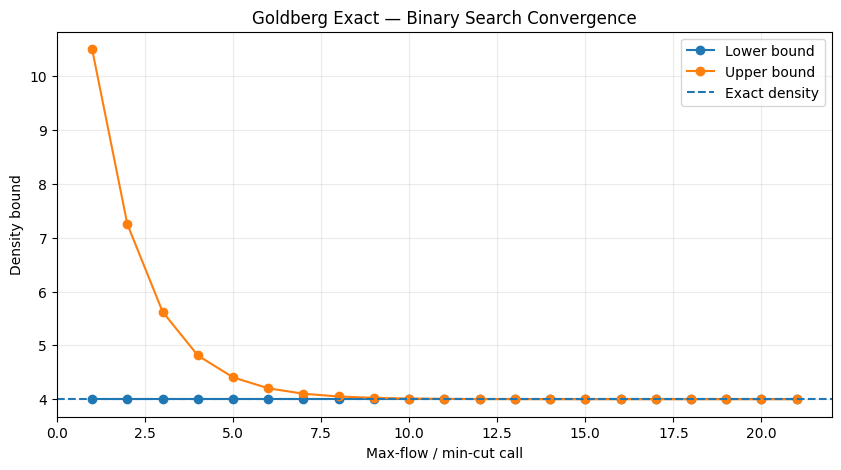

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    goldberg_history_df["Flow Call"],
    goldberg_history_df["Lower Bound"],
    marker="o",
    label="Lower bound"
)

plt.plot(
    goldberg_history_df["Flow Call"],
    goldberg_history_df["Upper Bound"],
    marker="o",
    label="Upper bound"
)

plt.axhline(
    goldberg_netscience["density"],
    linestyle="--",
    label="Exact density"
)

plt.xlabel("Max-flow / min-cut call")
plt.ylabel("Density bound")

plt.title(
    "Goldberg Exact — Binary Search Convergence"
)

plt.grid(alpha=0.25)
plt.legend()

plt.show()

In [52]:
def live_goldberg_visualization(
    G,
    pos,
    result,
    delay=0.7
):
    """
    Live visualization of Goldberg's
    binary-search + min-cut process.
    """

    history = result["history"]

    exact_vertices = set(
        result["vertices"].tolist()
    )

    for i, state in enumerate(history):

        clear_output(wait=True)

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(15, 6)
        )

        # ======================================
        # LEFT — CURRENT MIN-CUT CANDIDATE
        # ======================================

        ax = axes[0]

        candidate = set(
            state[
                "candidate_vertices"
            ].tolist()
        )

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color="lightgray",
            width=0.3,
            alpha=0.12
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=10,
            node_color="lightgray",
            alpha=0.20
        )

        if len(candidate) > 0:

            candidate_graph = G.subgraph(
                candidate
            )

            nx.draw_networkx_edges(
                candidate_graph,
                pos,
                ax=ax,
                width=1.0,
                alpha=0.65
            )

            nx.draw_networkx_nodes(
                candidate_graph,
                pos,
                ax=ax,
                node_size=50,
                alpha=0.85
            )

        # Highlight exact final community
        visible_exact = [
            v for v in exact_vertices
            if v in candidate
        ]

        if visible_exact:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_exact,
                ax=ax,
                node_size=100
            )

        feasibility_text = (
            "FEASIBLE"
            if state["feasible"]
            else "INFEASIBLE"
        )

        ax.set_title(
            f"Density guess = "
            f"{state['threshold']:.5f}\n"
            f"{feasibility_text}"
        )

        ax.axis("off")

        # ======================================
        # RIGHT — BINARY SEARCH
        # ======================================

        ax2 = axes[1]

        seen = history[:i + 1]

        calls = [
            h["flow_call"]
            for h in seen
        ]

        lower = [
            h["lower_bound"]
            for h in seen
        ]

        upper = [
            h["upper_bound"]
            for h in seen
        ]

        ax2.plot(
            calls,
            lower,
            marker="o",
            label="Lower bound"
        )

        ax2.plot(
            calls,
            upper,
            marker="o",
            label="Upper bound"
        )

        ax2.axhline(
            result["density"],
            linestyle="--",
            label="Exact density"
        )

        ax2.set_xlabel(
            "Max-flow call"
        )

        ax2.set_ylabel(
            "Density"
        )

        ax2.set_title(
            "Binary-search convergence"
        )

        ax2.grid(alpha=0.25)
        ax2.legend()

        fig.suptitle(
            "DENSISCOPE — ca-netscience — "
            "GOLDBERG EXACT\n"
            f"Flow call: {state['flow_call']} / "
            f"{result['flow_calls']}   |   "
            f"Candidate nodes: "
            f"{state['candidate_nodes']}   |   "
            f"Lower: {state['lower_bound']:.5f}   |   "
            f"Upper: {state['upper_bound']:.5f}",
            fontsize=13
        )

        plt.tight_layout(
            rect=[0, 0, 1, 0.90]
        )

        display(fig)

        plt.close(fig)

        time.sleep(delay)

    clear_output(wait=True)

    print(
        "✅ Goldberg live visualization complete."
    )

    print()
    print(
        "Exact nodes:",
        result["nodes"]
    )
    print(
        "Exact edges:",
        result["edges"]
    )
    print(
        "Exact density:",
        result["density"]
    )

In [53]:
live_goldberg_visualization(
    G_netscience_vis,
    pos_netscience,
    goldberg_netscience,
    delay=0.6
)

✅ Goldberg live visualization complete.

Exact nodes: 9
Exact edges: 36
Exact density: 4.0


In [54]:
def save_goldberg_video(
    G,
    pos,
    result,
    output_path,
    fps=2
):
    """
    Save Goldberg's exact densest-subgraph search
    as a presentation-quality MP4.

    Each frame corresponds to one max-flow/min-cut call.
    """

    history = result["history"]

    exact_vertices = set(
        result["vertices"].tolist()
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    fig.subplots_adjust(
        top=0.82,
        wspace=0.22
    )

    # -----------------------------------------
    # UPDATE ONE FRAME
    # -----------------------------------------

    def update(frame_index):

        state = history[frame_index]

        ax_graph = axes[0]
        ax_bounds = axes[1]

        ax_graph.clear()
        ax_bounds.clear()

        # =====================================
        # LEFT — CURRENT MIN-CUT CANDIDATE
        # =====================================

        candidate = set(
            state[
                "candidate_vertices"
            ].tolist()
        )

        # Entire graph faintly
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax_graph,
            edge_color="lightgray",
            width=0.3,
            alpha=0.10
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax_graph,
            node_size=9,
            node_color="lightgray",
            alpha=0.18
        )

        # Current candidate
        if len(candidate) > 0:

            candidate_graph = G.subgraph(
                candidate
            )

            nx.draw_networkx_edges(
                candidate_graph,
                pos,
                ax=ax_graph,
                width=0.9,
                alpha=0.60
            )

            nx.draw_networkx_nodes(
                candidate_graph,
                pos,
                ax=ax_graph,
                node_size=45,
                alpha=0.85
            )

        # Highlight vertices belonging to
        # final exact solution
        visible_exact = [
            v
            for v in exact_vertices
            if v in candidate
        ]

        if visible_exact:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_exact,
                ax=ax_graph,
                node_size=100
            )

        feasibility = (
            "FEASIBLE"
            if state["feasible"]
            else "INFEASIBLE"
        )

        ax_graph.set_title(
            f"Density guess = "
            f"{state['threshold']:.6f}\n"
            f"{feasibility}",
            fontsize=13
        )

        ax_graph.axis("off")

        # =====================================
        # RIGHT — BOUNDS CONVERGING
        # =====================================

        seen = history[
            :frame_index + 1
        ]

        calls = [
            h["flow_call"]
            for h in seen
        ]

        lower = [
            h["lower_bound"]
            for h in seen
        ]

        upper = [
            h["upper_bound"]
            for h in seen
        ]

        ax_bounds.plot(
            calls,
            lower,
            marker="o",
            linewidth=2,
            label="Lower bound"
        )

        ax_bounds.plot(
            calls,
            upper,
            marker="o",
            linewidth=2,
            label="Upper bound"
        )

        ax_bounds.axhline(
            result["density"],
            linestyle="--",
            linewidth=2,
            label="Exact optimum"
        )

        ax_bounds.set_xlim(
            1,
            result["flow_calls"]
        )

        all_lower = [
            h["lower_bound"]
            for h in history
        ]

        all_upper = [
            h["upper_bound"]
            for h in history
        ]

        y_min = min(all_lower)
        y_max = max(all_upper)

        padding = max(
            0.2,
            (y_max - y_min) * 0.08
        )

        ax_bounds.set_ylim(
            y_min - padding,
            y_max + padding
        )

        ax_bounds.set_xlabel(
            "Max-flow / min-cut call"
        )

        ax_bounds.set_ylabel(
            "Density bound"
        )

        ax_bounds.set_title(
            "Binary-search convergence"
        )

        ax_bounds.grid(
            alpha=0.20
        )

        ax_bounds.legend()

        # =====================================
        # HEADER
        # =====================================

        fig.suptitle(
            "DENSISCOPE — ca-netscience — GOLDBERG EXACT\n"
            f"Flow call: "
            f"{state['flow_call']} / "
            f"{result['flow_calls']}   |   "
            f"Candidate nodes: "
            f"{state['candidate_nodes']}   |   "
            f"Lower: "
            f"{state['lower_bound']:.6f}   |   "
            f"Upper: "
            f"{state['upper_bound']:.6f}",
            fontsize=13
        )

        return []

    # -----------------------------------------
    # CREATE MP4
    # -----------------------------------------

    animation = FuncAnimation(
        fig,
        update,
        frames=len(history),
        interval=1000 / fps,
        repeat=False
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={
            "title":
            "DensiScope - ca-netscience - Goldberg Exact"
        },
        bitrate=2200
    )

    animation.save(
        output_path,
        writer=writer,
        dpi=120
    )

    plt.close(fig)

    print(
        "✅ Final Goldberg video created."
    )

    print(
        "📹",
        output_path
    )

In [55]:
goldberg_netscience_video = os.path.join(
    PROJECT_ROOT,
    "videos",
    "ca-netscience_goldberg_exact.mp4"
)

print(
    "Generating Goldberg exact video..."
)

print()

save_goldberg_video(
    G_netscience_vis,
    pos_netscience,
    goldberg_netscience,
    goldberg_netscience_video,
    fps=2
)

Generating Goldberg exact video...

✅ Final Goldberg video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-netscience_goldberg_exact.mp4


In [56]:
Video(
    goldberg_netscience_video,
    embed=True,
    width=1000
)

# 8. Algorithm 4 — Exact Triangle Density

Ordinary density counts edges. Triangle density instead optimizes:

\[
\tau(S)=\frac{T(S)}{|V(S)|}
\]

where \(T(S)\) counts triangles inside the selected vertex set.

The exact solver uses a triangle-based max-flow/min-cut decision network together with binary search. The small `ca-netscience` instance is first used to validate triangle enumeration, the exact solver, and the live visualization.


In [57]:
def csr_to_igraph(A):
    """
    Convert a CSR undirected graph to igraph.

    Used only when needed for triangle / flow operations.
    """

    edge_u, edge_v = csr_upper_edges(A)

    edges = list(
        zip(
            edge_u.tolist(),
            edge_v.tolist()
        )
    )

    G = ig.Graph(
        n=A.shape[0],
        edges=edges,
        directed=False
    )

    return G


ig_netscience = csr_to_igraph(
    A_netscience
)

print(
    "igraph nodes:",
    ig_netscience.vcount()
)

print(
    "igraph edges:",
    ig_netscience.ecount()
)

assert (
    ig_netscience.vcount()
    == 379
)

assert (
    ig_netscience.ecount()
    == 914
)

print(
    "✅ CSR → igraph conversion verified."
)

igraph nodes: 379
igraph edges: 914
✅ CSR → igraph conversion verified.


In [58]:
triangle_start = time.perf_counter()

triangles_netscience = (
    ig_netscience.list_triangles()
)

triangle_time = (
    time.perf_counter()
    - triangle_start
)

num_triangles_netscience = len(
    triangles_netscience
)

print("=" * 45)
print(" TRIANGLE ANALYSIS — ca-netscience")
print("=" * 45)

print(
    "Nodes:",
    ig_netscience.vcount()
)

print(
    "Edges:",
    ig_netscience.ecount()
)

print(
    "Triangles:",
    num_triangles_netscience
)

print(
    "Enumeration time:",
    f"{triangle_time:.6f}",
    "seconds"
)

print("=" * 45)

 TRIANGLE ANALYSIS — ca-netscience
Nodes: 379
Edges: 914
Triangles: 921
Enumeration time: 0.000640 seconds


In [59]:
def verify_triangles(
    A,
    triangles,
    sample_size=100
):
    """
    Verify triangle enumeration using CSR adjacency.
    """

    if len(triangles) == 0:

        print(
            "No triangles found."
        )

        return True

    # Check all if small,
    # otherwise sample up to sample_size
    count = min(
        len(triangles),
        sample_size
    )

    indices = np.linspace(
        0,
        len(triangles) - 1,
        count,
        dtype=int
    )

    for idx in indices:

        a, b, c = triangles[idx]

        assert A[a, b] != 0
        assert A[a, c] != 0
        assert A[b, c] != 0

    return True


assert verify_triangles(
    A_netscience,
    triangles_netscience
)

print(
    "✅ Triangle enumeration verified."
)

✅ Triangle enumeration verified.


In [60]:
def triangle_flow_memory_estimate(
    num_vertices,
    num_triangles
):
    """
    Rough safety estimate for the exact
    triangle-density flow construction.

    This is intentionally conservative.
    """

    # Original vertex nodes
    vertex_nodes = int(
        num_vertices
    )

    # One auxiliary node per triangle
    triangle_nodes = int(
        num_triangles
    )

    # Source + sink
    total_nodes = (
        vertex_nodes
        + triangle_nodes
        + 2
    )

    # Approximate directed arcs:
    #
    # source -> each original vertex
    # each original vertex -> sink
    #
    # triangle interactions can require
    # several directed arcs per triangle.
    #
    # Use a conservative estimate of
    # ~8 arcs per triangle.
    estimated_arcs = (
        2 * vertex_nodes
        + 8 * triangle_nodes
    )

    # Very rough memory estimate:
    # assume ~40 bytes per graph arc/node
    # after igraph / Python overhead.
    estimated_bytes = (
        total_nodes * 40
        + estimated_arcs * 40
    )

    estimated_mb = (
        estimated_bytes
        / (1024 ** 2)
    )

    return {
        "flow_nodes":
            total_nodes,

        "estimated_arcs":
            estimated_arcs,

        "estimated_memory_mb":
            estimated_mb
    }


triangle_memory = (
    triangle_flow_memory_estimate(
        A_netscience.shape[0],
        num_triangles_netscience
    )
)

print("=" * 48)
print(" EXACT TRIANGLE FLOW SAFETY CHECK")
print("=" * 48)

print(
    f"Original vertices:      "
    f"{A_netscience.shape[0]:,}"
)

print(
    f"Triangle nodes:         "
    f"{num_triangles_netscience:,}"
)

print(
    f"Estimated flow nodes:   "
    f"{triangle_memory['flow_nodes']:,}"
)

print(
    f"Estimated flow arcs:    "
    f"{triangle_memory['estimated_arcs']:,}"
)

print(
    f"Estimated memory:       "
    f"{triangle_memory['estimated_memory_mb']:.2f} MB"
)

print("=" * 48)

 EXACT TRIANGLE FLOW SAFETY CHECK
Original vertices:      379
Triangle nodes:         921
Estimated flow nodes:   1,302
Estimated flow arcs:    8,126
Estimated memory:       0.36 MB


In [61]:
triangles_array = np.asarray(
    triangles_netscience,
    dtype=np.int32
)

assert triangles_array.shape == (
    num_triangles_netscience,
    3
)

# Number of triangles each vertex participates in
triangle_incidence = np.zeros(
    A_netscience.shape[0],
    dtype=np.int32
)

for col in range(3):
    np.add.at(
        triangle_incidence,
        triangles_array[:, col],
        1
    )

print("=" * 48)
print(" TRIANGLE DATA PREPARATION")
print("=" * 48)

print(
    "Triangle array shape:",
    triangles_array.shape
)

print(
    "Total triangles:",
    len(triangles_array)
)

print(
    "Sum of vertex triangle incidences:",
    int(triangle_incidence.sum())
)

print(
    "Expected incidence sum:",
    3 * len(triangles_array)
)

print(
    "Maximum triangles touching one vertex:",
    int(triangle_incidence.max())
)

assert (
    triangle_incidence.sum()
    == 3 * len(triangles_array)
)

print()
print("✅ Triangle incidence counts verified.")

 TRIANGLE DATA PREPARATION
Triangle array shape: (921, 3)
Total triangles: 921
Sum of vertex triangle incidences: 2763
Expected incidence sum: 2763
Maximum triangles touching one vertex: 75

✅ Triangle incidence counts verified.


In [62]:
def induced_triangle_stats(
    triangle_array,
    vertices,
    total_nodes
):
    """
    Count triangles completely contained inside
    a given vertex subset.
    """

    vertices = np.asarray(
        vertices,
        dtype=np.int32
    )

    if len(vertices) == 0:
        return 0, 0.0

    active = np.zeros(
        total_nodes,
        dtype=bool
    )

    active[vertices] = True

    inside = (
        active[triangle_array[:, 0]]
        &
        active[triangle_array[:, 1]]
        &
        active[triangle_array[:, 2]]
    )

    triangle_count = int(
        np.count_nonzero(inside)
    )

    triangle_density = (
        triangle_count
        / len(vertices)
    )

    return (
        triangle_count,
        float(triangle_density)
    )


# -----------------------------------------
# Evaluate our Charikar K9 as a baseline
# -----------------------------------------

charikar_triangle_count, charikar_triangle_density = (
    induced_triangle_stats(
        triangles_array,
        charikar_netscience["vertices"],
        A_netscience.shape[0]
    )
)

print("=" * 48)
print(" CHARIKAR SUBGRAPH — TRIANGLE METRICS")
print("=" * 48)

print(
    "Vertices:",
    charikar_netscience["nodes"]
)

print(
    "Triangles:",
    charikar_triangle_count
)

print(
    "Triangle density:",
    charikar_triangle_density
)

print("=" * 48)

 CHARIKAR SUBGRAPH — TRIANGLE METRICS
Vertices: 9
Triangles: 84
Triangle density: 9.333333333333334


In [63]:
def triangle_density_decision(
    num_vertices,
    triangle_array,
    triangle_incidence,
    alpha
):
    """
    Exact decision procedure for Triangle Densest Subgraph.

    Tests whether there exists S such that:

        triangles(S) / |S| > alpha

    using the published max-flow/min-cut construction.

    Returns
    -------
    feasible
    candidate_vertices
    cut_value
    """

    n = int(num_vertices)
    t_count = int(
        len(triangle_array)
    )

    if n == 0 or t_count == 0:

        return (
            False,
            np.array([], dtype=np.int32),
            0.0
        )

    # -----------------------------------------
    # Flow node IDs
    #
    # Original vertices: 0 ... n-1
    # Triangle nodes:    n ... n+t-1
    # Source:            n+t
    # Sink:              n+t+1
    # -----------------------------------------

    triangle_offset = n

    source = (
        n + t_count
    )

    sink = (
        n + t_count + 1
    )

    flow_edges = []
    capacities = []

    # =========================================
    # SOURCE -> ORIGINAL VERTEX
    #
    # capacity = number of triangles
    # containing that vertex
    # =========================================

    for v in range(n):

        flow_edges.append(
            (source, v)
        )

        capacities.append(
            float(
                triangle_incidence[v]
            )
        )

    # =========================================
    # ORIGINAL VERTEX -> SINK
    #
    # capacity = 3 * alpha
    # =========================================

    sink_capacity = (
        3.0 * float(alpha)
    )

    for v in range(n):

        flow_edges.append(
            (v, sink)
        )

        capacities.append(
            sink_capacity
        )

    # =========================================
    # VERTEX <-> TRIANGLE AUXILIARY NODE
    #
    # vertex -> triangle : capacity 1
    # triangle -> vertex : capacity 2
    # =========================================

    for triangle_id, triangle in enumerate(
        triangle_array
    ):

        triangle_node = (
            triangle_offset
            + triangle_id
        )

        u = int(triangle[0])
        v = int(triangle[1])
        w = int(triangle[2])

        for vertex in (u, v, w):

            flow_edges.append(
                (vertex, triangle_node)
            )

            capacities.append(
                1.0
            )

            flow_edges.append(
                (triangle_node, vertex)
            )

            capacities.append(
                2.0
            )

    # =========================================
    # Build flow graph
    # =========================================

    F = ig.Graph(
        n=n + t_count + 2,
        edges=flow_edges,
        directed=True
    )

    F.es["capacity"] = capacities

    # =========================================
    # Minimum s-t cut
    # =========================================

    cut = F.mincut(
        source=source,
        target=sink,
        capacity="capacity"
    )

    cut_value = float(
        cut.value
    )

    part0 = cut.partition[0]
    part1 = cut.partition[1]

    if source in part0:
        source_side = part0
    else:
        source_side = part1

    # Only original graph vertices matter
    candidate = np.array(
        [
            int(x)
            for x in source_side
            if x < n
        ],
        dtype=np.int32
    )

    # Source-only cut has capacity 3 * t.
    #
    # A strictly smaller cut proves
    # triangle_density > alpha.
    baseline_cut = float(
        3 * t_count
    )

    tolerance = (
        1e-9
        * max(
            1.0,
            baseline_cut
        )
    )

    feasible = (
        cut_value
        < baseline_cut
        - tolerance
    )

    if not feasible:

        candidate = np.array(
            [],
            dtype=np.int32
        )

    return (
        bool(feasible),
        candidate,
        cut_value
    )


print(
    "✅ Exact triangle-density decision function defined."
)

✅ Exact triangle-density decision function defined.


In [64]:
print(
    "Testing alpha = 5.0..."
)

(
    triangle_feasible_5,
    triangle_candidate_5,
    triangle_cut_5
) = triangle_density_decision(
    A_netscience.shape[0],
    triangles_array,
    triangle_incidence,
    5.0
)

print(
    "Feasible:",
    triangle_feasible_5
)

print(
    "Candidate nodes:",
    len(triangle_candidate_5)
)

print(
    "Min-cut:",
    triangle_cut_5
)

assert triangle_feasible_5 is True


# -----------------------------------------
# Guaranteed impossible upper test
# -----------------------------------------

impossible_threshold = (
    len(triangles_array)
    / 3.0
)

print()
print(
    f"Testing alpha = "
    f"{impossible_threshold:.3f}..."
)

(
    triangle_feasible_high,
    triangle_candidate_high,
    triangle_cut_high
) = triangle_density_decision(
    A_netscience.shape[0],
    triangles_array,
    triangle_incidence,
    impossible_threshold
)

print(
    "Feasible:",
    triangle_feasible_high
)

print(
    "Candidate nodes:",
    len(triangle_candidate_high)
)

assert triangle_feasible_high is False

print()
print(
    "✅ Triangle-density decision tests passed."
)

Testing alpha = 5.0...
Feasible: True
Candidate nodes: 52
Min-cut: 2511.0

Testing alpha = 307.000...
Feasible: False
Candidate nodes: 0

✅ Triangle-density decision tests passed.


In [65]:
def exact_triangle_densest_subgraph(
    num_vertices,
    triangle_array,
    triangle_incidence,
    initial_vertices=None,
    record_history=False
):
    """
    Exact Triangle Densest Subgraph solver.

    Maximizes:

        tau(S) = triangles(S) / |S|

    using binary search + max-flow/min-cut.
    """

    n = int(num_vertices)

    total_triangles = int(
        len(triangle_array)
    )

    start_time = (
        time.perf_counter()
    )

    # ==========================================
    # Edge cases
    # ==========================================

    if n == 0:

        return {
            "vertices":
                np.array([], dtype=np.int32),

            "triangle_count": 0,

            "triangle_density": 0.0,

            "nodes": 0,

            "runtime": 0.0,

            "flow_calls": 0,

            "history": []
        }

    if total_triangles == 0:

        return {
            "vertices":
                np.array([0], dtype=np.int32),

            "triangle_count": 0,

            "triangle_density": 0.0,

            "nodes": 1,

            "runtime":
                time.perf_counter()
                - start_time,

            "flow_calls": 0,

            "history": []
        }

    # ==========================================
    # Initial feasible lower-bound solution
    # ==========================================

    full_vertices = np.arange(
        n,
        dtype=np.int32
    )

    full_triangle_density = (
        total_triangles / n
    )

    best_vertices = full_vertices

    best_triangle_count = (
        total_triangles
    )

    best_density = (
        full_triangle_density
    )

    # Use Charikar's result as an additional
    # exact-safe lower bound.
    if initial_vertices is not None:

        (
            initial_triangles,
            initial_tau
        ) = induced_triangle_stats(
            triangle_array,
            initial_vertices,
            n
        )

        if initial_tau > best_density:

            best_vertices = np.asarray(
                initial_vertices,
                dtype=np.int32
            ).copy()

            best_triangle_count = (
                initial_triangles
            )

            best_density = (
                initial_tau
            )

    lower = float(
        best_density
    )

    # ==========================================
    # Safe upper bounds
    # ==========================================

    # Published complete-graph upper bound:
    #
    # C(n,3) / n
    # = (n-1)(n-2)/6
    paper_upper = (
        (n - 1)
        * (n - 2)
        / 6.0
    )

    # Tighter exact-safe bound:
    #
    # 3*t(S)/|S| is average triangle
    # participation, which cannot exceed
    # maximum vertex triangle participation.
    incidence_upper = (
        float(
            triangle_incidence.max()
        )
        / 3.0
    )

    upper = min(
        paper_upper,
        incidence_upper
    )

    # ==========================================
    # Exact stopping gap
    # ==========================================

    if n > 1:

        exact_gap = (
            1.0
            / (n * (n - 1))
        )

    else:

        exact_gap = 1.0

    flow_calls = 0

    history = []

    max_iterations = 100

    # ==========================================
    # BINARY SEARCH
    # ==========================================

    while (
        upper - lower
        >= exact_gap
        and flow_calls < max_iterations
    ):

        alpha = (
            lower + upper
        ) / 2.0

        (
            feasible,
            candidate,
            cut_value
        ) = triangle_density_decision(
            n,
            triangle_array,
            triangle_incidence,
            alpha
        )

        flow_calls += 1

        candidate_triangles = 0
        candidate_density = 0.0

        if feasible:

            (
                candidate_triangles,
                candidate_density
            ) = induced_triangle_stats(
                triangle_array,
                candidate,
                n
            )

            lower = alpha

            if (
                candidate_density
                > best_density
            ):

                best_density = (
                    candidate_density
                )

                best_vertices = (
                    candidate.copy()
                )

                best_triangle_count = (
                    candidate_triangles
                )

        else:

            upper = alpha

        # ======================================
        # Visualization history
        # ======================================

        if record_history:

            history.append({
                "flow_call":
                    int(flow_calls),

                "threshold":
                    float(alpha),

                "feasible":
                    bool(feasible),

                "lower_bound":
                    float(lower),

                "upper_bound":
                    float(upper),

                "candidate_nodes":
                    int(len(candidate)),

                "candidate_triangles":
                    int(candidate_triangles),

                "candidate_density":
                    float(candidate_density),

                "candidate_vertices":
                    (
                        candidate.copy()
                        if feasible
                        else np.array(
                            [],
                            dtype=np.int32
                        )
                    )
            })

    runtime = (
        time.perf_counter()
        - start_time
    )

    return {
        "vertices":
            np.asarray(
                best_vertices,
                dtype=np.int32
            ),

        "nodes":
            int(len(best_vertices)),

        "triangle_count":
            int(best_triangle_count),

        "triangle_density":
            float(best_density),

        "runtime":
            float(runtime),

        "flow_calls":
            int(flow_calls),

        "lower_bound":
            float(lower),

        "upper_bound":
            float(upper),

        "exact_gap":
            float(exact_gap),

        "history":
            history
    }


print(
    "✅ Exact Triangle-Density solver defined."
)

✅ Exact Triangle-Density solver defined.


In [66]:
gc.collect()

show_memory(
    "Before Triangle Exact — ca-netscience"
)

print()
print(
    "Running Exact Triangle-Density algorithm..."
)
print()

triangle_exact_netscience = (
    exact_triangle_densest_subgraph(
        A_netscience.shape[0],
        triangles_array,
        triangle_incidence,

        # Excellent exact-safe starting solution:
        initial_vertices=
            charikar_netscience[
                "vertices"
            ],

        record_history=True
    )
)

print()

show_memory(
    "After Triangle Exact — ca-netscience"
)

print()

print("=" * 58)
print(
    "     EXACT TRIANGLE DENSITY — ca-netscience"
)
print("=" * 58)

print(
    f"Original nodes:          "
    f"{A_netscience.shape[0]:,}"
)

print(
    f"Original edges:          "
    f"{A_netscience.nnz // 2:,}"
)

print(
    f"Original triangles:      "
    f"{len(triangles_array):,}"
)

print("-" * 58)

print(
    f"Result nodes:            "
    f"{triangle_exact_netscience['nodes']:,}"
)

print(
    f"Result triangles:        "
    f"{triangle_exact_netscience['triangle_count']:,}"
)

print(
    f"Exact triangle density:  "
    f"{triangle_exact_netscience['triangle_density']:.8f}"
)

print(
    f"Max-flow calls:          "
    f"{triangle_exact_netscience['flow_calls']}"
)

print(
    f"Final lower bound:       "
    f"{triangle_exact_netscience['lower_bound']:.8f}"
)

print(
    f"Final upper bound:       "
    f"{triangle_exact_netscience['upper_bound']:.8f}"
)

print(
    f"Execution time:          "
    f"{triangle_exact_netscience['runtime']:.6f} seconds"
)

print("=" * 58)

🧠 Before Triangle Exact — ca-netscience memory status
   Python process: 0.453 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.02 GB

Running Exact Triangle-Density algorithm...


🧠 After Triangle Exact — ca-netscience memory status
   Python process: 0.453 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.02 GB

     EXACT TRIANGLE DENSITY — ca-netscience
Original nodes:          379
Original edges:          914
Original triangles:      921
----------------------------------------------------------
Result nodes:            9
Result triangles:        84
Exact triangle density:  9.33333333
Max-flow calls:          22
Final lower bound:       9.33333333
Final upper bound:       9.33333707
Execution time:          0.091757 seconds


In [67]:
(
    verified_triangle_count,
    verified_triangle_density
) = induced_triangle_stats(
    triangles_array,
    triangle_exact_netscience[
        "vertices"
    ],
    A_netscience.shape[0]
)

print("=" * 52)
print(
    " EXACT TRIANGLE RESULT VERIFICATION"
)
print("=" * 52)

print(
    "Reported nodes:",
    triangle_exact_netscience[
        "nodes"
    ]
)

print(
    "Verified nodes:",
    len(
        triangle_exact_netscience[
            "vertices"
        ]
    )
)

print()

print(
    "Reported triangles:",
    triangle_exact_netscience[
        "triangle_count"
    ]
)

print(
    "Verified triangles:",
    verified_triangle_count
)

print()

print(
    "Reported triangle density:",
    triangle_exact_netscience[
        "triangle_density"
    ]
)

print(
    "Verified triangle density:",
    verified_triangle_density
)

assert (
    verified_triangle_count
    == triangle_exact_netscience[
        "triangle_count"
    ]
)

assert np.isclose(
    verified_triangle_density,
    triangle_exact_netscience[
        "triangle_density"
    ]
)

print()
print(
    "✅ EXACT TRIANGLE RESULT VERIFIED."
)

 EXACT TRIANGLE RESULT VERIFICATION
Reported nodes: 9
Verified nodes: 9

Reported triangles: 84
Verified triangles: 84

Reported triangle density: 9.333333333333334
Verified triangle density: 9.333333333333334

✅ EXACT TRIANGLE RESULT VERIFIED.


In [68]:
charikar_set = set(
    charikar_netscience["vertices"].tolist()
)

goldberg_set = set(
    goldberg_netscience["vertices"].tolist()
)

triangle_set = set(
    triangle_exact_netscience["vertices"].tolist()
)

print("=" * 52)
print(" DENSE SUBGRAPH VERTEX-SET COMPARISON")
print("=" * 52)

print(
    "Charikar == Goldberg:",
    charikar_set == goldberg_set
)

print(
    "Charikar == Triangle Exact:",
    charikar_set == triangle_set
)

print(
    "Goldberg == Triangle Exact:",
    goldberg_set == triangle_set
)

print()

print(
    "Charikar vertices:",
    sorted(charikar_set)
)

print(
    "Triangle Exact vertices:",
    sorted(triangle_set)
)

 DENSE SUBGRAPH VERTEX-SET COMPARISON
Charikar == Goldberg: True
Charikar == Triangle Exact: True
Goldberg == Triangle Exact: True

Charikar vertices: [3, 4, 14, 15, 44, 45, 46, 175, 176]
Triangle Exact vertices: [3, 4, 14, 15, 44, 45, 46, 175, 176]


In [69]:
triangle_vertices = (
    triangle_exact_netscience["vertices"]
)

A_triangle_best = A_netscience[
    triangle_vertices
][:, triangle_vertices]

triangle_result_edges = int(
    A_triangle_best.nnz // 2
)

triangle_result_edge_density = (
    triangle_result_edges
    / len(triangle_vertices)
)

print("=" * 52)
print(" TRIANGLE-EXACT STRUCTURAL METRICS")
print("=" * 52)

print(
    "Vertices:",
    len(triangle_vertices)
)

print(
    "Edges:",
    triangle_result_edges
)

print(
    "Edge density |E|/|V|:",
    triangle_result_edge_density
)

print(
    "Triangles:",
    triangle_exact_netscience[
        "triangle_count"
    ]
)

print(
    "Triangle density:",
    triangle_exact_netscience[
        "triangle_density"
    ]
)

 TRIANGLE-EXACT STRUCTURAL METRICS
Vertices: 9
Edges: 36
Edge density |E|/|V|: 4.0
Triangles: 84
Triangle density: 9.333333333333334


In [70]:
triangle_history_df = pd.DataFrame([
    {
        "Flow Call":
            h["flow_call"],

        "Threshold":
            h["threshold"],

        "Feasible":
            h["feasible"],

        "Lower Bound":
            h["lower_bound"],

        "Upper Bound":
            h["upper_bound"],

        "Candidate Nodes":
            h["candidate_nodes"],

        "Candidate Triangles":
            h["candidate_triangles"],

        "Candidate Density":
            h["candidate_density"]
    }

    for h in
    triangle_exact_netscience[
        "history"
    ]
])

display(triangle_history_df)

,Flow Call,Threshold,Feasible,Lower Bound,Upper Bound,Candidate Nodes,Candidate Triangles,Candidate Density
0,1,17.166667,False,9.333333,17.166667,0,0,0.0
1,2,13.250000,False,9.333333,13.250000,0,0,0.0
2,3,11.291667,False,9.333333,11.291667,0,0,0.0
3,4,10.312500,False,9.333333,10.312500,0,0,0.0
4,5,9.822917,False,9.333333,9.822917,0,0,0.0
5,6,9.578125,False,9.333333,9.578125,0,0,0.0
6,7,9.455729,False,9.333333,9.455729,0,0,0.0
7,8,9.394531,False,9.333333,9.394531,0,0,0.0
8,9,9.363932,False,9.333333,9.363932,0,0,0.0
9,10,9.348633,False,9.333333,9.348633,0,0,0.0


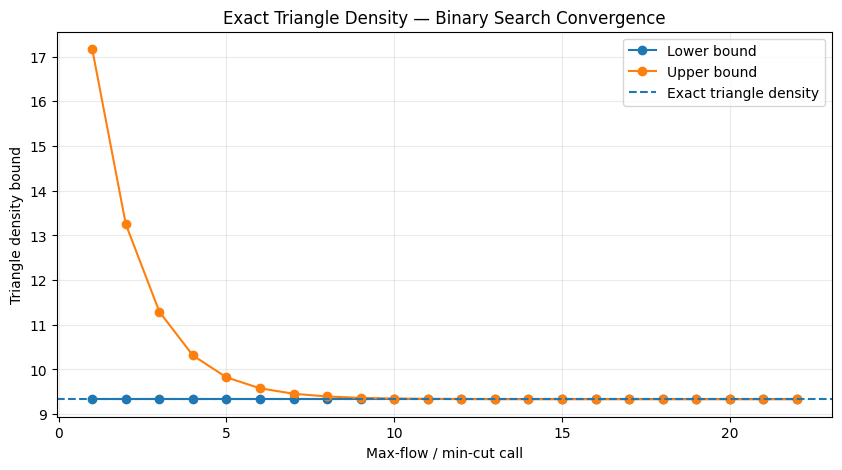

In [71]:
plt.figure(figsize=(10, 5))

plt.plot(
    triangle_history_df[
        "Flow Call"
    ],
    triangle_history_df[
        "Lower Bound"
    ],
    marker="o",
    label="Lower bound"
)

plt.plot(
    triangle_history_df[
        "Flow Call"
    ],
    triangle_history_df[
        "Upper Bound"
    ],
    marker="o",
    label="Upper bound"
)

plt.axhline(
    triangle_exact_netscience[
        "triangle_density"
    ],
    linestyle="--",
    label="Exact triangle density"
)

plt.xlabel(
    "Max-flow / min-cut call"
)

plt.ylabel(
    "Triangle density bound"
)

plt.title(
    "Exact Triangle Density — "
    "Binary Search Convergence"
)

plt.grid(alpha=0.25)
plt.legend()

plt.show()

In [72]:
def live_triangle_exact_visualization(
    G,
    pos,
    result,
    delay=0.6
):

    history = result["history"]

    exact_vertices = set(
        result["vertices"].tolist()
    )

    for i, state in enumerate(history):

        clear_output(wait=True)

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(15, 6)
        )

        # =====================================
        # LEFT — CURRENT CANDIDATE
        # =====================================

        ax = axes[0]

        candidate = set(
            state[
                "candidate_vertices"
            ].tolist()
        )

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color="lightgray",
            width=0.30,
            alpha=0.10
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=9,
            node_color="lightgray",
            alpha=0.18
        )

        if candidate:

            candidate_graph = G.subgraph(
                candidate
            )

            nx.draw_networkx_edges(
                candidate_graph,
                pos,
                ax=ax,
                width=1.0,
                alpha=0.60
            )

            nx.draw_networkx_nodes(
                candidate_graph,
                pos,
                ax=ax,
                node_size=48,
                alpha=0.85
            )

        # Final exact solution highlighted
        visible_exact = [
            v
            for v in exact_vertices
            if v in candidate
        ]

        if visible_exact:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_exact,
                ax=ax,
                node_size=105
            )

        feasibility = (
            "FEASIBLE"
            if state["feasible"]
            else "INFEASIBLE"
        )

        ax.set_title(
            f"Triangle density guess = "
            f"{state['threshold']:.4f}\n"
            f"{feasibility}"
        )

        ax.axis("off")

        # =====================================
        # RIGHT — BOUNDS
        # =====================================

        ax2 = axes[1]

        seen = history[
            :i + 1
        ]

        calls = [
            h["flow_call"]
            for h in seen
        ]

        lower = [
            h["lower_bound"]
            for h in seen
        ]

        upper = [
            h["upper_bound"]
            for h in seen
        ]

        ax2.plot(
            calls,
            lower,
            marker="o",
            label="Lower bound"
        )

        ax2.plot(
            calls,
            upper,
            marker="o",
            label="Upper bound"
        )

        ax2.axhline(
            result[
                "triangle_density"
            ],
            linestyle="--",
            label="Exact optimum"
        )

        ax2.set_xlabel(
            "Max-flow call"
        )

        ax2.set_ylabel(
            "Triangle density"
        )

        ax2.set_title(
            "Triangle-density convergence"
        )

        ax2.grid(alpha=0.25)
        ax2.legend()

        # =====================================
        # HEADER
        # =====================================

        fig.suptitle(
            "DENSISCOPE — ca-netscience — "
            "EXACT TRIANGLE DENSITY\n"
            f"Flow call: "
            f"{state['flow_call']} / "
            f"{result['flow_calls']}   |   "
            f"Candidate nodes: "
            f"{state['candidate_nodes']}   |   "
            f"Candidate triangles: "
            f"{state['candidate_triangles']}   |   "
            f"Lower: "
            f"{state['lower_bound']:.4f}   |   "
            f"Upper: "
            f"{state['upper_bound']:.4f}",
            fontsize=13
        )

        plt.tight_layout(
            rect=[0, 0, 1, 0.90]
        )

        display(fig)

        plt.close(fig)

        time.sleep(delay)

    clear_output(wait=True)

    print(
        "✅ Exact Triangle live visualization complete."
    )

    print()

    print(
        "Exact vertices:",
        result["nodes"]
    )

    print(
        "Exact triangles:",
        result["triangle_count"]
    )

    print(
        "Exact triangle density:",
        result["triangle_density"]
    )

In [73]:
live_triangle_exact_visualization(
    G_netscience_vis,
    pos_netscience,
    triangle_exact_netscience,
    delay=0.6
)

✅ Exact Triangle live visualization complete.

Exact vertices: 9
Exact triangles: 84
Exact triangle density: 9.333333333333334


In [74]:
def save_triangle_exact_video(
    G,
    pos,
    result,
    output_path,
    fps=2
):
    """
    Save Exact Triangle-Density search as MP4.
    One frame = one max-flow/min-cut call.
    """

    history = result["history"]

    exact_vertices = set(
        result["vertices"].tolist()
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    fig.subplots_adjust(
        top=0.82,
        wspace=0.22
    )

    def update(frame_index):

        state = history[frame_index]

        ax_graph = axes[0]
        ax_bounds = axes[1]

        ax_graph.clear()
        ax_bounds.clear()

        # =====================================
        # LEFT — CURRENT CANDIDATE
        # =====================================

        candidate = set(
            state["candidate_vertices"].tolist()
        )

        # Entire graph in background
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax_graph,
            edge_color="lightgray",
            width=0.30,
            alpha=0.10
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax_graph,
            node_size=9,
            node_color="lightgray",
            alpha=0.18
        )

        # Current candidate
        if candidate:

            candidate_graph = G.subgraph(
                candidate
            )

            nx.draw_networkx_edges(
                candidate_graph,
                pos,
                ax=ax_graph,
                width=0.9,
                alpha=0.60
            )

            nx.draw_networkx_nodes(
                candidate_graph,
                pos,
                ax=ax_graph,
                node_size=48,
                alpha=0.85
            )

        # Highlight final exact community
        visible_exact = [
            v
            for v in exact_vertices
            if v in candidate
        ]

        if visible_exact:

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=visible_exact,
                ax=ax_graph,
                node_size=105
            )

        feasibility = (
            "FEASIBLE"
            if state["feasible"]
            else "INFEASIBLE"
        )

        ax_graph.set_title(
            f"Triangle-density guess = "
            f"{state['threshold']:.5f}\n"
            f"{feasibility}",
            fontsize=13
        )

        ax_graph.axis("off")

        # =====================================
        # RIGHT — BINARY-SEARCH BOUNDS
        # =====================================

        seen = history[
            :frame_index + 1
        ]

        calls = [
            h["flow_call"]
            for h in seen
        ]

        lower = [
            h["lower_bound"]
            for h in seen
        ]

        upper = [
            h["upper_bound"]
            for h in seen
        ]

        ax_bounds.plot(
            calls,
            lower,
            marker="o",
            linewidth=2,
            label="Lower bound"
        )

        ax_bounds.plot(
            calls,
            upper,
            marker="o",
            linewidth=2,
            label="Upper bound"
        )

        ax_bounds.axhline(
            result["triangle_density"],
            linestyle="--",
            linewidth=2,
            label="Exact optimum"
        )

        ax_bounds.set_xlabel(
            "Max-flow / min-cut call"
        )

        ax_bounds.set_ylabel(
            "Triangle density"
        )

        ax_bounds.set_title(
            "Exact triangle-density convergence"
        )

        ax_bounds.grid(alpha=0.20)
        ax_bounds.legend()

        # =====================================
        # HEADER
        # =====================================

        fig.suptitle(
            "DENSISCOPE — ca-netscience — "
            "EXACT TRIANGLE DENSITY\n"
            f"Flow call: "
            f"{state['flow_call']} / "
            f"{result['flow_calls']}   |   "
            f"Candidate nodes: "
            f"{state['candidate_nodes']}   |   "
            f"Triangles: "
            f"{state['candidate_triangles']}   |   "
            f"Lower: {state['lower_bound']:.4f}   |   "
            f"Upper: {state['upper_bound']:.4f}",
            fontsize=13
        )

        return []

    animation = FuncAnimation(
        fig,
        update,
        frames=len(history),
        interval=1000 / fps,
        repeat=False
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={
            "title":
            "DensiScope - Exact Triangle Density"
        },
        bitrate=2200
    )

    animation.save(
        output_path,
        writer=writer,
        dpi=120
    )

    plt.close(fig)

    print(
        "✅ Exact Triangle video created."
    )

    print(
        "📹",
        output_path
    )

In [75]:
triangle_netscience_video = os.path.join(
    PROJECT_ROOT,
    "videos",
    "ca-netscience_triangle_exact.mp4"
)

print(
    "Generating Exact Triangle-Density video..."
)

print()

save_triangle_exact_video(
    G_netscience_vis,
    pos_netscience,
    triangle_exact_netscience,
    triangle_netscience_video,
    fps=2
)

Generating Exact Triangle-Density video...

✅ Exact Triangle video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-netscience_triangle_exact.mp4


In [76]:
Video(
    triangle_netscience_video,
    embed=True,
    width=1000
)

# 9. Multi-Dataset Pipeline

The remaining collaboration networks are downloaded, preprocessed, validated, and cached one at a time.

Only one large graph is held in memory at once, which is critical for the DBLP experiment.


In [77]:
DATASET_CONFIG = {

    "ca-CSphd": {
        "download_candidates": [
            "https://nrvis.com/download/data/ca/ca-csphd.zip",
            "https://nrvis.com/download/data/ca/ca-CSphd.zip"
        ]
    },

    "ca-GrQc": {
        "download_candidates": [
            "https://nrvis.com/download/data/ca/ca-grqc.zip",
            "https://nrvis.com/download/data/ca/ca-GrQc.zip"
        ]
    },

    "ca-HepTh": {
        "download_candidates": [
            "https://nrvis.com/download/data/ca/ca-hepth.zip",
            "https://nrvis.com/download/data/ca/ca-HepTh.zip"
        ]
    },

    "ca-dblp-2012": {
        "download_candidates": [
            "https://nrvis.com/download/data/ca/ca-dblp-2012.zip",
            "https://nrvis.com/download/data/ca/CA-DBLP-2012.zip"
        ]
    }
}

print(
    "✅ Remaining dataset configuration created."
)

for name in DATASET_CONFIG:
    print("•", name)

✅ Remaining dataset configuration created.
• ca-CSphd
• ca-GrQc
• ca-HepTh
• ca-dblp-2012


In [78]:
import requests
import zipfile


def download_and_extract_dataset(
    dataset_name,
    download_candidates
):
    """
    Download a Network Repository graph safely.

    Reuses existing downloads so Colab does not
    repeatedly download the same dataset.
    """

    raw_root = os.path.join(
        PROJECT_ROOT,
        "data",
        "raw"
    )

    extract_folder = os.path.join(
        raw_root,
        dataset_name
    )

    os.makedirs(
        extract_folder,
        exist_ok=True
    )

    zip_path = os.path.join(
        raw_root,
        f"{dataset_name}.zip"
    )

    # ==========================================
    # DOWNLOAD
    # ==========================================

    if not os.path.exists(zip_path):

        success = False

        for url in download_candidates:

            print(
                f"Trying: {url}"
            )

            try:

                with requests.get(
                    url,
                    stream=True,
                    timeout=120
                ) as response:

                    if response.status_code != 200:
                        print(
                            "  ❌ HTTP",
                            response.status_code
                        )
                        continue

                    with open(
                        zip_path,
                        "wb"
                    ) as f:

                        for chunk in response.iter_content(
                            chunk_size=1024 * 1024
                        ):

                            if chunk:
                                f.write(chunk)

                # Confirm it is actually ZIP
                if zipfile.is_zipfile(
                    zip_path
                ):

                    success = True

                    print(
                        "  ✅ Download successful."
                    )

                    break

                else:

                    print(
                        "  ❌ Download was not a valid ZIP."
                    )

                    if os.path.exists(zip_path):
                        os.remove(zip_path)

            except Exception as e:

                print(
                    "  ❌",
                    type(e).__name__,
                    str(e)
                )

        if not success:

            raise RuntimeError(
                f"Could not download {dataset_name}"
            )

    else:

        print(
            f"✅ {dataset_name} ZIP already exists."
        )

    # ==========================================
    # EXTRACT
    # ==========================================

    existing_files = []

    for root, dirs, files in os.walk(
        extract_folder
    ):
        existing_files.extend(
            [
                os.path.join(root, f)
                for f in files
            ]
        )

    if len(existing_files) == 0:

        print(
            "Extracting..."
        )

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            z.extractall(
                extract_folder
            )

        print(
            "✅ Extraction complete."
        )

    # ==========================================
    # FIND GRAPH FILE
    # ==========================================

    candidates = []

    valid_extensions = (
        ".mtx",
        ".edges",
        ".txt",
        ".csv"
    )

    for root, dirs, files in os.walk(
        extract_folder
    ):

        for filename in files:

            if filename.lower().endswith(
                valid_extensions
            ):

                candidates.append(
                    os.path.join(
                        root,
                        filename
                    )
                )

    if len(candidates) == 0:

        raise RuntimeError(
            f"No graph file found for {dataset_name}"
        )

    # Prefer .mtx
    candidates.sort(
        key=lambda p:
        (
            not p.lower().endswith(".mtx"),
            len(p)
        )
    )

    graph_path = candidates[0]

    print(
        "Graph file:",
        os.path.basename(graph_path)
    )

    return graph_path


print(
    "✅ Dataset download helper defined."
)

✅ Dataset download helper defined.


In [79]:
dataset_manifest = []

processed_graph_paths = {
    "ca-netscience":
        processed_netscience_path
}

for dataset_name, config in DATASET_CONFIG.items():

    print()
    print("#" * 60)
    print(
        f" DATASET: {dataset_name}"
    )
    print("#" * 60)

    # ------------------------------------------
    # Download
    # ------------------------------------------

    raw_graph_path = (
        download_and_extract_dataset(
            dataset_name,
            config[
                "download_candidates"
            ]
        )
    )

    # ------------------------------------------
    # Load / preprocess
    # ------------------------------------------

    A_temp, stats = (
        load_matrix_market_graph(
            raw_graph_path,
            verbose=True
        )
    )

    # ------------------------------------------
    # Basic validation
    # ------------------------------------------

    symmetric = (
        (A_temp != A_temp.T).nnz
        == 0
    )

    loops = int(
        A_temp.diagonal().sum()
    )

    assert symmetric
    assert loops == 0

    # ------------------------------------------
    # Save processed CSR
    # ------------------------------------------

    processed_path = os.path.join(
        PROJECT_ROOT,
        "data",
        "processed",
        f"{dataset_name}_csr.npz"
    )

    sp.save_npz(
        processed_path,
        A_temp,
        compressed=True
    )

    processed_graph_paths[
        dataset_name
    ] = processed_path

    # ------------------------------------------
    # Manifest row
    # ------------------------------------------

    dataset_manifest.append({
        "dataset":
            dataset_name,

        "nodes":
            stats["nodes"],

        "edges":
            stats["edges"],

        "components":
            stats["components"],

        "min_degree":
            stats["min_degree"],

        "max_degree":
            stats["max_degree"],

        "mean_degree":
            stats["mean_degree"],

        "csr_memory_mb":
            stats["memory_mb"],

        "raw_file":
            raw_graph_path,

        "processed_file":
            processed_path
    })

    # ------------------------------------------
    # IMPORTANT: release graph from RAM
    # ------------------------------------------

    del A_temp

    gc.collect()

    show_memory(
        f"After processing {dataset_name}"
    )


manifest_df = pd.DataFrame(
    dataset_manifest
)

print()
print("=" * 60)
print(
    "        REMAINING DATASETS READY"
)
print("=" * 60)

display(
    manifest_df[
        [
            "dataset",
            "nodes",
            "edges",
            "components",
            "csr_memory_mb"
        ]
    ]
)


############################################################
 DATASET: ca-CSphd
############################################################
✅ ca-CSphd ZIP already exists.
Graph file: ca-CSphd.mtx
       DENSISCOPE GRAPH LOADER
Nodes:                1,882
Edges:                1,740
Declared entries:     1,740
Connected components: 168
Minimum degree:       1
Maximum degree:       46
Average degree:       1.849
CSR memory:           0.0238 MB
Load time:            0.2139 s
🧠 After processing ca-CSphd memory status
   Python process: 0.453 GB
   Total system RAM: 12.67 GB
   Available RAM: 10.99 GB

############################################################
 DATASET: ca-GrQc
############################################################
✅ ca-GrQc ZIP already exists.
Graph file: ca-GrQc.mtx
       DENSISCOPE GRAPH LOADER
Nodes:                4,158
Edges:                13,422
Declared entries:     13,422
Connected components: 1
Minimum degree:       1
Maximum degree:       81
Average d

,dataset,nodes,edges,components,csr_memory_mb
0,ca-CSphd,1882,1740,168,0.023777
1,ca-GrQc,4158,13422,1,0.143867
2,ca-HepTh,11204,117619,1,1.164446
3,ca-dblp-2012,317080,1049866,1,11.221870


In [80]:
netscience_manifest_row = {
    "dataset":
        "ca-netscience",

    "nodes":
        int(A_netscience.shape[0]),

    "edges":
        int(A_netscience.nnz // 2),

    "components":
        netscience_stats[
            "components"
        ],

    "min_degree":
        netscience_stats[
            "min_degree"
        ],

    "max_degree":
        netscience_stats[
            "max_degree"
        ],

    "mean_degree":
        netscience_stats[
            "mean_degree"
        ],

    "csr_memory_mb":
        netscience_stats[
            "memory_mb"
        ],

    "raw_file":
        graph_file,

    "processed_file":
        processed_netscience_path
}


full_manifest_df = pd.concat(
    [
        pd.DataFrame(
            [netscience_manifest_row]
        ),
        manifest_df
    ],
    ignore_index=True
)


manifest_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "dataset_manifest.csv"
)


full_manifest_df.to_csv(
    manifest_path,
    index=False
)


print(
    "✅ Dataset manifest saved."
)

print(
    "📁",
    manifest_path
)

display(
    full_manifest_df[
        [
            "dataset",
            "nodes",
            "edges",
            "components",
            "csr_memory_mb"
        ]
    ]
)

✅ Dataset manifest saved.
📁 /content/drive/MyDrive/DensiScope/results/tables/dataset_manifest.csv


,dataset,nodes,edges,components,csr_memory_mb
0,ca-netscience,379,914,1,0.010166
1,ca-CSphd,1882,1740,168,0.023777
2,ca-GrQc,4158,13422,1,0.143867
3,ca-HepTh,11204,117619,1,1.164446
4,ca-dblp-2012,317080,1049866,1,11.221870


# 10. Full Edge-Density Benchmark

This section benchmarks Charikar and Greedy++ on all five datasets, measures runtime and peak RSS, saves each solution vertex set, and then runs Goldberg Exact after an exact-safe \(k\)-core reduction.

Goldberg serves as the exact reference for evaluating the approximation quality of Charikar and Greedy++.


In [81]:
import threading
import time


class PeakRSSMonitor:
    """
    Monitor peak resident memory (RSS) of the current
    Python process while an algorithm is running.

    Includes native-library memory much better than
    Python-only tracemalloc.
    """

    def __init__(self, interval=0.02):
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.running = False
        self.thread = None

        self.start_bytes = 0
        self.peak_bytes = 0

    def _monitor(self):

        while self.running:

            current = self.process.memory_info().rss

            if current > self.peak_bytes:
                self.peak_bytes = current

            time.sleep(self.interval)

    def __enter__(self):

        self.start_bytes = (
            self.process.memory_info().rss
        )

        self.peak_bytes = self.start_bytes

        self.running = True

        self.thread = threading.Thread(
            target=self._monitor,
            daemon=True
        )

        self.thread.start()

        return self

    def __exit__(
        self,
        exc_type,
        exc_value,
        traceback
    ):

        self.running = False

        if self.thread is not None:
            self.thread.join()

    @property
    def peak_mb(self):

        return (
            self.peak_bytes
            / (1024 ** 2)
        )

    @property
    def extra_mb(self):

        return max(
            0.0,
            (
                self.peak_bytes
                - self.start_bytes
            )
            / (1024 ** 2)
        )


print("✅ Peak RAM monitor ready.")

✅ Peak RAM monitor ready.


In [82]:
from collections import deque


def safe_density_core(
    A,
    lower_bound
):
    """
    Exact-safe reduction for edge densest subgraph.

    Given a known feasible density lower bound L,
    retain the ceil(L)-core.

    Any globally optimal densest subgraph is preserved.
    """

    A = A.tocsr()

    n = A.shape[0]

    if n == 0:

        return (
            A.copy(),
            np.array([], dtype=np.int32),
            0
        )

    # Numerical protection when L is almost integer
    k = int(
        np.ceil(
            lower_bound - 1e-12
        )
    )

    if k <= 0:

        mapping = np.arange(
            n,
            dtype=np.int32
        )

        return (
            A.copy(),
            mapping,
            k
        )

    degrees = np.diff(
        A.indptr
    ).astype(np.int32)

    active = np.ones(
        n,
        dtype=bool
    )

    queue = deque(
        np.flatnonzero(
            degrees < k
        ).tolist()
    )

    while queue:

        v = queue.popleft()

        if not active[v]:
            continue

        active[v] = False

        start = A.indptr[v]
        end = A.indptr[v + 1]

        for u in A.indices[start:end]:

            if active[u]:

                degrees[u] -= 1

                if degrees[u] == k - 1:
                    queue.append(
                        int(u)
                    )

    mapping = np.flatnonzero(
        active
    ).astype(np.int32)

    A_reduced = A[
        mapping
    ][:, mapping].tocsr()

    return (
        A_reduced,
        mapping,
        k
    )


print(
    "✅ Exact-safe edge-density reduction ready."
)

✅ Exact-safe edge-density reduction ready.


In [83]:
SOLUTIONS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "solutions"
)

os.makedirs(
    SOLUTIONS_DIR,
    exist_ok=True
)

print(
    "✅ Solutions folder ready:"
)

print(
    SOLUTIONS_DIR
)

✅ Solutions folder ready:
/content/drive/MyDrive/DensiScope/results/solutions


In [84]:
def benchmark_fast_algorithms(
    dataset_name,
    processed_path,
    greedy_rounds=10
):
    """
    Benchmark Charikar and Greedy++ on one graph.

    Loads one dataset, runs both algorithms,
    records runtime + peak RAM, saves solutions,
    then returns result rows.
    """

    print()
    print("=" * 65)
    print(
        f" FAST BENCHMARK — {dataset_name}"
    )
    print("=" * 65)

    # ------------------------------------------
    # Load graph
    # ------------------------------------------

    A = sp.load_npz(
        processed_path
    ).tocsr()

    n = int(
        A.shape[0]
    )

    m = int(
        A.nnz // 2
    )

    print(
        f"Graph: {n:,} nodes | "
        f"{m:,} edges"
    )

    rows = []

    # ==========================================
    # CHARIKAR
    # ==========================================

    gc.collect()

    print()
    print("Running Charikar...")

    wall_start = time.perf_counter()

    with PeakRSSMonitor() as mem:

        result_c = (
            charikar_densest_subgraph(
                A,
                record_history=False
            )
        )

    wall_time = (
        time.perf_counter()
        - wall_start
    )

    charikar_solution_path = os.path.join(
        SOLUTIONS_DIR,
        f"{dataset_name}_charikar.npy"
    )

    np.save(
        charikar_solution_path,
        result_c["vertices"]
    )

    rows.append({
        "dataset":
            dataset_name,

        "algorithm":
            "Charikar",

        "objective":
            "edge_density",

        "original_nodes":
            n,

        "original_edges":
            m,

        "result_nodes":
            result_c["nodes"],

        "result_edges":
            result_c["edges"],

        "edge_density":
            result_c["density"],

        "algorithm_runtime_s":
            result_c["runtime"],

        "wall_runtime_s":
            wall_time,

        "peak_rss_mb":
            mem.peak_mb,

        "extra_rss_mb":
            mem.extra_mb,

        "rounds":
            1,

        "status":
            "completed"
    })

    print(
        f"  ✅ Density = "
        f"{result_c['density']:.6f}"
    )

    print(
        f"  Runtime = "
        f"{wall_time:.4f} s"
    )

    # ==========================================
    # GREEDY++
    # ==========================================

    gc.collect()

    print()
    print(
        f"Running Greedy++ "
        f"({greedy_rounds} rounds)..."
    )

    wall_start = time.perf_counter()

    with PeakRSSMonitor() as mem:

        result_g = greedy_plus_plus(
            A,
            iterations=greedy_rounds
        )

    wall_time = (
        time.perf_counter()
        - wall_start
    )

    greedy_solution_path = os.path.join(
        SOLUTIONS_DIR,
        f"{dataset_name}_greedypp.npy"
    )

    np.save(
        greedy_solution_path,
        result_g["vertices"]
    )

    rows.append({
        "dataset":
            dataset_name,

        "algorithm":
            "Greedy++",

        "objective":
            "edge_density",

        "original_nodes":
            n,

        "original_edges":
            m,

        "result_nodes":
            result_g["nodes"],

        "result_edges":
            result_g["edges"],

        "edge_density":
            result_g["density"],

        "algorithm_runtime_s":
            result_g["runtime"],

        "wall_runtime_s":
            wall_time,

        "peak_rss_mb":
            mem.peak_mb,

        "extra_rss_mb":
            mem.extra_mb,

        "rounds":
            greedy_rounds,

        "best_round":
            result_g["best_round"],

        "status":
            "completed"
    })

    print(
        f"  ✅ Density = "
        f"{result_g['density']:.6f}"
    )

    print(
        f"  Best round = "
        f"{result_g['best_round']}"
    )

    print(
        f"  Runtime = "
        f"{wall_time:.4f} s"
    )

    # ------------------------------------------
    # Free graph
    # ------------------------------------------

    del A
    del result_c
    del result_g

    gc.collect()

    return rows


print(
    "✅ Fast benchmark function ready."
)

✅ Fast benchmark function ready.


In [85]:
fast_rows = []

benchmark_order = [
    "ca-netscience",
    "ca-CSphd",
    "ca-GrQc",
    "ca-HepTh",
    "ca-dblp-2012"
]

for dataset_name in benchmark_order:

    path = processed_graph_paths[
        dataset_name
    ]

    dataset_rows = (
        benchmark_fast_algorithms(
            dataset_name,
            path,
            greedy_rounds=10
        )
    )

    fast_rows.extend(
        dataset_rows
    )

    # Save progress after EVERY dataset
    # so a Colab disconnect does not lose work.

    fast_df = pd.DataFrame(
        fast_rows
    )

    fast_results_path = os.path.join(
        PROJECT_ROOT,
        "results",
        "tables",
        "fast_algorithm_benchmarks.csv"
    )

    fast_df.to_csv(
        fast_results_path,
        index=False
    )

    print()
    print(
        "💾 Progress saved."
    )

    show_memory(
        f"After {dataset_name}"
    )


print()
print("=" * 65)
print(" ALL FAST BENCHMARKS COMPLETE")
print("=" * 65)

display(
    fast_df[
        [
            "dataset",
            "algorithm",
            "original_nodes",
            "original_edges",
            "result_nodes",
            "result_edges",
            "edge_density",
            "wall_runtime_s",
            "extra_rss_mb"
        ]
    ]
)


 FAST BENCHMARK — ca-netscience
Graph: 379 nodes | 914 edges

Running Charikar...
  ✅ Density = 4.000000
  Runtime = 0.0245 s

Running Greedy++ (10 rounds)...
  ✅ Density = 4.000000
  Best round = 1
  Runtime = 0.1511 s

💾 Progress saved.
🧠 After ca-netscience memory status
   Python process: 0.453 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.00 GB

 FAST BENCHMARK — ca-CSphd
Graph: 1,882 nodes | 1,740 edges

Running Charikar...
  ✅ Density = 1.250000
  Runtime = 0.0302 s

Running Greedy++ (10 rounds)...
  ✅ Density = 1.500000
  Best round = 6
  Runtime = 0.7141 s

💾 Progress saved.
🧠 After ca-CSphd memory status
   Python process: 0.453 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.00 GB

 FAST BENCHMARK — ca-GrQc
Graph: 4,158 nodes | 13,422 edges

Running Charikar...
  ✅ Density = 22.391304
  Runtime = 0.0642 s

Running Greedy++ (10 rounds)...
  ✅ Density = 22.391304
  Best round = 1
  Runtime = 2.9676 s

💾 Progress saved.
🧠 After ca-GrQc memory status
   Python pro

,dataset,algorithm,original_nodes,original_edges,result_nodes,result_edges,edge_density,wall_runtime_s,extra_rss_mb
0,ca-netscience,Charikar,379,914,9,36,4.000000,0.024532,0.019531
1,ca-netscience,Greedy++,379,914,9,36,4.000000,0.151099,0.003906
2,ca-CSphd,Charikar,1882,1740,4,5,1.250000,0.030201,0.003906
3,ca-CSphd,Greedy++,1882,1740,6,9,1.500000,0.714064,0.003906
4,ca-GrQc,Charikar,4158,13422,46,1030,22.391304,0.064184,0.003906
5,ca-GrQc,Greedy++,4158,13422,46,1030,22.391304,2.967601,0.003906
6,ca-HepTh,Charikar,11204,117619,239,28441,119.000000,0.586019,0.003906
7,ca-HepTh,Greedy++,11204,117619,239,28441,119.000000,9.132269,0.011719
8,ca-dblp-2012,Charikar,317080,1049866,114,6441,56.500000,8.145255,0.011719
9,ca-dblp-2012,Greedy++,317080,1049866,115,6505,56.565217,277.386614,0.042969


In [86]:
def benchmark_goldberg_exact(
    dataset_name,
    processed_path,
    charikar_lower_bound
):
    """
    Run Goldberg EXACT after exact-safe k-core reduction.

    The complete reduced core is solved.
    We DO NOT keep only the largest component.

    Returns one benchmark row.
    """

    print()
    print("=" * 68)
    print(
        f" GOLDBERG EXACT BENCHMARK — {dataset_name}"
    )
    print("=" * 68)

    # ==========================================
    # Load full graph
    # ==========================================

    A = sp.load_npz(
        processed_path
    ).tocsr()

    original_n = int(
        A.shape[0]
    )

    original_m = int(
        A.nnz // 2
    )

    print(
        f"Original graph: "
        f"{original_n:,} nodes | "
        f"{original_m:,} edges"
    )

    gc.collect()

    total_start = time.perf_counter()

    with PeakRSSMonitor() as mem:

        # ======================================
        # EXACT-SAFE REDUCTION
        # ======================================

        reduction_start = (
            time.perf_counter()
        )

        A_core, mapping, k = (
            safe_density_core(
                A,
                charikar_lower_bound
            )
        )

        reduction_time = (
            time.perf_counter()
            - reduction_start
        )

        core_n = int(
            A_core.shape[0]
        )

        core_m = int(
            A_core.nnz // 2
        )

        print()
        print(
            f"Safe {k}-core:"
        )

        print(
            f"  Nodes: "
            f"{original_n:,} → {core_n:,}"
        )

        print(
            f"  Edges: "
            f"{original_m:,} → {core_m:,}"
        )

        # ======================================
        # Find a feasible seed INSIDE core
        # ======================================

        core_seed = (
            charikar_densest_subgraph(
                A_core,
                record_history=False
            )
        )

        print(
            f"  Core seed density: "
            f"{core_seed['density']:.6f}"
        )

        # ======================================
        # GOLDBERG EXACT
        # ======================================

        print()
        print(
            "Running exact max-flow search..."
        )

        goldberg_core = (
            goldberg_exact_densest_subgraph(
                A_core,

                initial_vertices=
                    core_seed["vertices"],

                initial_density=
                    core_seed["density"],

                record_history=False
            )
        )

        # ======================================
        # MAP RESULT TO ORIGINAL IDs
        # ======================================

        original_vertices = mapping[
            goldberg_core["vertices"]
        ]

        # ======================================
        # VERIFY ON ORIGINAL GRAPH
        # ======================================

        A_result = A[
            original_vertices
        ][:, original_vertices]

        verified_nodes = int(
            A_result.shape[0]
        )

        verified_edges = int(
            A_result.nnz // 2
        )

        verified_density = (
            verified_edges
            / verified_nodes
            if verified_nodes > 0
            else 0.0
        )

    total_runtime = (
        time.perf_counter()
        - total_start
    )

    # ==========================================
    # ASSERTIONS
    # ==========================================

    assert (
        verified_nodes
        == goldberg_core["nodes"]
    )

    assert (
        verified_edges
        == goldberg_core["edges"]
    )

    assert np.isclose(
        verified_density,
        goldberg_core["density"]
    )

    # Exact result must never be worse
    # than our already-known Charikar solution.
    assert (
        verified_density
        + 1e-9
        >= charikar_lower_bound
    )

    # ==========================================
    # SAVE SOLUTION
    # ==========================================

    solution_path = os.path.join(
        SOLUTIONS_DIR,
        f"{dataset_name}_goldberg_exact.npy"
    )

    np.save(
        solution_path,
        original_vertices.astype(
            np.int32
        )
    )

    # ==========================================
    # DISPLAY
    # ==========================================

    print()
    print("-" * 68)

    print(
        f"Exact result nodes:    "
        f"{verified_nodes:,}"
    )

    print(
        f"Exact result edges:    "
        f"{verified_edges:,}"
    )

    print(
        f"Exact density:         "
        f"{verified_density:.8f}"
    )

    print(
        f"Max-flow calls:        "
        f"{goldberg_core['flow_calls']}"
    )

    print(
        f"Reduction time:        "
        f"{reduction_time:.6f} s"
    )

    print(
        f"Flow solver time:      "
        f"{goldberg_core['runtime']:.6f} s"
    )

    print(
        f"Total exact pipeline:  "
        f"{total_runtime:.6f} s"
    )

    print(
        f"Extra peak RAM:        "
        f"{mem.extra_mb:.2f} MB"
    )

    print("=" * 68)

    row = {
        "dataset":
            dataset_name,

        "algorithm":
            "Goldberg Exact",

        "objective":
            "edge_density",

        "original_nodes":
            original_n,

        "original_edges":
            original_m,

        "charikar_lower_bound":
            float(
                charikar_lower_bound
            ),

        "safe_core_k":
            int(k),

        "core_nodes":
            core_n,

        "core_edges":
            core_m,

        "result_nodes":
            verified_nodes,

        "result_edges":
            verified_edges,

        "edge_density":
            float(
                verified_density
            ),

        "flow_calls":
            int(
                goldberg_core[
                    "flow_calls"
                ]
            ),

        "reduction_runtime_s":
            float(
                reduction_time
            ),

        "solver_runtime_s":
            float(
                goldberg_core[
                    "runtime"
                ]
            ),

        "total_runtime_s":
            float(
                total_runtime
            ),

        "peak_rss_mb":
            float(
                mem.peak_mb
            ),

        "extra_rss_mb":
            float(
                mem.extra_mb
            ),

        "node_reduction_pct":
            (
                100.0
                * (
                    1.0
                    - core_n
                    / original_n
                )
            ),

        "edge_reduction_pct":
            (
                100.0
                * (
                    1.0
                    - core_m
                    / original_m
                )
            ),

        "status":
            "completed"
    }

    # ==========================================
    # FREE MEMORY
    # ==========================================

    del A
    del A_core
    del A_result
    del core_seed
    del goldberg_core

    gc.collect()

    return row


print(
    "✅ Goldberg exact benchmark function ready."
)

✅ Goldberg exact benchmark function ready.


In [87]:
goldberg_rows = []

goldberg_results_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "goldberg_exact_benchmarks.csv"
)


for dataset_name in benchmark_order:

    # ==========================================
    # Get Charikar lower bound
    # ==========================================

    charikar_row = fast_df[
        (fast_df["dataset"] == dataset_name)
        &
        (fast_df["algorithm"] == "Charikar")
    ].iloc[0]

    charikar_lb = float(
        charikar_row[
            "edge_density"
        ]
    )

    # ==========================================
    # Exact Goldberg
    # ==========================================

    row = benchmark_goldberg_exact(
        dataset_name,

        processed_graph_paths[
            dataset_name
        ],

        charikar_lb
    )

    goldberg_rows.append(
        row
    )

    # ==========================================
    # SAVE AFTER EVERY DATASET
    # ==========================================

    goldberg_df = pd.DataFrame(
        goldberg_rows
    )

    goldberg_df.to_csv(
        goldberg_results_path,
        index=False
    )

    print()
    print(
        "💾 Goldberg progress saved."
    )

    show_memory(
        f"After Goldberg {dataset_name}"
    )


print()
print("=" * 68)
print(
    " ALL GOLDBERG EXACT RUNS COMPLETE"
)
print("=" * 68)

display(
    goldberg_df[
        [
            "dataset",
            "original_nodes",
            "original_edges",
            "core_nodes",
            "core_edges",
            "result_nodes",
            "result_edges",
            "edge_density",
            "flow_calls",
            "solver_runtime_s",
            "total_runtime_s",
            "node_reduction_pct"
        ]
    ]
)


 GOLDBERG EXACT BENCHMARK — ca-netscience
Original graph: 379 nodes | 914 edges

Safe 4-core:
  Nodes: 379 → 171
  Edges: 914 → 512
  Core seed density: 4.000000

Running exact max-flow search...

--------------------------------------------------------------------
Exact result nodes:    9
Exact result edges:    36
Exact density:         4.00000000
Max-flow calls:        18
Reduction time:        0.001774 s
Flow solver time:      0.013494 s
Total exact pipeline:  0.022343 s
Extra peak RAM:        0.06 MB

💾 Goldberg progress saved.
🧠 After Goldberg ca-netscience memory status
   Python process: 0.453 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.00 GB

 GOLDBERG EXACT BENCHMARK — ca-CSphd
Original graph: 1,882 nodes | 1,740 edges

Safe 2-core:
  Nodes: 1,882 → 113
  Edges: 1,740 → 133
  Core seed density: 1.250000

Running exact max-flow search...

--------------------------------------------------------------------
Exact result nodes:    6
Exact result edges:    9
Exact densi

,dataset,original_nodes,original_edges,core_nodes,core_edges,result_nodes,result_edges,edge_density,flow_calls,solver_runtime_s,total_runtime_s,node_reduction_pct
0,ca-netscience,379,914,171,512,9,36,4.000000,18,0.013494,0.022343,54.881266
1,ca-CSphd,1882,1740,113,133,6,9,1.500000,15,0.012391,0.044085,93.995749
2,ca-GrQc,4158,13422,148,2707,46,1030,22.391304,12,0.072972,0.119071,96.440596
3,ca-HepTh,11204,117619,239,28441,239,28441,119.000000,0,0.005070,0.294694,97.866833
4,ca-dblp-2012,317080,1049866,280,13609,115,6505,56.565217,16,0.245091,2.847790,99.911694


In [88]:
quality_rows = []


for dataset_name in benchmark_order:

    # ------------------------------------------
    # Exact density
    # ------------------------------------------

    exact_row = goldberg_df[
        goldberg_df["dataset"]
        == dataset_name
    ].iloc[0]

    exact_density = float(
        exact_row[
            "edge_density"
        ]
    )

    # ------------------------------------------
    # Approximate methods
    # ------------------------------------------

    for algorithm in [
        "Charikar",
        "Greedy++"
    ]:

        approx_row = fast_df[
            (fast_df["dataset"] == dataset_name)
            &
            (fast_df["algorithm"] == algorithm)
        ].iloc[0]

        approximate_density = float(
            approx_row[
                "edge_density"
            ]
        )

        quality = (
            approximate_density
            / exact_density
            * 100.0
        )

        quality_rows.append({
            "dataset":
                dataset_name,

            "algorithm":
                algorithm,

            "approx_density":
                approximate_density,

            "exact_density":
                exact_density,

            "quality_percent":
                quality,

            "runtime_s":
                float(
                    approx_row[
                        "wall_runtime_s"
                    ]
                )
        })


quality_all_df = pd.DataFrame(
    quality_rows
)


quality_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "approximation_quality.csv"
)


quality_all_df.to_csv(
    quality_path,
    index=False
)


print(
    "✅ Approximation-quality table created."
)

display(
    quality_all_df
)

✅ Approximation-quality table created.


,dataset,algorithm,approx_density,exact_density,quality_percent,runtime_s
0,ca-netscience,Charikar,4.000000,4.000000,100.000000,0.024532
1,ca-netscience,Greedy++,4.000000,4.000000,100.000000,0.151099
2,ca-CSphd,Charikar,1.250000,1.500000,83.333333,0.030201
3,ca-CSphd,Greedy++,1.500000,1.500000,100.000000,0.714064
4,ca-GrQc,Charikar,22.391304,22.391304,100.000000,0.064184
5,ca-GrQc,Greedy++,22.391304,22.391304,100.000000,2.967601
6,ca-HepTh,Charikar,119.000000,119.000000,100.000000,0.586019
7,ca-HepTh,Greedy++,119.000000,119.000000,100.000000,9.132269
8,ca-dblp-2012,Charikar,56.500000,56.565217,99.884704,8.145255
9,ca-dblp-2012,Greedy++,56.565217,56.565217,100.000000,277.386614


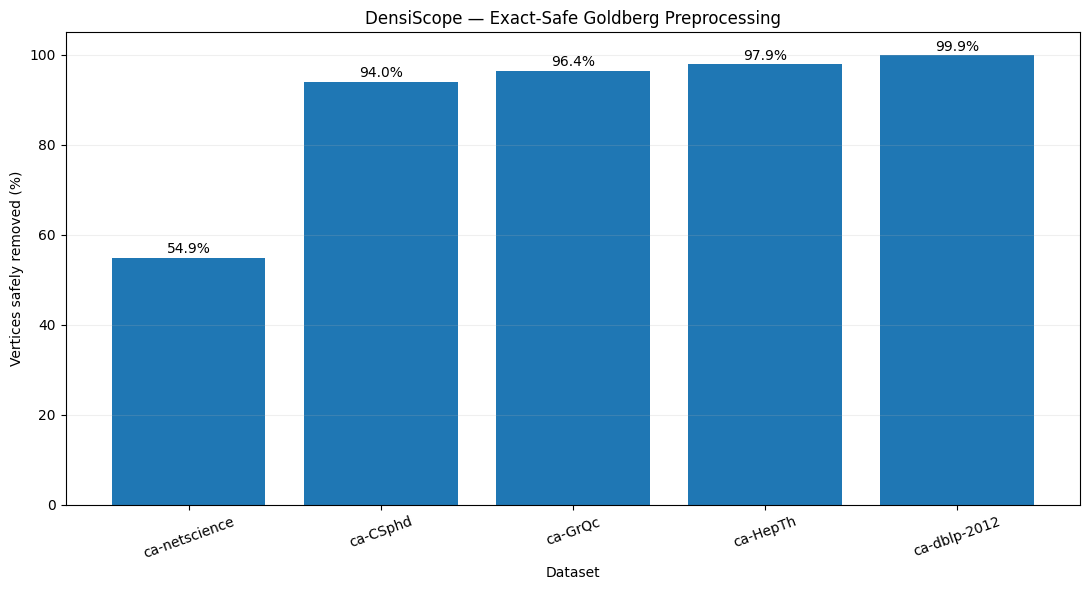

✅ Figure saved:
/content/drive/MyDrive/DensiScope/figures/goldberg_safe_reduction.png


In [89]:
plt.figure(
    figsize=(11, 6)
)

x = np.arange(
    len(goldberg_df)
)

plt.bar(
    x,
    goldberg_df[
        "node_reduction_pct"
    ]
)

plt.xticks(
    x,
    goldberg_df["dataset"],
    rotation=20
)

plt.ylabel(
    "Vertices safely removed (%)"
)

plt.xlabel(
    "Dataset"
)

plt.title(
    "DensiScope — Exact-Safe Goldberg Preprocessing"
)

plt.ylim(
    0,
    105
)

plt.grid(
    axis="y",
    alpha=0.20
)

for i, value in enumerate(
    goldberg_df[
        "node_reduction_pct"
    ]
):

    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

goldberg_reduction_figure = os.path.join(
    PROJECT_ROOT,
    "figures",
    "goldberg_safe_reduction.png"
)

plt.savefig(
    goldberg_reduction_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Figure saved:"
)

print(
    goldberg_reduction_figure
)

In [90]:
reduction_display = (
    goldberg_df[
        [
            "dataset",
            "original_nodes",
            "core_nodes",
            "original_edges",
            "core_edges",
            "node_reduction_pct",
            "edge_reduction_pct"
        ]
    ]
    .copy()
)

reduction_display.columns = [
    "Dataset",
    "Original Nodes",
    "Reduced Nodes",
    "Original Edges",
    "Reduced Edges",
    "Node Reduction %",
    "Edge Reduction %"
]

display(
    reduction_display
)

,Dataset,Original Nodes,Reduced Nodes,Original Edges,Reduced Edges,Node Reduction %,Edge Reduction %
0,ca-netscience,379,171,914,512,54.881266,43.982495
1,ca-CSphd,1882,113,1740,133,93.995749,92.356322
2,ca-GrQc,4158,148,13422,2707,96.440596,79.831620
3,ca-HepTh,11204,239,117619,28441,97.866833,75.819383
4,ca-dblp-2012,317080,280,1049866,13609,99.911694,98.703739


# 11. Scalable Exact Triangle-Density Pipeline

Large triangle-density instances require special care because a direct auxiliary flow graph may contain one node per triangle.

DensiScope therefore adds:
- compiled triangle counting without initially storing all triangles,
- compact triangle enumeration after reduction,
- exact-safe triangle-core peeling,
- triangle-greedy feasible lower bounds,
- triangle-component decomposition,
- complete-core and upper-bound optimality certificates.

These techniques allow some of the largest instances to be certified exactly without constructing the full max-flow network.


In [91]:
from numba import njit


@njit
def triangle_incidence_count_csr(
    indptr,
    indices,
    active
):
    """
    Count triangles in a CSR graph WITHOUT storing them.

    Returns:
        triangle_degree[v]
        total number of triangles

    Each triangle is counted exactly once using:
        u < v < w
    """

    n = len(indptr) - 1

    triangle_degree = np.zeros(
        n,
        dtype=np.int64
    )

    total_triangles = 0

    for u in range(n):

        if not active[u]:
            continue

        start_u = indptr[u]
        end_u = indptr[u + 1]

        # Consider u < v
        for pos_uv in range(
            start_u,
            end_u
        ):

            v = indices[pos_uv]

            if v <= u:
                continue

            if not active[v]:
                continue

            # ----------------------------------
            # Intersect N(u) and N(v)
            # but only look for w > v
            # ----------------------------------

            i = pos_uv + 1

            start_v = indptr[v]
            end_v = indptr[v + 1]

            j = start_v

            while (
                j < end_v
                and indices[j] <= v
            ):
                j += 1

            while (
                i < end_u
                and j < end_v
            ):

                a = indices[i]
                b = indices[j]

                if a == b:

                    w = a

                    if (
                        w > v
                        and active[w]
                    ):

                        triangle_degree[u] += 1
                        triangle_degree[v] += 1
                        triangle_degree[w] += 1

                        total_triangles += 1

                    i += 1
                    j += 1

                elif a < b:

                    i += 1

                else:

                    j += 1

    return (
        triangle_degree,
        total_triangles
    )


# ----------------------------------------------
# Compile / warm up on our tiny test graph
# ----------------------------------------------

warm_active = np.ones(
    A_test.shape[0],
    dtype=np.bool_
)

warm_counts, warm_triangles = (
    triangle_incidence_count_csr(
        A_test.indptr,
        A_test.indices,
        warm_active
    )
)

print(
    "✅ Memory-efficient triangle counter compiled."
)

print(
    "Tiny graph triangles:",
    warm_triangles
)

✅ Memory-efficient triangle counter compiled.
Tiny graph triangles: 4


In [92]:
@njit
def enumerate_triangles_csr(
    indptr,
    indices
):
    """
    Enumerate triangles into one compact int32 NumPy array.

    Shape:
        (number_of_triangles, 3)

    Uses two passes:
        1. count
        2. allocate exact-sized array + fill
    """

    n = len(indptr) - 1

    active = np.ones(
        n,
        dtype=np.bool_
    )

    _, total = (
        triangle_incidence_count_csr(
            indptr,
            indices,
            active
        )
    )

    triangles = np.empty(
        (total, 3),
        dtype=np.int32
    )

    triangle_index = 0

    for u in range(n):

        start_u = indptr[u]
        end_u = indptr[u + 1]

        for pos_uv in range(
            start_u,
            end_u
        ):

            v = indices[pos_uv]

            if v <= u:
                continue

            i = pos_uv + 1

            start_v = indptr[v]
            end_v = indptr[v + 1]

            j = start_v

            while (
                j < end_v
                and indices[j] <= v
            ):
                j += 1

            while (
                i < end_u
                and j < end_v
            ):

                a = indices[i]
                b = indices[j]

                if a == b:

                    w = a

                    if w > v:

                        triangles[
                            triangle_index,
                            0
                        ] = u

                        triangles[
                            triangle_index,
                            1
                        ] = v

                        triangles[
                            triangle_index,
                            2
                        ] = w

                        triangle_index += 1

                    i += 1
                    j += 1

                elif a < b:

                    i += 1

                else:

                    j += 1

    return triangles


# Test against ca-netscience's known 921 triangles

compact_test_triangles = (
    enumerate_triangles_csr(
        A_netscience.indptr,
        A_netscience.indices
    )
)

print(
    "Compact triangles:",
    len(compact_test_triangles)
)

assert (
    len(compact_test_triangles)
    == 921
)

print(
    "✅ Compact triangle enumeration verified."
)

Compact triangles: 921
✅ Compact triangle enumeration verified.


In [93]:
def safe_triangle_core(
    A,
    triangle_density_lower_bound,
    verbose=False
):
    """
    Exact-safe reduction for Triangle Densest Subgraph.

    Uses iterative triangle-core peeling.

    IMPORTANT:
    Triangles are counted but NOT stored during reduction.
    """

    A = A.tocsr()

    n = A.shape[0]

    if n == 0:

        return (
            A.copy(),
            np.array([], dtype=np.int32),
            0,
            0,
            0
        )

    k = int(
        np.ceil(
            triangle_density_lower_bound
            - 1e-12
        )
    )

    active = np.ones(
        n,
        dtype=np.bool_
    )

    passes = 0

    # ==========================================
    # Iterative triangle peeling
    # ==========================================

    if k > 0:

        while True:

            passes += 1

            triangle_degree, total_t = (
                triangle_incidence_count_csr(
                    A.indptr,
                    A.indices,
                    active
                )
            )

            remove = (
                active
                &
                (triangle_degree < k)
            )

            remove_count = int(
                np.count_nonzero(remove)
            )

            if verbose:

                print(
                    f"Pass {passes}: "
                    f"active={np.count_nonzero(active):,}, "
                    f"triangles={total_t:,}, "
                    f"remove={remove_count:,}"
                )

            if remove_count == 0:
                break

            active[remove] = False

    # ==========================================
    # Build final compact core
    # ==========================================

    mapping = np.flatnonzero(
        active
    ).astype(np.int32)

    A_core = A[
        mapping
    ][:, mapping].tocsr()

    final_active = np.ones(
        A_core.shape[0],
        dtype=np.bool_
    )

    _, final_triangles = (
        triangle_incidence_count_csr(
            A_core.indptr,
            A_core.indices,
            final_active
        )
    )

    return (
        A_core,
        mapping,
        k,
        int(final_triangles),
        int(passes)
    )


print(
    "✅ Exact-safe triangle-core reduction ready."
)

✅ Exact-safe triangle-core reduction ready.


In [94]:
def triangle_lower_bound_from_solution(
    A,
    vertices
):
    """
    Compute triangle density of an existing solution
    without storing its triangles.
    """

    vertices = np.asarray(
        vertices,
        dtype=np.int32
    )

    if len(vertices) == 0:
        return 0, 0.0

    A_sub = A[
        vertices
    ][:, vertices].tocsr()

    active = np.ones(
        A_sub.shape[0],
        dtype=np.bool_
    )

    _, triangle_count = (
        triangle_incidence_count_csr(
            A_sub.indptr,
            A_sub.indices,
            active
        )
    )

    density = (
        triangle_count
        / len(vertices)
    )

    return (
        int(triangle_count),
        float(density)
    )


print(
    "✅ Triangle lower-bound helper ready."
)

✅ Triangle lower-bound helper ready.


In [95]:
def max_possible_triangles(n):
    """
    Number of triangles in a complete graph K_n.
    """
    if n < 3:
        return 0

    return (
        n * (n - 1) * (n - 2)
    ) // 6


print(
    "✅ Complete-graph triangle bound helper ready."
)


✅ Complete-graph triangle bound helper ready.


In [96]:
@njit
def triangle_greedy_peeling(
    num_vertices,
    triangles
):
    """
    Greedy triangle peeling used ONLY to obtain
    a strong feasible lower bound.

    It repeatedly removes the vertex participating
    in the fewest currently active triangles.

    This is NOT our exact algorithm.
    """

    n = num_vertices
    t_count = len(triangles)

    # =========================================
    # Initial triangle degree
    # =========================================

    triangle_degree = np.zeros(
        n,
        dtype=np.int64
    )

    for tid in range(t_count):

        a = triangles[tid, 0]
        b = triangles[tid, 1]
        c = triangles[tid, 2]

        triangle_degree[a] += 1
        triangle_degree[b] += 1
        triangle_degree[c] += 1

    # =========================================
    # Build vertex -> incident triangle CSR
    # =========================================

    incidence_indptr = np.zeros(
        n + 1,
        dtype=np.int64
    )

    for v in range(n):

        incidence_indptr[v + 1] = (
            incidence_indptr[v]
            + triangle_degree[v]
        )

    incidence_ids = np.empty(
        3 * t_count,
        dtype=np.int32
    )

    cursor = incidence_indptr[
        :-1
    ].copy()

    for tid in range(t_count):

        for j in range(3):

            v = triangles[tid, j]

            p = cursor[v]

            incidence_ids[p] = tid

            cursor[v] += 1

    # =========================================
    # Peeling state
    # =========================================

    active_vertex = np.ones(
        n,
        dtype=np.bool_
    )

    active_triangle = np.ones(
        t_count,
        dtype=np.bool_
    )

    current_nodes = n
    current_triangles = t_count

    removal_order = np.empty(
        n,
        dtype=np.int32
    )

    removed_count = 0

    if n > 0:
        best_density = (
            current_triangles
            / current_nodes
        )
    else:
        best_density = 0.0

    best_nodes = current_nodes
    best_triangles = current_triangles
    best_removed_count = 0

    # =========================================
    # Peel vertices
    # =========================================

    while current_nodes > 0:

        density = (
            current_triangles
            / current_nodes
        )

        if density > best_density:

            best_density = density
            best_nodes = current_nodes
            best_triangles = current_triangles
            best_removed_count = removed_count

        # -------------------------------------
        # Find active minimum triangle-degree
        # vertex.
        #
        # n after our safe reduction is tiny,
        # so an O(n) scan is memory-efficient.
        # -------------------------------------

        min_vertex = -1
        min_degree = np.int64(
            9223372036854775807
        )

        for v in range(n):

            if active_vertex[v]:

                d = triangle_degree[v]

                if (
                    d < min_degree
                    or (
                        d == min_degree
                        and v < min_vertex
                    )
                ):

                    min_degree = d
                    min_vertex = v

        if min_vertex < 0:
            break

        v = min_vertex

        active_vertex[v] = False

        removal_order[
            removed_count
        ] = v

        removed_count += 1

        # -------------------------------------
        # Destroy every still-active triangle
        # touching v
        # -------------------------------------

        start = incidence_indptr[v]
        end = incidence_indptr[v + 1]

        for p in range(start, end):

            tid = incidence_ids[p]

            if not active_triangle[tid]:
                continue

            active_triangle[tid] = False

            current_triangles -= 1

            a = triangles[tid, 0]
            b = triangles[tid, 1]
            c = triangles[tid, 2]

            if active_vertex[a]:
                triangle_degree[a] -= 1

            if active_vertex[b]:
                triangle_degree[b] -= 1

            if active_vertex[c]:
                triangle_degree[c] -= 1

        current_nodes -= 1

    # =========================================
    # Reconstruct best subset
    # =========================================

    best_active = np.ones(
        n,
        dtype=np.bool_
    )

    for i in range(
        best_removed_count
    ):

        best_active[
            removal_order[i]
        ] = False

    best_vertices = np.empty(
        best_nodes,
        dtype=np.int32
    )

    index = 0

    for v in range(n):

        if best_active[v]:

            best_vertices[
                index
            ] = v

            index += 1

    return (
        best_vertices,
        best_density,
        best_triangles,
        best_nodes,
        best_removed_count
    )


print(
    "✅ Triangle-greedy lower-bound algorithm defined."
)

✅ Triangle-greedy lower-bound algorithm defined.


In [97]:
(
    triangle_greedy_vertices_test,
    triangle_greedy_density_test,
    triangle_greedy_count_test,
    triangle_greedy_nodes_test,
    triangle_greedy_removed_test
) = triangle_greedy_peeling(
    A_netscience.shape[0],
    compact_test_triangles
)

print("=" * 52)
print(" TRIANGLE-GREEDY VALIDATION")
print("=" * 52)

print(
    "Result nodes:",
    triangle_greedy_nodes_test
)

print(
    "Result triangles:",
    triangle_greedy_count_test
)

print(
    "Triangle density:",
    triangle_greedy_density_test
)

print(
    "Known exact density:",
    triangle_exact_netscience[
        "triangle_density"
    ]
)

assert (
    triangle_greedy_density_test
    <=
    triangle_exact_netscience[
        "triangle_density"
    ] + 1e-9
)

print()
print(
    "✅ Triangle-greedy lower bound verified."
)

 TRIANGLE-GREEDY VALIDATION
Result nodes: 9
Result triangles: 84
Triangle density: 9.333333333333334
Known exact density: 9.333333333333334

✅ Triangle-greedy lower bound verified.


In [98]:
@njit
def uf_find(parent, x):

    while parent[x] != x:

        parent[x] = parent[
            parent[x]
        ]

        x = parent[x]

    return x


@njit
def triangle_support_roots(
    num_vertices,
    triangles
):
    """
    Find connected components of the
    triangle-support hypergraph.

    Two vertices are connected when they
    participate together in a triangle.
    """

    parent = np.arange(
        num_vertices,
        dtype=np.int32
    )

    size = np.ones(
        num_vertices,
        dtype=np.int32
    )

    for i in range(
        len(triangles)
    ):

        a = int(
            triangles[i, 0]
        )

        b = int(
            triangles[i, 1]
        )

        c = int(
            triangles[i, 2]
        )

        # ------------------------------
        # Union a and b
        # ------------------------------

        ra = uf_find(
            parent,
            a
        )

        rb = uf_find(
            parent,
            b
        )

        if ra != rb:

            if size[ra] < size[rb]:

                temp = ra
                ra = rb
                rb = temp

            parent[rb] = ra
            size[ra] += size[rb]

        # ------------------------------
        # Union a and c
        # ------------------------------

        ra = uf_find(
            parent,
            a
        )

        rc = uf_find(
            parent,
            c
        )

        if ra != rc:

            if size[ra] < size[rc]:

                temp = ra
                ra = rc
                rc = temp

            parent[rc] = ra
            size[ra] += size[rc]

    roots = np.empty(
        num_vertices,
        dtype=np.int32
    )

    for v in range(
        num_vertices
    ):

        roots[v] = uf_find(
            parent,
            v
        )

    return roots


print(
    "✅ Triangle-component decomposition ready."
)

✅ Triangle-component decomposition ready.


In [99]:
def triangle_component_analysis(
    num_vertices,
    triangles
):
    """
    Analyze triangle-connected components and
    compute exact-safe upper bounds for each one.
    """

    roots = triangle_support_roots(
        num_vertices,
        triangles
    )

    unique_roots, labels = np.unique(
        roots,
        return_inverse=True
    )

    num_components = len(
        unique_roots
    )

    # ==========================================
    # Component vertex counts
    # ==========================================

    component_sizes = np.bincount(
        labels,
        minlength=num_components
    ).astype(np.int64)

    # ==========================================
    # Component triangle counts
    # ==========================================

    triangle_component = labels[
        triangles[:, 0]
    ]

    # Verify every triangle stays in one component
    assert np.all(
        labels[triangles[:, 1]]
        == triangle_component
    )

    assert np.all(
        labels[triangles[:, 2]]
        == triangle_component
    )

    component_triangles = np.bincount(
        triangle_component,
        minlength=num_components
    ).astype(np.int64)

    # ==========================================
    # Triangle incidence per vertex
    # ==========================================

    incidence = np.bincount(
        triangles.reshape(-1),
        minlength=num_vertices
    ).astype(np.int64)

    # Maximum incidence inside each component
    component_max_incidence = np.zeros(
        num_components,
        dtype=np.int64
    )

    np.maximum.at(
        component_max_incidence,
        labels,
        incidence
    )

    # ==========================================
    # Exact-safe upper bound:
    #
    # 3 * triangle_density
    # = average triangle participation
    #
    # average <= max participation
    #
    # therefore:
    # tau <= max_incidence / 3
    # ==========================================

    upper_bounds = (
        component_max_incidence
        / 3.0
    )

    full_component_density = (
        component_triangles
        / component_sizes
    )

    max_possible = np.array(
        [
            max_possible_triangles(
                int(n)
            )
            for n in component_sizes
        ],
        dtype=np.int64
    )

    complete = (
        component_triangles
        == max_possible
    )

    rows = []

    for cid in range(
        num_components
    ):

        # Ignore components containing no triangle
        if component_triangles[cid] == 0:
            continue

        rows.append({
            "component":
                int(cid),

            "vertices":
                int(
                    component_sizes[cid]
                ),

            "triangles":
                int(
                    component_triangles[cid]
                ),

            "full_density":
                float(
                    full_component_density[
                        cid
                    ]
                ),

            "max_triangle_incidence":
                int(
                    component_max_incidence[
                        cid
                    ]
                ),

            "density_upper_bound":
                float(
                    upper_bounds[cid]
                ),

            "complete":
                bool(
                    complete[cid]
                )
        })

    df = pd.DataFrame(
        rows
    )

    if not df.empty:

        df = df.sort_values(
            "density_upper_bound",
            ascending=False
        ).reset_index(
            drop=True
        )

    return (
        df,
        labels
    )

print(
    "✅ Triangle-component analysis helper ready."
)


✅ Triangle-component analysis helper ready.


## Final Triangle Refinement and Exact Benchmark

The final refinement tracks an explicit feasible witness so a certified optimum can be saved in original graph vertex IDs.

Three exact solution modes are supported:
1. **complete-core certificate**,
2. **provable upper-bound certificate**,
3. **max-flow binary search** only when a certificate is not sufficient.


In [100]:
def refine_triangle_core_with_witness(
    A,
    initial_vertices,
    max_rounds=6,
    verbose=False
):
    """
    Exact-safe Triangle Density preprocessing.

    Tracks:
      • current safe triangle core
      • strongest feasible lower bound
      • original vertex IDs of the feasible witness

    The triangle-greedy stage is ONLY used to
    improve the lower bound. Exactness comes from
    safe reduction + certificates/max-flow.
    """

    A = A.tocsr()

    global_mapping = np.arange(
        A.shape[0],
        dtype=np.int32
    )

    initial_vertices = np.asarray(
        initial_vertices,
        dtype=np.int32
    )

    # ==========================================
    # Initial feasible solution
    # ==========================================

    (
        initial_t,
        best_density
    ) = triangle_lower_bound_from_solution(
        A,
        initial_vertices
    )

    best_witness_original = (
        initial_vertices.copy()
    )

    best_triangle_count = int(
        initial_t
    )

    current_A = A

    history = []

    # ==========================================
    # Refinement
    # ==========================================

    for round_index in range(
        1,
        max_rounds + 1
    ):

        before_nodes = int(
            current_A.shape[0]
        )

        previous_density = float(
            best_density
        )

        # --------------------------------------
        # Exact-safe triangle core
        # --------------------------------------

        (
            reduced_A,
            local_mapping,
            k,
            reduced_t,
            passes
        ) = safe_triangle_core(
            current_A,
            best_density,
            verbose=False
        )

        global_mapping = (
            global_mapping[
                local_mapping
            ]
        )

        current_A = reduced_A

        current_n = int(
            current_A.shape[0]
        )

        current_m = int(
            current_A.nnz // 2
        )

        if current_n == 0:
            break

        # --------------------------------------
        # Compact triangle enumeration
        # --------------------------------------

        triangles = (
            enumerate_triangles_csr(
                current_A.indptr,
                current_A.indices
            )
        )

        # --------------------------------------
        # Strong feasible lower bound
        # --------------------------------------

        (
            greedy_vertices,
            greedy_density,
            greedy_t,
            greedy_n,
            _
        ) = triangle_greedy_peeling(
            current_n,
            triangles
        )

        improved = (
            greedy_density
            > best_density + 1e-12
        )

        if improved:

            best_density = float(
                greedy_density
            )

            best_triangle_count = int(
                greedy_t
            )

            best_witness_original = (
                global_mapping[
                    greedy_vertices
                ].copy()
            )

        history.append({
            "round":
                round_index,

            "nodes":
                current_n,

            "edges":
                current_m,

            "triangles":
                int(len(triangles)),

            "safe_k":
                int(k),

            "lower_before":
                previous_density,

            "greedy_density":
                float(greedy_density),

            "lower_after":
                float(best_density)
        })

        if verbose:

            print(
                f"Round {round_index}: "
                f"{before_nodes:,} → "
                f"{current_n:,} vertices | "
                f"{len(triangles):,} triangles | "
                f"LB={best_density:.6f}"
            )

        no_size_change = (
            current_n == before_nodes
        )

        no_improvement = (
            best_density
            <= previous_density + 1e-12
        )

        if (
            no_size_change
            and no_improvement
        ):
            break

        del triangles
        gc.collect()

    # ==========================================
    # Final triangle list
    # ==========================================

    final_triangles = (
        enumerate_triangles_csr(
            current_A.indptr,
            current_A.indices
        )
    )

    return {
        "A_core":
            current_A,

        "mapping":
            global_mapping,

        "triangles":
            final_triangles,

        "lower_bound":
            float(best_density),

        "witness_original":
            best_witness_original,

        "witness_triangles":
            int(best_triangle_count),

        "history":
            history
    }


print(
    "✅ Triangle refinement with witness ready."
)

✅ Triangle refinement with witness ready.


In [101]:
def benchmark_triangle_exact(
    dataset_name,
    processed_path,
    charikar_solution_path
):
    """
    Exact Triangle-Density benchmark.

    Possible exact solution modes:
      1. complete-core certificate
      2. component upper-bound certificate
      3. exact max-flow / binary search
    """

    print()
    print("=" * 72)
    print(
        f" EXACT TRIANGLE BENCHMARK — "
        f"{dataset_name}"
    )
    print("=" * 72)

    gc.collect()

    total_start = (
        time.perf_counter()
    )

    with PeakRSSMonitor() as mem:

        # ======================================
        # LOAD GRAPH
        # ======================================

        A = sp.load_npz(
            processed_path
        ).tocsr()

        original_n = int(
            A.shape[0]
        )

        original_m = int(
            A.nnz // 2
        )

        charikar_vertices = np.load(
            charikar_solution_path
        ).astype(np.int32)

        # ======================================
        # EXACT-SAFE REFINEMENT
        # ======================================

        refinement_start = (
            time.perf_counter()
        )

        refined = (
            refine_triangle_core_with_witness(
                A,
                charikar_vertices,
                max_rounds=6,
                verbose=False
            )
        )

        refinement_runtime = (
            time.perf_counter()
            - refinement_start
        )

        A_core = refined[
            "A_core"
        ]

        mapping = refined[
            "mapping"
        ]

        triangles = refined[
            "triangles"
        ]

        best_density = float(
            refined[
                "lower_bound"
            ]
        )

        best_vertices_original = (
            refined[
                "witness_original"
            ].copy()
        )

        core_n = int(
            A_core.shape[0]
        )

        core_m = int(
            A_core.nnz // 2
        )

        core_t = int(
            len(triangles)
        )

        flow_calls = 0
        solver_runtime = 0.0

        solver_mode = None

        # ======================================
        # CERTIFICATE 1:
        # COMPLETE TRIANGLE CORE
        # ======================================

        complete_core = (
            core_t
            ==
            max_possible_triangles(
                core_n
            )
        )

        if complete_core:

            exact_vertices_original = (
                mapping.copy()
            )

            exact_triangles = int(
                core_t
            )

            exact_density = (
                exact_triangles
                / core_n
                if core_n > 0
                else 0.0
            )

            solver_mode = (
                "complete_core_certificate"
            )

            print(
                "🎯 Complete-core certificate."
            )

        else:

            # ==================================
            # TRIANGLE COMPONENTS
            # ==================================

            (
                component_df,
                component_labels
            ) = triangle_component_analysis(
                core_n,
                triangles
            )

            if component_df.empty:

                exact_vertices_original = (
                    best_vertices_original
                )

                exact_triangles = 0
                exact_density = 0.0

                solver_mode = (
                    "no_triangles"
                )

            else:

                global_upper = float(
                    component_df[
                        "density_upper_bound"
                    ].max()
                )

                # ==============================
                # CERTIFICATE 2:
                # LB == PROVABLE UB
                # ==============================

                if (
                    global_upper
                    <= best_density
                    + 1e-12
                ):

                    exact_vertices_original = (
                        best_vertices_original
                    )

                    exact_triangles = int(
                        refined[
                            "witness_triangles"
                        ]
                    )

                    exact_density = float(
                        best_density
                    )

                    solver_mode = (
                        "upper_bound_certificate"
                    )

                    print(
                        "🎯 Upper-bound certificate."
                    )

                else:

                    # ==========================
                    # EXACT MAX-FLOW MODE
                    # ==========================

                    solver_mode = (
                        "maxflow_binary_search"
                    )

                    print(
                        "Running exact component "
                        "max-flow search..."
                    )

                    solver_start = (
                        time.perf_counter()
                    )

                    # Current global feasible result
                    exact_vertices_original = (
                        best_vertices_original.copy()
                    )

                    exact_density = float(
                        best_density
                    )

                    exact_triangles = int(
                        refined[
                            "witness_triangles"
                        ]
                    )

                    # Components sorted by
                    # descending safe upper bound
                    for _, comp_row in (
                        component_df.iterrows()
                    ):

                        component_upper = float(
                            comp_row[
                                "density_upper_bound"
                            ]
                        )

                        # Cannot improve current best
                        if (
                            component_upper
                            <= exact_density
                            + 1e-12
                        ):
                            continue

                        cid = int(
                            comp_row[
                                "component"
                            ]
                        )

                        comp_vertices = (
                            np.flatnonzero(
                                component_labels
                                == cid
                            ).astype(np.int32)
                        )

                        # ----------------------
                        # Local vertex map
                        # ----------------------

                        local_map = np.full(
                            core_n,
                            -1,
                            dtype=np.int32
                        )

                        local_map[
                            comp_vertices
                        ] = np.arange(
                            len(comp_vertices),
                            dtype=np.int32
                        )

                        # ----------------------
                        # Triangles belonging
                        # to this component
                        # ----------------------

                        tri_mask = (
                            component_labels[
                                triangles[:, 0]
                            ]
                            == cid
                        )

                        comp_triangles_core = (
                            triangles[
                                tri_mask
                            ]
                        )

                        comp_triangles = (
                            local_map[
                                comp_triangles_core
                            ]
                        ).astype(
                            np.int32,
                            copy=False
                        )

                        comp_n = int(
                            len(comp_vertices)
                        )

                        # ----------------------
                        # Triangle incidence
                        # ----------------------

                        comp_incidence = (
                            np.bincount(
                                comp_triangles.reshape(
                                    -1
                                ),
                                minlength=comp_n
                            ).astype(np.int32)
                        )

                        # ----------------------
                        # Strong local seed
                        # ----------------------

                        (
                            seed_vertices,
                            seed_density,
                            seed_t,
                            seed_n,
                            _
                        ) = triangle_greedy_peeling(
                            comp_n,
                            comp_triangles
                        )

                        # ----------------------
                        # Exact flow solver
                        # ----------------------

                        exact_component = (
                            exact_triangle_densest_subgraph(
                                comp_n,
                                comp_triangles,
                                comp_incidence,
                                initial_vertices=
                                    seed_vertices,
                                record_history=False
                            )
                        )

                        flow_calls += int(
                            exact_component[
                                "flow_calls"
                            ]
                        )

                        candidate_density = float(
                            exact_component[
                                "triangle_density"
                            ]
                        )

                        if (
                            candidate_density
                            > exact_density
                            + 1e-12
                        ):

                            component_core_ids = (
                                comp_vertices[
                                    exact_component[
                                        "vertices"
                                    ]
                                ]
                            )

                            exact_vertices_original = (
                                mapping[
                                    component_core_ids
                                ].copy()
                            )

                            exact_density = (
                                candidate_density
                            )

                            exact_triangles = int(
                                exact_component[
                                    "triangle_count"
                                ]
                            )

                    solver_runtime = (
                        time.perf_counter()
                        - solver_start
                    )

        # ======================================
        # VERIFY EXACT SOLUTION
        # ======================================

        (
            verified_triangles,
            verified_density
        ) = triangle_lower_bound_from_solution(
            A,
            exact_vertices_original
        )

        assert (
            verified_triangles
            == exact_triangles
        )

        assert np.isclose(
            verified_density,
            exact_density
        )

        # ======================================
        # EDGE METRICS TOO
        # ======================================

        A_result = A[
            exact_vertices_original
        ][:, exact_vertices_original]

        result_nodes = int(
            len(
                exact_vertices_original
            )
        )

        result_edges = int(
            A_result.nnz // 2
        )

        result_edge_density = (
            result_edges
            / result_nodes
            if result_nodes > 0
            else 0.0
        )

    total_runtime = (
        time.perf_counter()
        - total_start
    )

    # ==========================================
    # SAVE EXACT SOLUTION
    # ==========================================

    solution_path = os.path.join(
        SOLUTIONS_DIR,
        f"{dataset_name}_triangle_exact.npy"
    )

    np.save(
        solution_path,
        exact_vertices_original.astype(
            np.int32
        )
    )

    # ==========================================
    # DISPLAY
    # ==========================================

    print()
    print(
        f"Mode:                  "
        f"{solver_mode}"
    )

    print(
        f"Original graph:        "
        f"{original_n:,} nodes | "
        f"{original_m:,} edges"
    )

    print(
        f"Reduced triangle core: "
        f"{core_n:,} nodes | "
        f"{core_t:,} triangles"
    )

    print(
        f"Exact result nodes:    "
        f"{result_nodes:,}"
    )

    print(
        f"Exact result edges:    "
        f"{result_edges:,}"
    )

    print(
        f"Exact triangles:       "
        f"{exact_triangles:,}"
    )

    print(
        f"Triangle density:      "
        f"{exact_density:.8f}"
    )

    print(
        f"Edge density:          "
        f"{result_edge_density:.8f}"
    )

    print(
        f"Max-flow calls:        "
        f"{flow_calls}"
    )

    print(
        f"Refinement runtime:    "
        f"{refinement_runtime:.4f} s"
    )

    print(
        f"Flow runtime:          "
        f"{solver_runtime:.4f} s"
    )

    print(
        f"Total runtime:         "
        f"{total_runtime:.4f} s"
    )

    print(
        f"Extra peak RAM:        "
        f"{mem.extra_mb:.2f} MB"
    )

    print("=" * 72)

    row = {
        "dataset":
            dataset_name,

        "algorithm":
            "Exact Triangle Density",

        "objective":
            "triangle_density",

        "solver_mode":
            solver_mode,

        "original_nodes":
            original_n,

        "original_edges":
            original_m,

        "triangle_core_nodes":
            core_n,

        "triangle_core_edges":
            core_m,

        "triangle_core_triangles":
            core_t,

        "result_nodes":
            result_nodes,

        "result_edges":
            result_edges,

        "result_triangles":
            int(exact_triangles),

        "edge_density":
            float(
                result_edge_density
            ),

        "triangle_density":
            float(
                exact_density
            ),

        "flow_calls":
            int(flow_calls),

        "refinement_runtime_s":
            float(
                refinement_runtime
            ),

        "solver_runtime_s":
            float(
                solver_runtime
            ),

        "total_runtime_s":
            float(
                total_runtime
            ),

        "peak_rss_mb":
            float(
                mem.peak_mb
            ),

        "extra_rss_mb":
            float(
                mem.extra_mb
            ),

        "status":
            "completed"
    }

    # ==========================================
    # CLEANUP
    # ==========================================

    del A
    del A_core
    del triangles
    del A_result

    gc.collect()

    return row


print(
    "✅ Final Exact Triangle benchmark ready."
)

✅ Final Exact Triangle benchmark ready.


In [102]:
triangle_exact_rows = []

triangle_exact_results_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "triangle_exact_benchmarks.csv"
)


for dataset_name in benchmark_order:

    charikar_solution_path = os.path.join(
        SOLUTIONS_DIR,
        f"{dataset_name}_charikar.npy"
    )

    row = benchmark_triangle_exact(
        dataset_name,
        processed_graph_paths[
            dataset_name
        ],
        charikar_solution_path
    )

    triangle_exact_rows.append(
        row
    )

    # ==========================================
    # SAVE PROGRESS AFTER EVERY DATASET
    # ==========================================

    triangle_exact_df = pd.DataFrame(
        triangle_exact_rows
    )

    triangle_exact_df.to_csv(
        triangle_exact_results_path,
        index=False
    )

    print()
    print(
        "💾 Triangle Exact progress saved."
    )

    show_memory(
        f"After Triangle Exact "
        f"{dataset_name}"
    )


print()
print("=" * 75)
print(
    " ALL EXACT TRIANGLE RUNS COMPLETE"
)
print("=" * 75)

display(
    triangle_exact_df[
        [
            "dataset",
            "solver_mode",
            "original_nodes",
            "original_edges",
            "triangle_core_nodes",
            "triangle_core_triangles",
            "result_nodes",
            "result_edges",
            "result_triangles",
            "triangle_density",
            "flow_calls",
            "total_runtime_s"
        ]
    ]
)


 EXACT TRIANGLE BENCHMARK — ca-netscience
Running exact component max-flow search...

Mode:                  maxflow_binary_search
Original graph:        379 nodes | 914 edges
Reduced triangle core: 68 nodes | 398 triangles
Exact result nodes:    9
Exact result edges:    36
Exact triangles:       84
Triangle density:      9.33333333
Edge density:          4.00000000
Max-flow calls:        20
Refinement runtime:    0.1689 s
Flow runtime:          0.0081 s
Total runtime:         0.8645 s
Extra peak RAM:        0.44 MB

💾 Triangle Exact progress saved.
🧠 After Triangle Exact ca-netscience memory status
   Python process: 0.510 GB
   Total system RAM: 12.67 GB
   Available RAM: 11.02 GB

 EXACT TRIANGLE BENCHMARK — ca-CSphd
Running exact component max-flow search...

Mode:                  maxflow_binary_search
Original graph:        1,882 nodes | 1,740 edges
Reduced triangle core: 15 nodes | 8 triangles
Exact result nodes:    6
Exact result edges:    9
Exact triangles:       4
Triangle d

,dataset,solver_mode,original_nodes,original_edges,triangle_core_nodes,triangle_core_triangles,result_nodes,result_edges,result_triangles,triangle_density,flow_calls,total_runtime_s
0,ca-netscience,maxflow_binary_search,379,914,68,398,9,36,84,9.333333,20,0.864492
1,ca-CSphd,maxflow_binary_search,1882,1740,15,8,6,9,4,0.666667,9,0.189804
2,ca-GrQc,maxflow_binary_search,4158,13422,123,30431,46,1030,14966,325.347826,13,1.343814
3,ca-HepTh,complete_core_certificate,11204,117619,239,2246839,239,28441,2246839,9401.000000,0,1.079283
4,ca-dblp-2012,upper_bound_certificate,317080,1049866,216,412164,114,6441,240464,2109.333333,0,0.758597


In [103]:
certificate_df = (
    triangle_exact_df[
        triangle_exact_df[
            "solver_mode"
        ].isin([
            "complete_core_certificate",
            "upper_bound_certificate"
        ])
    ][
        [
            "dataset",
            "solver_mode",
            "original_nodes",
            "triangle_core_nodes",
            "result_nodes",
            "result_triangles",
            "triangle_density",
            "flow_calls",
            "total_runtime_s"
        ]
    ]
    .copy()
)

print(
    "Exact Triangle Solutions "
    "Certified Without Max-Flow"
)

display(
    certificate_df
)

Exact Triangle Solutions Certified Without Max-Flow


,dataset,solver_mode,original_nodes,triangle_core_nodes,result_nodes,result_triangles,triangle_density,flow_calls,total_runtime_s
3,ca-HepTh,complete_core_certificate,11204,239,239,2246839,9401.000000,0,1.079283
4,ca-dblp-2012,upper_bound_certificate,317080,216,114,240464,2109.333333,0,0.758597


In [104]:
final_rows = []

for dataset_name in benchmark_order:

    # ==========================================
    # CHARIKAR
    # ==========================================

    c = fast_df[
        (fast_df["dataset"] == dataset_name)
        &
        (fast_df["algorithm"] == "Charikar")
    ].iloc[0]

    final_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Charikar",

        "Objective":
            "Edge Density",

        "Nodes":
            int(c["result_nodes"]),

        "Edges":
            int(c["result_edges"]),

        "Edge Density":
            float(c["edge_density"]),

        "Triangle Density":
            np.nan,

        "Runtime (s)":
            float(c["wall_runtime_s"])
    })

    # ==========================================
    # GREEDY++
    # ==========================================

    g = fast_df[
        (fast_df["dataset"] == dataset_name)
        &
        (fast_df["algorithm"] == "Greedy++")
    ].iloc[0]

    final_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Greedy++",

        "Objective":
            "Edge Density",

        "Nodes":
            int(g["result_nodes"]),

        "Edges":
            int(g["result_edges"]),

        "Edge Density":
            float(g["edge_density"]),

        "Triangle Density":
            np.nan,

        "Runtime (s)":
            float(g["wall_runtime_s"])
    })

    # ==========================================
    # GOLDBERG
    # ==========================================

    gold = goldberg_df[
        goldberg_df["dataset"]
        == dataset_name
    ].iloc[0]

    final_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Goldberg Exact",

        "Objective":
            "Edge Density",

        "Nodes":
            int(gold["result_nodes"]),

        "Edges":
            int(gold["result_edges"]),

        "Edge Density":
            float(gold["edge_density"]),

        "Triangle Density":
            np.nan,

        "Runtime (s)":
            float(gold["total_runtime_s"])
    })

    # ==========================================
    # TRIANGLE EXACT
    # ==========================================

    tri = triangle_exact_df[
        triangle_exact_df[
            "dataset"
        ] == dataset_name
    ].iloc[0]

    final_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Exact Triangle Density",

        "Objective":
            "Triangle Density",

        "Nodes":
            int(tri["result_nodes"]),

        "Edges":
            int(tri["result_edges"]),

        "Edge Density":
            float(tri["edge_density"]),

        "Triangle Density":
            float(
                tri["triangle_density"]
            ),

        "Runtime (s)":
            float(
                tri["total_runtime_s"]
            )
    })


final_results_df = pd.DataFrame(
    final_rows
)

final_results_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "final_all_algorithms.csv"
)

final_results_df.to_csv(
    final_results_path,
    index=False
)

print(
    "✅ Complete algorithm table saved."
)

display(
    final_results_df
)

✅ Complete algorithm table saved.


,Dataset,Algorithm,Objective,Nodes,Edges,Edge Density,Triangle Density,Runtime (s)
0,ca-netscience,Charikar,Edge Density,9,36,4.000000,NaN,0.024532
1,ca-netscience,Greedy++,Edge Density,9,36,4.000000,NaN,0.151099
2,ca-netscience,Goldberg Exact,Edge Density,9,36,4.000000,NaN,0.022343
3,ca-netscience,Exact Triangle Density,Triangle Density,9,36,4.000000,9.333333,0.864492
4,ca-CSphd,Charikar,Edge Density,4,5,1.250000,NaN,0.030201
5,ca-CSphd,Greedy++,Edge Density,6,9,1.500000,NaN,0.714064
6,ca-CSphd,Goldberg Exact,Edge Density,6,9,1.500000,NaN,0.044085
7,ca-CSphd,Exact Triangle Density,Triangle Density,6,9,1.500000,0.666667,0.189804
8,ca-GrQc,Charikar,Edge Density,46,1030,22.391304,NaN,0.064184
9,ca-GrQc,Greedy++,Edge Density,46,1030,22.391304,NaN,2.967601


# 12. Final Results & Scalability Analysis

All algorithm outputs are combined into a fair benchmark table.

For exact algorithms, the end-to-end runtime includes the prerequisite Charikar lower-bound stage. The following plots analyze:
- runtime growth vs vertices,
- runtime growth vs edges,
- approximation quality,
- measured additional peak RAM,
- exact-safe reduction effectiveness.


In [105]:
algorithm_order = [
    "Charikar",
    "Greedy++",
    "Goldberg Exact",
    "Exact Triangle Density"
]

master_rows = []


for dataset_name in benchmark_order:

    # ==========================================
    # DATASET INFO
    # ==========================================

    meta = full_manifest_df[
        full_manifest_df["dataset"]
        == dataset_name
    ].iloc[0]

    original_nodes = int(
        meta["nodes"]
    )

    original_edges = int(
        meta["edges"]
    )

    # ==========================================
    # CHARIKAR
    # ==========================================

    c = fast_df[
        (fast_df["dataset"] == dataset_name)
        &
        (fast_df["algorithm"] == "Charikar")
    ].iloc[0]

    c_runtime = float(
        c["wall_runtime_s"]
    )

    c_density = float(
        c["edge_density"]
    )

    # ==========================================
    # GREEDY++
    # ==========================================

    g = fast_df[
        (fast_df["dataset"] == dataset_name)
        &
        (fast_df["algorithm"] == "Greedy++")
    ].iloc[0]

    # ==========================================
    # GOLDBERG
    # ==========================================

    gold = goldberg_df[
        goldberg_df["dataset"]
        == dataset_name
    ].iloc[0]

    exact_edge_density = float(
        gold["edge_density"]
    )

    # Goldberg used Charikar's lower bound,
    # so include Charikar for fair end-to-end runtime.
    gold_core_runtime = float(
        gold["total_runtime_s"]
    )

    gold_end_to_end = (
        c_runtime
        + gold_core_runtime
    )

    # ==========================================
    # TRIANGLE EXACT
    # ==========================================

    tri = triangle_exact_df[
        triangle_exact_df["dataset"]
        == dataset_name
    ].iloc[0]

    tri_core_runtime = float(
        tri["total_runtime_s"]
    )

    # Triangle preprocessing also starts
    # from the Charikar solution.
    tri_end_to_end = (
        c_runtime
        + tri_core_runtime
    )

    # ==========================================
    # ROW 1 — CHARIKAR
    # ==========================================

    master_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Charikar",

        "Objective":
            "Edge Density",

        "Original Nodes":
            original_nodes,

        "Original Edges":
            original_edges,

        "Result Nodes":
            int(c["result_nodes"]),

        "Result Edges":
            int(c["result_edges"]),

        "Result Triangles":
            np.nan,

        "Edge Density":
            c_density,

        "Triangle Density":
            np.nan,

        "Quality vs Goldberg (%)":
            (
                c_density
                / exact_edge_density
                * 100
            ),

        "Core Runtime (s)":
            c_runtime,

        "End-to-End Runtime (s)":
            c_runtime,

        "Peak RSS (MB)":
            float(c["peak_rss_mb"]),

        "Extra Peak RAM (MB)":
            float(c["extra_rss_mb"]),

        "Solver Mode":
            "greedy_peeling"
    })

    # ==========================================
    # ROW 2 — GREEDY++
    # ==========================================

    g_density = float(
        g["edge_density"]
    )

    master_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Greedy++",

        "Objective":
            "Edge Density",

        "Original Nodes":
            original_nodes,

        "Original Edges":
            original_edges,

        "Result Nodes":
            int(g["result_nodes"]),

        "Result Edges":
            int(g["result_edges"]),

        "Result Triangles":
            np.nan,

        "Edge Density":
            g_density,

        "Triangle Density":
            np.nan,

        "Quality vs Goldberg (%)":
            (
                g_density
                / exact_edge_density
                * 100
            ),

        "Core Runtime (s)":
            float(g["wall_runtime_s"]),

        "End-to-End Runtime (s)":
            float(g["wall_runtime_s"]),

        "Peak RSS (MB)":
            float(g["peak_rss_mb"]),

        "Extra Peak RAM (MB)":
            float(g["extra_rss_mb"]),

        "Solver Mode":
            "multi_round_greedy"
    })

    # ==========================================
    # ROW 3 — GOLDBERG
    # ==========================================

    master_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Goldberg Exact",

        "Objective":
            "Edge Density",

        "Original Nodes":
            original_nodes,

        "Original Edges":
            original_edges,

        "Result Nodes":
            int(gold["result_nodes"]),

        "Result Edges":
            int(gold["result_edges"]),

        "Result Triangles":
            np.nan,

        "Edge Density":
            exact_edge_density,

        "Triangle Density":
            np.nan,

        "Quality vs Goldberg (%)":
            100.0,

        "Core Runtime (s)":
            gold_core_runtime,

        "End-to-End Runtime (s)":
            gold_end_to_end,

        "Peak RSS (MB)":
            max(
                float(c["peak_rss_mb"]),
                float(gold["peak_rss_mb"])
            ),

        "Extra Peak RAM (MB)":
            max(
                float(c["extra_rss_mb"]),
                float(gold["extra_rss_mb"])
            ),

        "Solver Mode":
            "safe_core + maxflow"
    })

    # ==========================================
    # ROW 4 — TRIANGLE EXACT
    # ==========================================

    master_rows.append({
        "Dataset":
            dataset_name,

        "Algorithm":
            "Exact Triangle Density",

        "Objective":
            "Triangle Density",

        "Original Nodes":
            original_nodes,

        "Original Edges":
            original_edges,

        "Result Nodes":
            int(tri["result_nodes"]),

        "Result Edges":
            int(tri["result_edges"]),

        "Result Triangles":
            int(tri["result_triangles"]),

        "Edge Density":
            float(tri["edge_density"]),

        "Triangle Density":
            float(
                tri["triangle_density"]
            ),

        # Different objective — do NOT compare
        # this as an edge-density approximation.
        "Quality vs Goldberg (%)":
            np.nan,

        "Core Runtime (s)":
            tri_core_runtime,

        "End-to-End Runtime (s)":
            tri_end_to_end,

        "Peak RSS (MB)":
            max(
                float(c["peak_rss_mb"]),
                float(tri["peak_rss_mb"])
            ),

        "Extra Peak RAM (MB)":
            max(
                float(c["extra_rss_mb"]),
                float(tri["extra_rss_mb"])
            ),

        "Solver Mode":
            tri["solver_mode"]
    })


benchmark_master_df = pd.DataFrame(
    master_rows
)


benchmark_master_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "final_benchmark_master.csv"
)


benchmark_master_df.to_csv(
    benchmark_master_path,
    index=False
)


print(
    "✅ Fair benchmark master table created."
)

print(
    "📁",
    benchmark_master_path
)

display(
    benchmark_master_df
)

✅ Fair benchmark master table created.
📁 /content/drive/MyDrive/DensiScope/results/tables/final_benchmark_master.csv


,Dataset,Algorithm,Objective,Original Nodes,Original Edges,Result Nodes,Result Edges,Result Triangles,Edge Density,Triangle Density,Quality vs Goldberg (%),Core Runtime (s),End-to-End Runtime (s),Peak RSS (MB),Extra Peak RAM (MB),Solver Mode
0,ca-netscience,Charikar,Edge Density,379,914,9,36,NaN,4.000000,NaN,100.000000,0.024532,0.024532,464.058594,0.019531,greedy_peeling
1,ca-netscience,Greedy++,Edge Density,379,914,9,36,NaN,4.000000,NaN,100.000000,0.151099,0.151099,464.171875,0.003906,multi_round_greedy
2,ca-netscience,Goldberg Exact,Edge Density,379,914,9,36,NaN,4.000000,NaN,100.000000,0.022343,0.046875,464.332031,0.062500,safe_core + maxflow
3,ca-netscience,Exact Triangle Density,Triangle Density,379,914,9,36,84.0,4.000000,9.333333,NaN,0.864492,0.889024,521.589844,0.441406,maxflow_binary_search
4,ca-CSphd,Charikar,Edge Density,1882,1740,4,5,NaN,1.250000,NaN,83.333333,0.030201,0.030201,464.171875,0.003906,greedy_peeling
5,ca-CSphd,Greedy++,Edge Density,1882,1740,6,9,NaN,1.500000,NaN,100.000000,0.714064,0.714064,464.171875,0.003906,multi_round_greedy
6,ca-CSphd,Goldberg Exact,Edge Density,1882,1740,6,9,NaN,1.500000,NaN,100.000000,0.044085,0.074286,464.339844,0.003906,safe_core + maxflow
7,ca-CSphd,Exact Triangle Density,Triangle Density,1882,1740,6,9,4.0,1.500000,0.666667,NaN,0.189804,0.220005,521.769531,0.003906,maxflow_binary_search
8,ca-GrQc,Charikar,Edge Density,4158,13422,46,1030,NaN,22.391304,NaN,100.000000,0.064184,0.064184,464.171875,0.003906,greedy_peeling
9,ca-GrQc,Greedy++,Edge Density,4158,13422,46,1030,NaN,22.391304,NaN,100.000000,2.967601,2.967601,464.171875,0.003906,multi_round_greedy


In [106]:
quality_summary_rows = []


for dataset_name in benchmark_order:

    c = benchmark_master_df[
        (benchmark_master_df["Dataset"] == dataset_name)
        &
        (benchmark_master_df["Algorithm"] == "Charikar")
    ].iloc[0]

    g = benchmark_master_df[
        (benchmark_master_df["Dataset"] == dataset_name)
        &
        (benchmark_master_df["Algorithm"] == "Greedy++")
    ].iloc[0]

    gold = benchmark_master_df[
        (benchmark_master_df["Dataset"] == dataset_name)
        &
        (benchmark_master_df["Algorithm"] == "Goldberg Exact")
    ].iloc[0]

    quality_summary_rows.append({

        "Dataset":
            dataset_name,

        "Charikar Density":
            c["Edge Density"],

        "Greedy++ Density":
            g["Edge Density"],

        "Exact Goldberg Density":
            gold["Edge Density"],

        "Charikar Quality %":
            c[
                "Quality vs Goldberg (%)"
            ],

        "Greedy++ Quality %":
            g[
                "Quality vs Goldberg (%)"
            ],

        "Greedy++ Improvement":
            (
                g["Edge Density"]
                - c["Edge Density"]
            )
    })


edge_quality_df = pd.DataFrame(
    quality_summary_rows
)

display(
    edge_quality_df
)

,Dataset,Charikar Density,Greedy++ Density,Exact Goldberg Density,Charikar Quality %,Greedy++ Quality %,Greedy++ Improvement
0,ca-netscience,4.000000,4.000000,4.000000,100.000000,100.0,0.000000
1,ca-CSphd,1.250000,1.500000,1.500000,83.333333,100.0,0.250000
2,ca-GrQc,22.391304,22.391304,22.391304,100.000000,100.0,0.000000
3,ca-HepTh,119.000000,119.000000,119.000000,100.000000,100.0,0.000000
4,ca-dblp-2012,56.500000,56.565217,56.565217,99.884704,100.0,0.065217


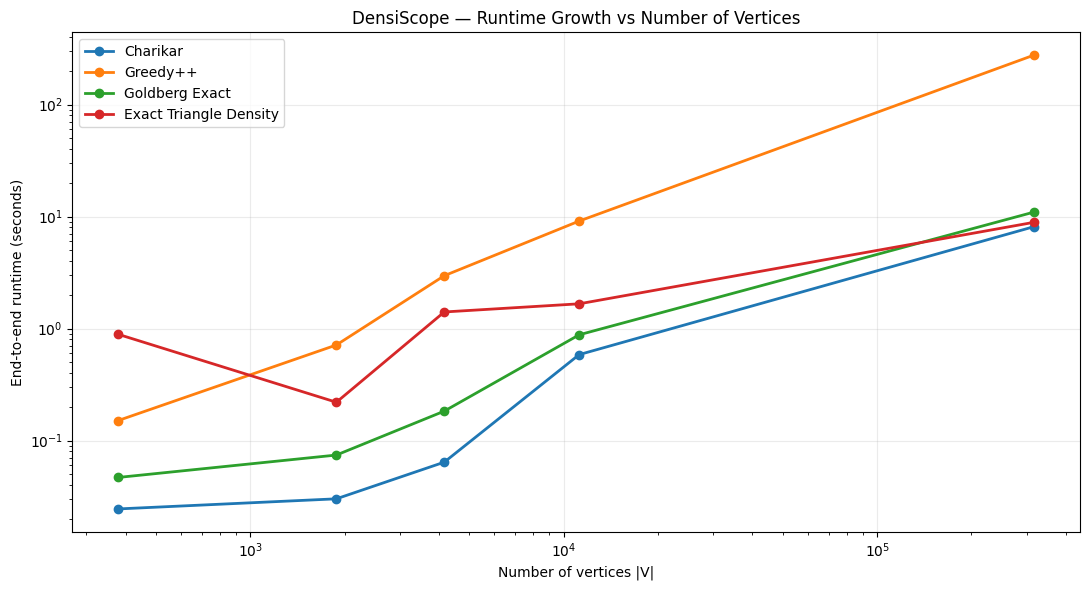

✅ Saved: /content/drive/MyDrive/DensiScope/figures/runtime_vs_nodes.png


In [107]:
plt.figure(
    figsize=(11, 6)
)

for algorithm in algorithm_order:

    data = benchmark_master_df[
        benchmark_master_df[
            "Algorithm"
        ] == algorithm
    ].sort_values(
        "Original Nodes"
    )

    plt.plot(
        data["Original Nodes"],
        data["End-to-End Runtime (s)"],
        marker="o",
        linewidth=2,
        label=algorithm
    )


plt.xscale(
    "log"
)

plt.yscale(
    "log"
)

plt.xlabel(
    "Number of vertices |V|"
)

plt.ylabel(
    "End-to-end runtime (seconds)"
)

plt.title(
    "DensiScope — Runtime Growth vs Number of Vertices"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


runtime_nodes_path = os.path.join(
    PROJECT_ROOT,
    "figures",
    "runtime_vs_nodes.png"
)


plt.savefig(
    runtime_nodes_path,
    dpi=220,
    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    runtime_nodes_path
)

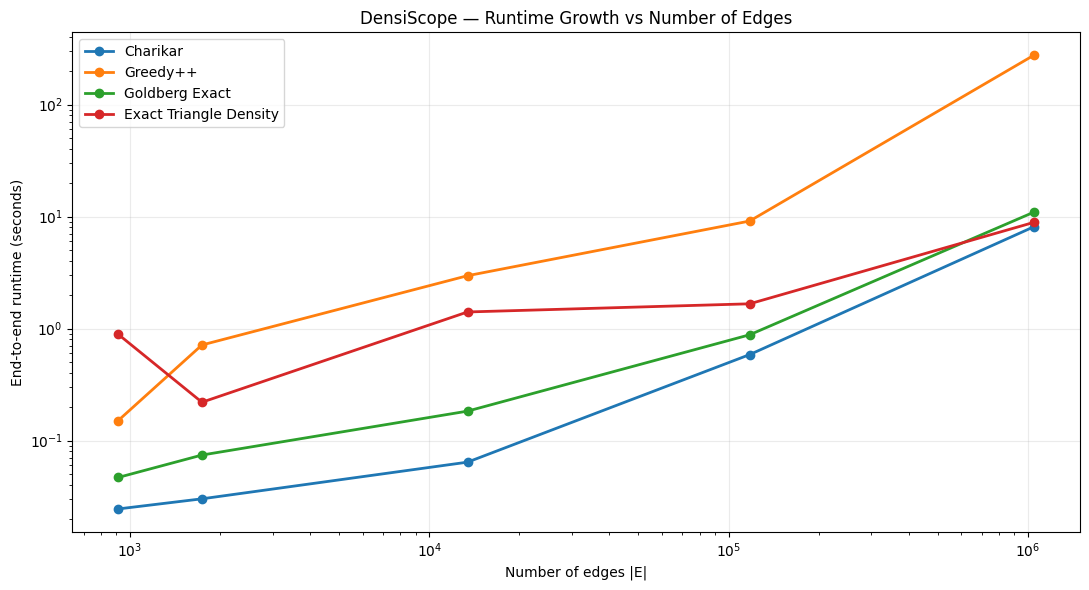

✅ Saved: /content/drive/MyDrive/DensiScope/figures/runtime_vs_edges.png


In [108]:
plt.figure(
    figsize=(11, 6)
)

for algorithm in algorithm_order:

    data = benchmark_master_df[
        benchmark_master_df[
            "Algorithm"
        ] == algorithm
    ].sort_values(
        "Original Edges"
    )

    plt.plot(
        data["Original Edges"],
        data["End-to-End Runtime (s)"],
        marker="o",
        linewidth=2,
        label=algorithm
    )


plt.xscale(
    "log"
)

plt.yscale(
    "log"
)

plt.xlabel(
    "Number of edges |E|"
)

plt.ylabel(
    "End-to-end runtime (seconds)"
)

plt.title(
    "DensiScope — Runtime Growth vs Number of Edges"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


runtime_edges_path = os.path.join(
    PROJECT_ROOT,
    "figures",
    "runtime_vs_edges.png"
)


plt.savefig(
    runtime_edges_path,
    dpi=220,
    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    runtime_edges_path
)

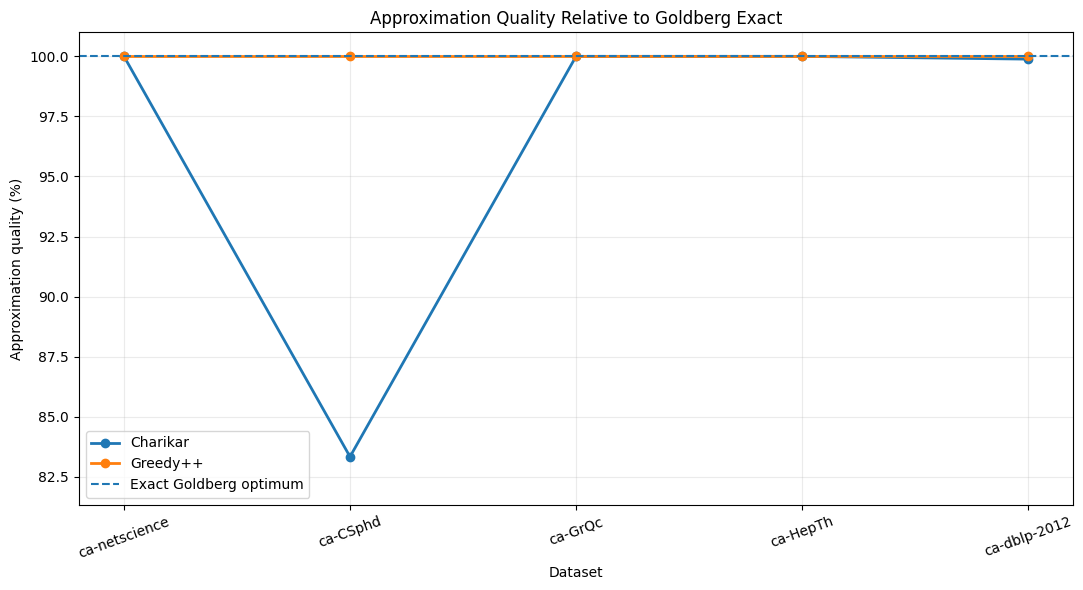

✅ Saved: /content/drive/MyDrive/DensiScope/figures/approximation_quality.png


In [109]:
plt.figure(
    figsize=(11, 6)
)

x = np.arange(
    len(benchmark_order)
)


charikar_quality_values = []

greedy_quality_values = []


for dataset_name in benchmark_order:

    charikar_quality_values.append(
        float(
            benchmark_master_df[
                (
                    benchmark_master_df[
                        "Dataset"
                    ] == dataset_name
                )
                &
                (
                    benchmark_master_df[
                        "Algorithm"
                    ] == "Charikar"
                )
            ][
                "Quality vs Goldberg (%)"
            ].iloc[0]
        )
    )

    greedy_quality_values.append(
        float(
            benchmark_master_df[
                (
                    benchmark_master_df[
                        "Dataset"
                    ] == dataset_name
                )
                &
                (
                    benchmark_master_df[
                        "Algorithm"
                    ] == "Greedy++"
                )
            ][
                "Quality vs Goldberg (%)"
            ].iloc[0]
        )
    )


plt.plot(
    x,
    charikar_quality_values,
    marker="o",
    linewidth=2,
    label="Charikar"
)

plt.plot(
    x,
    greedy_quality_values,
    marker="o",
    linewidth=2,
    label="Greedy++"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1.5,
    label="Exact Goldberg optimum"
)

plt.xticks(
    x,
    benchmark_order,
    rotation=20
)

plt.ylabel(
    "Approximation quality (%)"
)

plt.xlabel(
    "Dataset"
)

plt.title(
    "Approximation Quality Relative to Goldberg Exact"
)

plt.ylim(
    min(
        min(charikar_quality_values),
        min(greedy_quality_values)
    ) - 2,
    101
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


quality_plot_path = os.path.join(
    PROJECT_ROOT,
    "figures",
    "approximation_quality.png"
)


plt.savefig(
    quality_plot_path,
    dpi=220,
    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    quality_plot_path
)

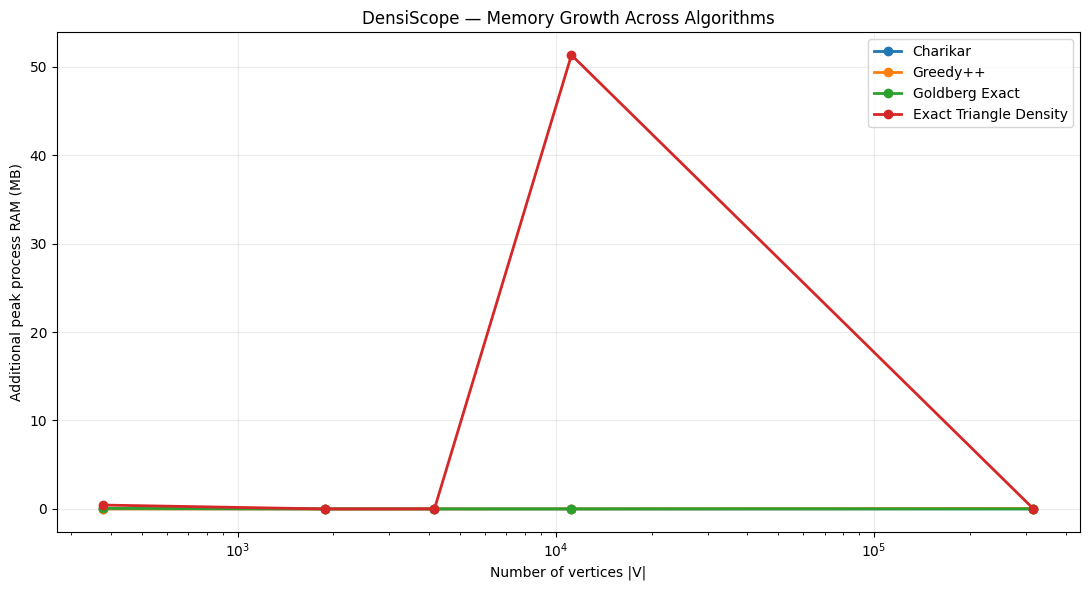

✅ Saved: /content/drive/MyDrive/DensiScope/figures/memory_vs_nodes.png


In [110]:
plt.figure(
    figsize=(11, 6)
)


for algorithm in algorithm_order:

    data = benchmark_master_df[
        benchmark_master_df[
            "Algorithm"
        ] == algorithm
    ].sort_values(
        "Original Nodes"
    )

    plt.plot(
        data["Original Nodes"],
        data["Extra Peak RAM (MB)"],
        marker="o",
        linewidth=2,
        label=algorithm
    )


plt.xscale(
    "log"
)

plt.xlabel(
    "Number of vertices |V|"
)

plt.ylabel(
    "Additional peak process RAM (MB)"
)

plt.title(
    "DensiScope — Memory Growth Across Algorithms"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


memory_plot_path = os.path.join(
    PROJECT_ROOT,
    "figures",
    "memory_vs_nodes.png"
)


plt.savefig(
    memory_plot_path,
    dpi=220,
    bbox_inches="tight"
)

plt.show()


print(
    "✅ Saved:",
    memory_plot_path
)

In [111]:
findings_rows = []


for dataset_name in benchmark_order:

    c = benchmark_master_df[
        (benchmark_master_df["Dataset"] == dataset_name)
        &
        (benchmark_master_df["Algorithm"] == "Charikar")
    ].iloc[0]

    g = benchmark_master_df[
        (benchmark_master_df["Dataset"] == dataset_name)
        &
        (benchmark_master_df["Algorithm"] == "Greedy++")
    ].iloc[0]

    gold = benchmark_master_df[
        (benchmark_master_df["Dataset"] == dataset_name)
        &
        (benchmark_master_df["Algorithm"] == "Goldberg Exact")
    ].iloc[0]

    tri = benchmark_master_df[
        (benchmark_master_df["Dataset"] == dataset_name)
        &
        (
            benchmark_master_df["Algorithm"]
            == "Exact Triangle Density"
        )
    ].iloc[0]


    findings_rows.append({

        "Dataset":
            dataset_name,

        "Exact Edge Density":
            gold["Edge Density"],

        "Charikar Quality %":
            c[
                "Quality vs Goldberg (%)"
            ],

        "Greedy++ Quality %":
            g[
                "Quality vs Goldberg (%)"
            ],

        "Charikar Runtime":
            c[
                "End-to-End Runtime (s)"
            ],

        "Greedy++ Runtime":
            g[
                "End-to-End Runtime (s)"
            ],

        "Goldberg E2E Runtime":
            gold[
                "End-to-End Runtime (s)"
            ],

        "Exact Triangle Density":
            tri[
                "Triangle Density"
            ],

        "Triangle Solver Mode":
            tri[
                "Solver Mode"
            ]
    })


key_findings_df = pd.DataFrame(
    findings_rows
)


key_findings_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "key_findings.csv"
)


key_findings_df.to_csv(
    key_findings_path,
    index=False
)


display(
    key_findings_df
)

print()
print(
    "✅ Key findings saved:"
)

print(
    key_findings_path
)

,Dataset,Exact Edge Density,Charikar Quality %,Greedy++ Quality %,Charikar Runtime,Greedy++ Runtime,Goldberg E2E Runtime,Exact Triangle Density,Triangle Solver Mode
0,ca-netscience,4.000000,100.000000,100.0,0.024532,0.151099,0.046875,9.333333,maxflow_binary_search
1,ca-CSphd,1.500000,83.333333,100.0,0.030201,0.714064,0.074286,0.666667,maxflow_binary_search
2,ca-GrQc,22.391304,100.000000,100.0,0.064184,2.967601,0.183255,325.347826,maxflow_binary_search
3,ca-HepTh,119.000000,100.000000,100.0,0.586019,9.132269,0.880713,9401.000000,complete_core_certificate
4,ca-dblp-2012,56.565217,99.884704,100.0,8.145255,277.386614,10.993045,2109.333333,upper_bound_certificate



✅ Key findings saved:
/content/drive/MyDrive/DensiScope/results/tables/key_findings.csv


# 13. Visualization & Interactive DensiScope Explorer

Large graphs are not drawn in full. Instead, comparison videos and the dashboard visualize the union of returned dense communities.

For extremely dense solutions, only a subset of edges may be **displayed** for readability. All reported metrics still use the complete unsampled solution graph.


In [112]:
def load_all_solution_sets(
    dataset_name
):
    """
    Load the final solution vertices for
    all four algorithms.
    """

    paths = {
        "Charikar":
            os.path.join(
                SOLUTIONS_DIR,
                f"{dataset_name}_charikar.npy"
            ),

        "Greedy++":
            os.path.join(
                SOLUTIONS_DIR,
                f"{dataset_name}_greedypp.npy"
            ),

        "Goldberg Exact":
            os.path.join(
                SOLUTIONS_DIR,
                f"{dataset_name}_goldberg_exact.npy"
            ),

        "Exact Triangle Density":
            os.path.join(
                SOLUTIONS_DIR,
                f"{dataset_name}_triangle_exact.npy"
            )
    }

    solutions = {}

    for algorithm, path in paths.items():

        solutions[algorithm] = np.load(
            path
        ).astype(np.int32)

    return solutions


def prepare_solution_visualization(
    dataset_name
):
    """
    Create a small visualization graph containing
    only vertices appearing in at least one algorithm's
    returned dense subgraph.

    This keeps even DBLP visualization lightweight.
    """

    A = sp.load_npz(
        processed_graph_paths[
            dataset_name
        ]
    ).tocsr()

    solutions = load_all_solution_sets(
        dataset_name
    )

    union_vertices = np.unique(
        np.concatenate(
            list(
                solutions.values()
            )
        )
    ).astype(np.int32)

    A_union = A[
        union_vertices
    ][:, union_vertices]

    G_local = nx.from_scipy_sparse_array(
        A_union,
        create_using=nx.Graph
    )

    # Restore original graph vertex IDs
    relabel = {
        i: int(union_vertices[i])
        for i in range(
            len(union_vertices)
        )
    }

    G_union = nx.relabel_nodes(
        G_local,
        relabel
    )

    # Fixed layout across all algorithms
    pos = nx.spring_layout(
        G_union,
        seed=42,
        iterations=70
    )

    del A
    del A_union
    del G_local

    gc.collect()

    return (
        G_union,
        pos,
        solutions,
        union_vertices
    )


print(
    "✅ Scalable solution visualization helper ready."
)

✅ Scalable solution visualization helper ready.


In [113]:
def save_dataset_comparison_video(
    dataset_name,
    output_path,
    fps=4,
    seconds_per_algorithm=3
):
    """
    Create a scalable presentation video comparing
    the four final dense-subgraph solutions.

    The full huge graph is NOT drawn.
    Only the union of returned solution vertices
    is visualized.
    """

    (
        G,
        pos,
        solutions,
        union_vertices
    ) = prepare_solution_visualization(
        dataset_name
    )

    algorithms = [
        "Charikar",
        "Greedy++",
        "Goldberg Exact",
        "Exact Triangle Density"
    ]

    dataset_results = (
        benchmark_master_df[
            benchmark_master_df[
                "Dataset"
            ] == dataset_name
        ]
        .set_index(
            "Algorithm"
        )
    )

    hold_frames = max(
        1,
        int(
            fps
            * seconds_per_algorithm
        )
    )

    total_frames = (
        len(algorithms)
        * hold_frames
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6)
    )

    fig.subplots_adjust(
        top=0.82,
        wspace=0.25
    )

    # ==========================================
    # UPDATE
    # ==========================================

    def update(frame_index):

        algorithm_index = min(
            frame_index
            // hold_frames,
            len(algorithms) - 1
        )

        algorithm = algorithms[
            algorithm_index
        ]

        result_vertices = set(
            solutions[
                algorithm
            ].tolist()
        )

        row = dataset_results.loc[
            algorithm
        ]

        ax_graph = axes[0]
        ax_info = axes[1]

        ax_graph.clear()
        ax_info.clear()

        # ======================================
        # LEFT — UNION GRAPH BACKGROUND
        # ======================================

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax_graph,
            edge_color="lightgray",
            width=0.5,
            alpha=0.20
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax_graph,
            node_size=25,
            node_color="lightgray",
            alpha=0.25
        )

        # ======================================
        # CURRENT SOLUTION
        # ======================================

        current_graph = G.subgraph(
            result_vertices
        )

        nx.draw_networkx_edges(
            current_graph,
            pos,
            ax=ax_graph,
            width=1.2,
            alpha=0.75
        )

        nx.draw_networkx_nodes(
            current_graph,
            pos,
            ax=ax_graph,
            node_size=65,
            alpha=0.90
        )

        ax_graph.set_title(
            f"{algorithm}\n"
            f"{len(result_vertices):,} selected vertices"
        )

        ax_graph.axis(
            "off"
        )

        # ======================================
        # RIGHT — COMPARISON INFORMATION
        # ======================================

        runtimes = [
            float(
                dataset_results.loc[
                    alg,
                    "End-to-End Runtime (s)"
                ]
            )
            for alg in algorithms
        ]

        y = np.arange(
            len(algorithms)
        )

        ax_info.barh(
            y,
            runtimes
        )

        ax_info.set_yticks(
            y
        )

        ax_info.set_yticklabels(
            algorithms
        )

        ax_info.set_xlabel(
            "End-to-end runtime (s)"
        )

        ax_info.set_title(
            "Runtime comparison"
        )

        ax_info.grid(
            axis="x",
            alpha=0.20
        )

        # ======================================
        # METRICS TEXT
        # ======================================

        if algorithm == "Exact Triangle Density":

            objective_text = (
                f"Triangle density = "
                f"{row['Triangle Density']:.6f}"
            )

        else:

            objective_text = (
                f"Edge density = "
                f"{row['Edge Density']:.6f}"
            )

        fig.suptitle(
            f"DENSISCOPE — {dataset_name}\n"
            f"{algorithm}   |   "
            f"Nodes: {int(row['Result Nodes']):,}   |   "
            f"Edges: {int(row['Result Edges']):,}   |   "
            f"{objective_text}   |   "
            f"Runtime: "
            f"{row['End-to-End Runtime (s)']:.4f}s",
            fontsize=13
        )

        return []

    # ==========================================
    # SAVE
    # ==========================================

    animation = FuncAnimation(
        fig,
        update,
        frames=total_frames,
        interval=1000 / fps,
        repeat=False
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={
            "title":
                f"DensiScope - {dataset_name}"
        },
        bitrate=2200
    )

    animation.save(
        output_path,
        writer=writer,
        dpi=120
    )

    plt.close(
        fig
    )

    del G
    del pos
    del solutions

    gc.collect()

    print(
        f"✅ {dataset_name} comparison video created."
    )

    print(
        "📹",
        output_path
    )


print(
    "✅ Dataset comparison-video generator ready."
)

✅ Dataset comparison-video generator ready.


In [114]:
comparison_video_paths = {}


for dataset_name in benchmark_order:

    print()
    print("=" * 60)
    print(
        f" VIDEO — {dataset_name}"
    )
    print("=" * 60)

    output_path = os.path.join(
        PROJECT_ROOT,
        "videos",
        f"{dataset_name}_algorithm_comparison.mp4"
    )

    save_dataset_comparison_video(
        dataset_name,
        output_path,
        fps=4,
        seconds_per_algorithm=3
    )

    comparison_video_paths[
        dataset_name
    ] = output_path


print()
print(
    "🎬 ALL DATASET COMPARISON VIDEOS COMPLETE."
)


 VIDEO — ca-netscience
✅ ca-netscience comparison video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-netscience_algorithm_comparison.mp4

 VIDEO — ca-CSphd
✅ ca-CSphd comparison video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-CSphd_algorithm_comparison.mp4

 VIDEO — ca-GrQc
✅ ca-GrQc comparison video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-GrQc_algorithm_comparison.mp4

 VIDEO — ca-HepTh
✅ ca-HepTh comparison video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-HepTh_algorithm_comparison.mp4

 VIDEO — ca-dblp-2012
✅ ca-dblp-2012 comparison video created.
📹 /content/drive/MyDrive/DensiScope/videos/ca-dblp-2012_algorithm_comparison.mp4

🎬 ALL DATASET COMPARISON VIDEOS COMPLETE.


In [115]:
Video(
    comparison_video_paths[
        "ca-dblp-2012"
    ],
    embed=True,
    width=1000
)

In [116]:
def draw_readable_dense_graph(
    G,
    pos,
    selected_vertices,
    ax,
    max_visible_edges=1200,
    show_labels=False,
    seed=42
):
    """
    Draw dense subgraphs clearly.

    IMPORTANT:
    Edge sampling is ONLY for visualization.
    All algorithm metrics still use the complete graph.
    """

    selected_vertices = set(
        selected_vertices
    )

    selected_graph = G.subgraph(
        selected_vertices
    )

    # ==========================================
    # BACKGROUND UNION GRAPH
    # ==========================================

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=18,
        node_color="lightgray",
        alpha=0.20
    )

    # ==========================================
    # SELECTED SOLUTION NODES
    # ==========================================

    nx.draw_networkx_nodes(
        selected_graph,
        pos,
        ax=ax,
        node_size=70,
        alpha=0.90,
        linewidths=0.6,
        edgecolors="black"
    )

    # ==========================================
    # EDGES — SAMPLE ONLY IF TOO DENSE
    # ==========================================

    solution_edges = list(
        selected_graph.edges()
    )

    total_solution_edges = len(
        solution_edges
    )

    if (
        total_solution_edges
        > max_visible_edges
    ):

        rng = np.random.default_rng(
            seed
        )

        chosen = rng.choice(
            total_solution_edges,
            size=max_visible_edges,
            replace=False
        )

        visible_edges = [
            solution_edges[i]
            for i in chosen
        ]

        edge_note = (
            f"Showing {max_visible_edges:,} "
            f"of {total_solution_edges:,} edges "
            f"for readability"
        )

    else:

        visible_edges = (
            solution_edges
        )

        edge_note = (
            f"Showing all "
            f"{total_solution_edges:,} edges"
        )

    nx.draw_networkx_edges(
        selected_graph,
        pos,
        edgelist=visible_edges,
        ax=ax,
        width=0.55,
        alpha=0.28
    )

    # ==========================================
    # OPTIONAL LABELS
    # ==========================================

    if show_labels:

        nx.draw_networkx_labels(
            selected_graph,
            pos,
            ax=ax,
            font_size=6
        )

    ax.axis(
        "off"
    )

    return edge_note


print(
    "✅ Readable dense-graph renderer ready."
)

✅ Readable dense-graph renderer ready.


In [117]:
final_dataset_dropdown = widgets.Dropdown(
    options=benchmark_order,
    value="ca-dblp-2012",
    description="Dataset:"
)

final_algorithm_dropdown = widgets.Dropdown(
    options=algorithm_order,
    value="Goldberg Exact",
    description="Algorithm:"
)

final_labels_checkbox = widgets.Checkbox(
    value=False,
    description="Show vertex IDs"
)

final_dashboard_output = widgets.Output()


def update_final_densiscope_dashboard(
    change=None
):

    dataset_name = (
        final_dataset_dropdown.value
    )

    algorithm = (
        final_algorithm_dropdown.value
    )

    with final_dashboard_output:

        clear_output(
            wait=True
        )

        # ======================================
        # RESULT
        # ======================================

        row = benchmark_master_df[
            (
                benchmark_master_df[
                    "Dataset"
                ] == dataset_name
            )
            &
            (
                benchmark_master_df[
                    "Algorithm"
                ] == algorithm
            )
        ].iloc[0]

        # ======================================
        # VISUALIZATION GRAPH
        # ======================================

        (
            G,
            pos,
            solutions,
            union_vertices
        ) = prepare_solution_visualization(
            dataset_name
        )

        selected = (
            solutions[
                algorithm
            ]
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(15, 7)
        )

        # ======================================
        # LEFT — GRAPH
        # ======================================

        edge_note = (
            draw_readable_dense_graph(
                G,
                pos,
                selected,
                axes[0],
                max_visible_edges=1200,
                show_labels=
                    final_labels_checkbox.value
            )
        )

        axes[0].set_title(
            f"{dataset_name}\n"
            f"{algorithm}",
            fontsize=14
        )

        # ======================================
        # RIGHT — RESULT CARD
        # ======================================

        ax = axes[1]

        ax.axis(
            "off"
        )

        if (
            algorithm
            == "Exact Triangle Density"
        ):

            objective_name = (
                "Triangle Density"
            )

            objective_value = (
                row[
                    "Triangle Density"
                ]
            )

        else:

            objective_name = (
                "Edge Density |E| / |V|"
            )

            objective_value = (
                row[
                    "Edge Density"
                ]
            )

        text_lines = [
            "DENSISCOPE RESULT",
            "",
            f"Dataset:",
            f"{dataset_name}",
            "",
            f"Algorithm:",
            f"{algorithm}",
            "",
            "Original graph",
            (
                f"{int(row['Original Nodes']):,} vertices"
            ),
            (
                f"{int(row['Original Edges']):,} edges"
            ),
            "",
            "Returned subgraph",
            (
                f"{int(row['Result Nodes']):,} vertices"
            ),
            (
                f"{int(row['Result Edges']):,} edges"
            ),
            "",
            objective_name,
            f"{objective_value:.6f}",
            "",
            "End-to-end runtime",
            (
                f"{row['End-to-End Runtime (s)']:.6f} s"
            )
        ]

        if pd.notna(
            row[
                "Quality vs Goldberg (%)"
            ]
        ):

            text_lines.extend([
                "",
                "Quality vs exact Goldberg",
                (
                    f"{row['Quality vs Goldberg (%)']:.3f}%"
                )
            ])

        text_lines.extend([
            "",
            "Solver mode",
            str(
                row[
                    "Solver Mode"
                ]
            )
        ])

        ax.text(
            0.05,
            0.95,
            "\n".join(
                text_lines
            ),
            transform=ax.transAxes,
            va="top",
            fontsize=12
        )

        # ======================================
        # MAIN TITLE
        # ======================================

        fig.suptitle(
            "DENSISCOPE — INTERACTIVE "
            "DENSE-SUBGRAPH EXPLORER",
            fontsize=16
        )

        plt.tight_layout(
            rect=[
                0,
                0.05,
                1,
                0.94
            ]
        )

        plt.show()

        print(
            "Visualization note:",
            edge_note
        )

        print(
            "All reported metrics use the full "
            "un-sampled solution graph."
        )

        del G
        del solutions

        gc.collect()


final_dataset_dropdown.observe(
    update_final_densiscope_dashboard,
    names="value"
)

final_algorithm_dropdown.observe(
    update_final_densiscope_dashboard,
    names="value"
)

final_labels_checkbox.observe(
    update_final_densiscope_dashboard,
    names="value"
)


print(
    "✅ Final DensiScope dashboard defined."
)

✅ Final DensiScope dashboard defined.


In [118]:
final_controls = widgets.HBox([
    final_dataset_dropdown,
    final_algorithm_dropdown,
    final_labels_checkbox
])

display(
    final_controls,
    final_dashboard_output
)

update_final_densiscope_dashboard()

Output()

In [119]:
submission_inventory = []


# ==============================================
# RESULTS TABLES
# ==============================================

tables_dir = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables"
)

for filename in sorted(
    os.listdir(
        tables_dir
    )
):

    if filename.endswith(
        ".csv"
    ):

        path = os.path.join(
            tables_dir,
            filename
        )

        submission_inventory.append({
            "Category":
                "Results Table",

            "File":
                filename,

            "Size (MB)":
                os.path.getsize(path)
                / (1024 ** 2)
        })


# ==============================================
# FIGURES
# ==============================================

figures_dir = os.path.join(
    PROJECT_ROOT,
    "figures"
)

for filename in sorted(
    os.listdir(
        figures_dir
    )
):

    if filename.lower().endswith(
        (
            ".png",
            ".jpg",
            ".jpeg"
        )
    ):

        path = os.path.join(
            figures_dir,
            filename
        )

        submission_inventory.append({
            "Category":
                "Figure",

            "File":
                filename,

            "Size (MB)":
                os.path.getsize(path)
                / (1024 ** 2)
        })


# ==============================================
# VIDEOS
# ==============================================

videos_dir = os.path.join(
    PROJECT_ROOT,
    "videos"
)

for filename in sorted(
    os.listdir(
        videos_dir
    )
):

    if filename.endswith(
        ".mp4"
    ):

        path = os.path.join(
            videos_dir,
            filename
        )

        submission_inventory.append({
            "Category":
                "Video",

            "File":
                filename,

            "Size (MB)":
                os.path.getsize(path)
                / (1024 ** 2)
        })


# ==============================================
# SOLUTION VERTEX SETS
# ==============================================

for filename in sorted(
    os.listdir(
        SOLUTIONS_DIR
    )
):

    if filename.endswith(
        ".npy"
    ):

        path = os.path.join(
            SOLUTIONS_DIR,
            filename
        )

        submission_inventory.append({
            "Category":
                "Solution",

            "File":
                filename,

            "Size (MB)":
                os.path.getsize(path)
                / (1024 ** 2)
        })


inventory_df = pd.DataFrame(
    submission_inventory
)


inventory_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "submission_inventory.csv"
)


inventory_df.to_csv(
    inventory_path,
    index=False
)


display(
    inventory_df
)

print()
print(
    "Total generated artifacts:",
    len(inventory_df)
)

print()
print(
    "✅ Final project inventory saved."
)

,Category,File,Size (MB)
0,Results Table,approximation_quality.csv,0.000694
1,Results Table,benchmark_results.csv,0.000525
2,Results Table,dataset_manifest.csv,0.001070
3,Results Table,fast_algorithm_benchmarks.csv,0.001460
4,Results Table,final_all_algorithms.csv,0.001573
5,Results Table,final_benchmark_master.csv,0.003266
6,Results Table,goldberg_exact_benchmarks.csv,0.001312
7,Results Table,goldberg_reduction_preview.csv,0.000794
8,Results Table,key_findings.csv,0.000791
9,Results Table,presentation_summary.csv,0.000477



Total generated artifacts: 48

✅ Final project inventory saved.


# 14. Final Validation, Documentation & Reproducibility

The final cells verify that all required datasets, algorithms, result files, figures, videos, and solution vertex sets exist.

The notebook also creates:
- a presentation summary,
- `README.md`,
- `requirements.txt`,
- a project summary,
- a final artifact inventory.


In [120]:
print("=" * 72)
print("           DENSISCOPE — FINAL PROJECT VALIDATION")
print("=" * 72)

validation_checks = []

# ============================================================
# 1. DATASETS
# ============================================================

expected_datasets = [
    "ca-netscience",
    "ca-CSphd",
    "ca-GrQc",
    "ca-HepTh",
    "ca-dblp-2012"
]

actual_datasets = set(
    benchmark_master_df["Dataset"].unique()
)

datasets_ok = all(
    dataset in actual_datasets
    for dataset in expected_datasets
)

validation_checks.append(
    ("5 collaboration datasets", datasets_ok)
)


# ============================================================
# 2. ALGORITHMS
# ============================================================

expected_algorithms = [
    "Charikar",
    "Greedy++",
    "Goldberg Exact",
    "Exact Triangle Density"
]

actual_algorithms = set(
    benchmark_master_df["Algorithm"].unique()
)

algorithms_ok = all(
    algorithm in actual_algorithms
    for algorithm in expected_algorithms
)

validation_checks.append(
    ("4 required algorithms", algorithms_ok)
)


# ============================================================
# 3. EXPECT 20 FINAL RESULT ROWS
# ============================================================

expected_rows = (
    len(expected_datasets)
    * len(expected_algorithms)
)

rows_ok = (
    len(benchmark_master_df)
    == expected_rows
)

validation_checks.append(
    (
        f"{expected_rows} dataset/algorithm results",
        rows_ok
    )
)


# ============================================================
# 4. ALL EDGE-ALGORITHM RESULTS VALID
# ============================================================

edge_algorithms = [
    "Charikar",
    "Greedy++",
    "Goldberg Exact"
]

edge_results = benchmark_master_df[
    benchmark_master_df[
        "Algorithm"
    ].isin(edge_algorithms)
]

edge_values_ok = (
    edge_results["Edge Density"]
    .notna()
    .all()
)

validation_checks.append(
    ("All edge-density results present", edge_values_ok)
)


# ============================================================
# 5. ALL TRIANGLE RESULTS VALID
# ============================================================

triangle_results = benchmark_master_df[
    benchmark_master_df["Algorithm"]
    == "Exact Triangle Density"
]

triangle_values_ok = (
    triangle_results[
        "Triangle Density"
    ]
    .notna()
    .all()
)

validation_checks.append(
    (
        "All exact triangle-density results present",
        triangle_values_ok
    )
)


# ============================================================
# 6. CHARIKAR / GREEDY++ CANNOT BEAT EXACT GOLDBERG
# ============================================================

quality_ok = True

for dataset_name in expected_datasets:

    gold_density = float(
        benchmark_master_df[
            (
                benchmark_master_df["Dataset"]
                == dataset_name
            )
            &
            (
                benchmark_master_df["Algorithm"]
                == "Goldberg Exact"
            )
        ]["Edge Density"].iloc[0]
    )

    for algorithm in [
        "Charikar",
        "Greedy++"
    ]:

        approx_density = float(
            benchmark_master_df[
                (
                    benchmark_master_df["Dataset"]
                    == dataset_name
                )
                &
                (
                    benchmark_master_df["Algorithm"]
                    == algorithm
                )
            ]["Edge Density"].iloc[0]
        )

        if approx_density > gold_density + 1e-9:
            quality_ok = False


validation_checks.append(
    (
        "Approximate densities ≤ Goldberg optimum",
        quality_ok
    )
)


# ============================================================
# 7. REQUIRED FIGURES
# ============================================================

required_figures = [
    "runtime_vs_nodes.png",
    "runtime_vs_edges.png",
    "approximation_quality.png",
    "memory_vs_nodes.png",
    "goldberg_safe_reduction.png"
]

figures_ok = all(
    os.path.exists(
        os.path.join(
            PROJECT_ROOT,
            "figures",
            filename
        )
    )
    for filename in required_figures
)

validation_checks.append(
    ("Required/bonus figures generated", figures_ok)
)


# ============================================================
# 8. COMPARISON VIDEOS
# ============================================================

videos_ok = all(
    os.path.exists(
        os.path.join(
            PROJECT_ROOT,
            "videos",
            f"{dataset}_algorithm_comparison.mp4"
        )
    )
    for dataset in expected_datasets
)

validation_checks.append(
    ("5 dataset comparison videos", videos_ok)
)


# ============================================================
# 9. SOLUTION FILES
# ============================================================

solution_suffixes = [
    "charikar",
    "greedypp",
    "goldberg_exact",
    "triangle_exact"
]

solutions_ok = True

for dataset in expected_datasets:

    for suffix in solution_suffixes:

        solution_file = os.path.join(
            SOLUTIONS_DIR,
            f"{dataset}_{suffix}.npy"
        )

        if not os.path.exists(solution_file):
            solutions_ok = False


validation_checks.append(
    (
        "All final solution vertex sets saved",
        solutions_ok
    )
)


# ============================================================
# DISPLAY
# ============================================================

all_passed = True

for name, passed in validation_checks:

    symbol = "✅" if passed else "❌"

    print(
        f"{symbol} {name}"
    )

    if not passed:
        all_passed = False


print("=" * 72)

if all_passed:

    print(
        "🎯 DENSISCOPE COMPUTATIONAL PROJECT IS COMPLETE."
    )

else:

    print(
        "⚠️ Some checks failed. "
        "Do not finalize the submission yet."
    )

print("=" * 72)

           DENSISCOPE — FINAL PROJECT VALIDATION
✅ 5 collaboration datasets
✅ 4 required algorithms
✅ 20 dataset/algorithm results
✅ All edge-density results present
✅ All exact triangle-density results present
✅ Approximate densities ≤ Goldberg optimum
✅ Required/bonus figures generated
✅ 5 dataset comparison videos
✅ All final solution vertex sets saved
🎯 DENSISCOPE COMPUTATIONAL PROJECT IS COMPLETE.


In [121]:
presentation_summary_rows = []

for dataset_name in benchmark_order:

    c = benchmark_master_df[
        (
            benchmark_master_df["Dataset"]
            == dataset_name
        )
        &
        (
            benchmark_master_df["Algorithm"]
            == "Charikar"
        )
    ].iloc[0]

    g = benchmark_master_df[
        (
            benchmark_master_df["Dataset"]
            == dataset_name
        )
        &
        (
            benchmark_master_df["Algorithm"]
            == "Greedy++"
        )
    ].iloc[0]

    gold = benchmark_master_df[
        (
            benchmark_master_df["Dataset"]
            == dataset_name
        )
        &
        (
            benchmark_master_df["Algorithm"]
            == "Goldberg Exact"
        )
    ].iloc[0]

    tri = benchmark_master_df[
        (
            benchmark_master_df["Dataset"]
            == dataset_name
        )
        &
        (
            benchmark_master_df["Algorithm"]
            == "Exact Triangle Density"
        )
    ].iloc[0]

    presentation_summary_rows.append({

        "Dataset":
            dataset_name,

        "|V|":
            int(c["Original Nodes"]),

        "|E|":
            int(c["Original Edges"]),

        "Charikar ρ":
            float(c["Edge Density"]),

        "Greedy++ ρ":
            float(g["Edge Density"]),

        "Exact ρ*":
            float(gold["Edge Density"]),

        "Charikar %":
            float(
                c[
                    "Quality vs Goldberg (%)"
                ]
            ),

        "Greedy++ %":
            float(
                g[
                    "Quality vs Goldberg (%)"
                ]
            ),

        "Triangle τ*":
            float(
                tri[
                    "Triangle Density"
                ]
            )
    })


presentation_summary_df = pd.DataFrame(
    presentation_summary_rows
)

presentation_summary_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "tables",
    "presentation_summary.csv"
)

presentation_summary_df.to_csv(
    presentation_summary_path,
    index=False
)

display(
    presentation_summary_df
)

print()
print(
    "✅ Presentation summary saved."
)

,Dataset,|V|,|E|,Charikar ρ,Greedy++ ρ,Exact ρ*,Charikar %,Greedy++ %,Triangle τ*
0,ca-netscience,379,914,4.000000,4.000000,4.000000,100.000000,100.0,9.333333
1,ca-CSphd,1882,1740,1.250000,1.500000,1.500000,83.333333,100.0,0.666667
2,ca-GrQc,4158,13422,22.391304,22.391304,22.391304,100.000000,100.0,325.347826
3,ca-HepTh,11204,117619,119.000000,119.000000,119.000000,100.000000,100.0,9401.000000
4,ca-dblp-2012,317080,1049866,56.500000,56.565217,56.565217,99.884704,100.0,2109.333333



✅ Presentation summary saved.


In [122]:
%%writefile /content/drive/MyDrive/DensiScope/README.md
# DensiScope

## Densest Subgraph Discovery on Large Collaboration Networks

**DensiScope** is an Analysis and Algorithms project for discovering and analyzing dense communities in large real-world collaboration networks.

The project implements and compares four densest-subgraph algorithms:

1. **Charikar's Greedy Peeling Algorithm**
2. **Greedy++**
3. **Goldberg's Exact Max-Flow Algorithm**
4. **Exact Triangle-Density Densest Subgraph**

The system evaluates solution quality, runtime scalability, memory behavior, exact-safe preprocessing, and real-time algorithm visualization.

---

## 1. Problem Definition

For the ordinary Densest Subgraph Problem, DensiScope maximizes:

\[
\rho(S)=\frac{|E(S)|}{|V(S)|}
\]

where:

- \(V(S)\) is the set of vertices in the selected subgraph
- \(E(S)\) is the set of edges inside the selected subgraph

For triangle-density optimization, the objective is:

\[
\tau(S)=\frac{T(S)}{|V(S)|}
\]

where \(T(S)\) is the number of triangles completely contained inside the selected subgraph.

This allows the project to compare ordinary edge concentration with higher-order structural cohesion.

---

## 2. Algorithms

### Charikar

Charikar repeatedly removes the minimum-degree vertex while tracking the densest intermediate subgraph.

It provides a fast approximation and acts as the project's scalable baseline.

---

### Greedy++

Greedy++ extends greedy peeling across multiple rounds.

The priority of a vertex depends on:

\[
\text{load}(v)+\text{current degree}(v)
\]

The load stores information from previous peeling rounds.

The experiments use **10 Greedy++ rounds**.

---

### Goldberg Exact

Goldberg solves the ordinary edge-density problem exactly using:

- Binary search over density
- Max-flow / min-cut decision problems

DensiScope improves its scalability using an **exact-safe core reduction** before constructing the flow network.

---

### Exact Triangle Density

This algorithm maximizes:

\[
\frac{\text{number of triangles}}{\text{number of vertices}}
\]

DensiScope combines:

- Triangle-core preprocessing
- Triangle greedy lower bounds
- Triangle-component decomposition
- Structural optimality certificates
- Max-flow / min-cut when required

This allows large triangle-density instances to be solved without unnecessarily creating enormous flow networks.

---

## 3. Datasets

Five real collaboration networks are evaluated.

| Dataset | Vertices | Edges |
|---|---:|---:|
| ca-netscience | 379 | 914 |
| ca-CSphd | 1,882 | 1,740 |
| ca-GrQc | 4,158 | 13,422 |
| ca-HepTh | 11,204 | 117,619 |
| ca-dblp-2012 | 317,080 | 1,049,866 |

Graphs are stored using memory-efficient **SciPy CSR sparse matrices**.

---

## 4. Main Results

### ca-netscience

All edge-density algorithms found:

- 9 vertices
- 36 edges
- Edge density = **4.0**

The returned structure is a complete \(K_9\).

Exact Triangle Density found:

- 9 vertices
- 84 triangles
- Triangle density = **9.333333**

---

### ca-CSphd

Charikar:

- Edge density = **1.25**

Greedy++:

- Edge density = **1.50**

Goldberg Exact:

- Exact edge density = **1.50**

This demonstrates a case where Greedy++ improves on Charikar and reaches the exact optimum.

---

### ca-GrQc

Charikar, Greedy++, and Goldberg all found:

- 46 vertices
- 1,030 edges
- Edge density = **22.391304**

Exact Triangle Density found triangle density:

- **325.347826**

---

### ca-HepTh

All edge-density algorithms found:

- 239 vertices
- 28,441 edges
- Edge density = **119**

The returned graph is a complete \(K_{239}\).

Exact Triangle Density found:

- 2,246,839 triangles
- Triangle density = **9,401**

The complete-core structure provides an exact certificate without requiring the large triangle max-flow construction.

---

### ca-dblp-2012

Original graph:

- 317,080 vertices
- 1,049,866 edges

Charikar:

- 114 vertices
- 6,441 edges
- Edge density = **56.500000**

Greedy++:

- 115 vertices
- 6,505 edges
- Edge density = **56.565217**

Goldberg Exact:

- 115 vertices
- 6,505 edges
- Exact edge density = **56.565217**

Exact Triangle Density:

- 114 vertices
- 6,441 edges
- Triangle density = **2109.333333**

This shows that edge-density and triangle-density optimization can prefer different communities.

---

## 5. Exact-Safe Preprocessing

A major scalability improvement in DensiScope is the use of mathematically safe preprocessing.

For Goldberg Exact, DBLP is reduced from:

- **317,080 → 280 vertices**
- **1,049,866 → 13,609 edges**

This removes approximately **99.91% of the vertices** before max-flow while preserving the global optimum.

The same strategy substantially reduces the other datasets as well.

---

## 6. Triangle Exact Certificates

DensiScope avoids constructing unnecessary large triangle-flow networks whenever the optimum can already be certified.

### ca-HepTh

The safe triangle core is a complete \(K_{239}\).

Therefore the optimum is directly certified.

### ca-dblp-2012

A feasible triangle-density lower bound and a mathematically valid component upper bound both equal:

\[
2109.333333
\]

Therefore the DBLP triangle optimum is exactly certified without building the full auxiliary max-flow network.

---

## 7. Approximation Quality

Goldberg Exact is used as the reference optimum for ordinary edge-density DSP.

The experiments show:

- Charikar is extremely fast and often reaches the exact optimum.
- Greedy++ can improve Charikar when Charikar misses the optimum.
- Greedy++ requires substantially more runtime because it performs repeated peeling rounds.

Examples:

- `ca-CSphd`: Charikar = 1.25, Greedy++ = Exact = 1.50
- `ca-dblp-2012`: Charikar = 56.50, Greedy++ = Exact = 56.565217

---

## 8. Scalability Analysis

DensiScope produces experimental growth plots for:

- Runtime vs number of vertices
- Runtime vs number of edges
- Approximation quality vs Goldberg Exact
- Additional peak RAM usage
- Exact-safe preprocessing reduction

Logarithmic axes are used for runtime growth because the datasets range from hundreds to hundreds of thousands of vertices.

Exact-method end-to-end runtime includes the prerequisite Charikar lower-bound computation.

---

## 9. Visualization

DensiScope includes several visualization modes:

- Live Charikar peeling
- Live Greedy++ peeling
- Goldberg binary-search convergence
- Exact Triangle binary-search convergence
- MP4 algorithm animations
- Dataset comparison videos
- Interactive dataset/algorithm dashboard

For extremely dense returned subgraphs, only a subset of edges may be **displayed** for readability.

All reported metrics always use the complete, unsampled solution graph.

---

## 10. Interactive DensiScope Explorer

The Colab notebook contains an interactive dashboard that allows the user to select:

- Dataset
- Algorithm
- Whether vertex IDs are displayed

The dashboard dynamically displays:

- Original graph size
- Returned dense-subgraph size
- Edge density
- Triangle density when applicable
- Approximation quality
- End-to-end runtime
- Solver mode

---

## 11. Memory Efficiency

The project is designed for Google Colab.

Key memory-management strategies include:

- SciPy CSR sparse matrices
- One dataset loaded at a time
- Explicit garbage collection
- Compact NumPy integer arrays
- Indexed heaps without stale entries
- Triangle counting without storing triangles initially
- Exact-safe graph reductions
- Structural certificates before expensive max-flow
- Visualization only on returned dense communities for huge graphs

---

## 12. Project Structure

```text
DensiScope/
├── data/
│   ├── raw/
│   └── processed/
│
├── figures/
│
├── videos/
│
├── results/
│   ├── tables/
│   └── solutions/
│
├── DensiScope_FINAL.ipynb
├── README.md
└── requirements.txt


Overwriting /content/drive/MyDrive/DensiScope/README.md


In [123]:
requirements_text = """numpy
pandas
scipy
networkx
matplotlib
psutil
requests
python-igraph
numba
ipywidgets
imageio
imageio-ffmpeg
"""

requirements_path = os.path.join(
    PROJECT_ROOT,
    "requirements.txt"
)

with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements_text)

print("✅ requirements.txt created.")
print(requirements_path)


✅ requirements.txt created.
/content/drive/MyDrive/DensiScope/requirements.txt


In [124]:
important_files = {
    "README.md":
        os.path.join(
            PROJECT_ROOT,
            "README.md"
        ),

    "requirements.txt":
        os.path.join(
            PROJECT_ROOT,
            "requirements.txt"
        ),

    "Final benchmark":
        os.path.join(
            PROJECT_ROOT,
            "results",
            "tables",
            "final_benchmark_master.csv"
        ),

    "Presentation summary":
        os.path.join(
            PROJECT_ROOT,
            "results",
            "tables",
            "presentation_summary.csv"
        ),

    "Dataset manifest":
        os.path.join(
            PROJECT_ROOT,
            "results",
            "tables",
            "dataset_manifest.csv"
        )
}


print("=" * 65)
print(" DENSISCOPE — IMPORTANT FILE CHECK")
print("=" * 65)

everything_ok = True

for name, path in important_files.items():

    exists = os.path.exists(path)

    size = (
        os.path.getsize(path)
        if exists
        else 0
    )

    valid = (
        exists
        and size > 0
    )

    symbol = (
        "✅"
        if valid
        else "❌"
    )

    print(
        f"{symbol} "
        f"{name:<24} "
        f"{size / 1024:.2f} KB"
    )

    if not valid:
        everything_ok = False


print("=" * 65)

if everything_ok:

    print(
        "🎯 Core project files are ready."
    )

else:

    print(
        "⚠️ One or more project files are missing."
    )

 DENSISCOPE — IMPORTANT FILE CHECK
✅ README.md                7.62 KB
✅ requirements.txt         0.11 KB
✅ Final benchmark          3.34 KB
✅ Presentation summary     0.49 KB
✅ Dataset manifest         1.10 KB
🎯 Core project files are ready.


In [125]:
summary_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "PROJECT_SUMMARY.txt"
)


project_summary = f"""
DENSISCOPE — FINAL PROJECT SUMMARY
==================================

PROJECT
-------
Densest Subgraph Discovery on Large Collaboration Networks

DATASETS
--------
1. ca-netscience
   379 vertices
   914 edges

2. ca-CSphd
   1,882 vertices
   1,740 edges

3. ca-GrQc
   4,158 vertices
   13,422 edges

4. ca-HepTh
   11,204 vertices
   117,619 edges

5. ca-dblp-2012
   317,080 vertices
   1,049,866 edges


ALGORITHMS
----------
1. Charikar
2. Greedy++
3. Goldberg Exact
4. Exact Triangle Density


IMPORTANT RESULTS
-----------------

ca-netscience
Edge optimum = 4.000000
Triangle optimum = 9.333333

ca-CSphd
Charikar = 1.250000
Greedy++ = 1.500000
Goldberg Exact = 1.500000

ca-GrQc
Exact edge density = 22.391304
Exact triangle density = 325.347826

ca-HepTh
Edge optimum = 119.000000
Triangle optimum = 9401.000000
Dense structure = complete K239

ca-dblp-2012
Charikar edge density = 56.500000
Greedy++ edge density = 56.565217
Goldberg exact density = 56.565217
Exact triangle density = 2109.333333


KEY FINDINGS
------------
- Charikar is extremely fast and often reaches the exact optimum.
- Greedy++ improves Charikar on ca-CSphd and ca-dblp-2012.
- Greedy++ is considerably slower because it performs repeated peeling rounds.
- Goldberg provides the exact edge-density reference solution.
- Exact-safe preprocessing makes Goldberg practical even on DBLP.
- DBLP was safely reduced from 317,080 vertices to 280 before Goldberg.
- Edge-density and triangle-density optimization can select different communities.
- ca-HepTh triangle density was certified through a complete K239 core.
- DBLP triangle optimality was certified without constructing the full triangle max-flow network.


BONUS FEATURES
--------------
- Runtime-growth analysis
- Memory analysis
- Approximation-quality analysis
- Exact-safe preprocessing
- Structural optimality certificates
- Live execution visualization
- MP4 visualizations
- Interactive DensiScope dashboard
"""


with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        project_summary.strip()
    )


print(
    "✅ Final project summary created."
)

print(
    summary_path
)

✅ Final project summary created.
/content/drive/MyDrive/DensiScope/results/PROJECT_SUMMARY.txt


In [126]:
print("=" * 70)
print(" DENSISCOPE — FINAL PROJECT STRUCTURE")
print("=" * 70)

folders_to_check = [
    "data/processed",
    "figures",
    "videos",
    "results/tables",
    "results/solutions"
]


for relative_folder in folders_to_check:

    folder = os.path.join(
        PROJECT_ROOT,
        relative_folder
    )

    if os.path.exists(folder):

        files = [
            f for f in os.listdir(folder)
            if not f.startswith(".")
        ]

        print()
        print(
            f"📁 {relative_folder}/ "
            f"({len(files)} files)"
        )

        for filename in sorted(files)[:15]:
            print(
                "   └──",
                filename
            )

        if len(files) > 15:

            print(
                f"   └── ... "
                f"{len(files) - 15} more files"
            )

    else:

        print(
            f"❌ Missing: "
            f"{relative_folder}"
        )


print()
print("📄 README.md")
print("📄 requirements.txt")

print()
print("=" * 70)
print(
    "✅ DensiScope project folder packaged."
)
print("=" * 70)

 DENSISCOPE — FINAL PROJECT STRUCTURE

📁 data/processed/ (5 files)
   └── ca-CSphd_csr.npz
   └── ca-GrQc_csr.npz
   └── ca-HepTh_csr.npz
   └── ca-dblp-2012_csr.npz
   └── ca-netscience_csr.npz

📁 figures/ (5 files)
   └── approximation_quality.png
   └── goldberg_safe_reduction.png
   └── memory_vs_nodes.png
   └── runtime_vs_edges.png
   └── runtime_vs_nodes.png

📁 videos/ (10 files)
   └── ca-CSphd_algorithm_comparison.mp4
   └── ca-GrQc_algorithm_comparison.mp4
   └── ca-HepTh_algorithm_comparison.mp4
   └── ca-dblp-2012_algorithm_comparison.mp4
   └── ca-netscience_algorithm_comparison.mp4
   └── ca-netscience_charikar.mp4
   └── ca-netscience_goldberg_exact.mp4
   └── ca-netscience_greedypp.mp4
   └── ca-netscience_triangle_exact.mp4
   └── charikar_test_graph.mp4

📁 results/tables/ (13 files)
   └── approximation_quality.csv
   └── benchmark_results.csv
   └── dataset_manifest.csv
   └── fast_algorithm_benchmarks.csv
   └── final_all_algorithms.csv
   └── final_benchmark_master

# 15. Conclusions

The experiments show that no single method dominates every criterion:

- **Charikar** is the fastest scalable baseline and often reaches the exact optimum.
- **Greedy++** can repair Charikar misses, notably on `ca-CSphd` and `ca-dblp-2012`, but repeated rounds are substantially more expensive.
- **Goldberg Exact** provides the ground-truth edge-density optimum, while exact-safe preprocessing makes it practical even on the 317,080-vertex DBLP graph.
- **Exact Triangle Density** captures a different notion of cohesion. On DBLP, the edge-optimal and triangle-optimal communities are not identical.
- Structural certificates can eliminate expensive max-flow work entirely for some large triangle-density instances.

The central engineering result of DensiScope is that **exactness and scalability are not mutually exclusive when strong lower bounds, safe reductions, sparse representations, and structural certificates are combined**.
